<a href="https://colab.research.google.com/github/gayatrirajesh23/matrix_ill_conditioning/blob/main/ILL_CONDITIONING%20(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from scipy.stats import wilcoxon
from scipy.stats import binomtest

from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    precision_score, recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, r2_score, roc_curve
)
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.model_selection import (
    GridSearchCV, StratifiedGroupKFold, train_test_split, GroupKFold,
    GroupShuffleSplit, cross_val_score, cross_val_predict
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PolynomialFeatures

try:
    import xgboost as xgb
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'], check=True)
    import xgboost as xgb

try:
    import lightgbm as lgb
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'lightgbm', '-q'], check=True)
    import lightgbm as lgb

try:
    import optuna
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'], check=True)
    import optuna

try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'shap', '-q'], check=True)
    import shap
from scipy.sparse import issparse, csr_matrix
from scipy.sparse.linalg import eigsh, svds
from scipy.io import mmread

try:
    import ssgetpy
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'ssgetpy', '-q'], check=True)
    import ssgetpy
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [ ]:
# ================================================================
# HELPERS
# ================================================================
def best_threshold_youden(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    idx = np.argmax(tpr - fpr)
    return thresholds[idx]

def to_tensor(X, dtype=torch.float32):
    arr = X.values if hasattr(X, 'values') else np.array(X)
    return torch.tensor(arr, dtype=dtype).to(device)

N_SPLITS = 4
SEEDS = [7, 42, 123, 999, 2024]
N_BOOTSTRAP = 2000

In [ ]:
# ================================================================
# 1. LOAD DATA
# ================================================================
df_raw = pd.read_csv('matrix_dataset_neww1.csv')
print("Shape:", df_raw.shape)
print("PDE Types:", df_raw['pde_type'].value_counts().to_dict())
print("\nClass balance:\n", df_raw['ill_conditioned'].value_counts(normalize=True).round(3))
df_raw['ill_conditioned'] = df_raw['ill_conditioned'].fillna(0).astype(int)
before = len(df_raw)
df_raw = df_raw.dropna().reset_index(drop=True)
print(f"Rows dropped: {before - len(df_raw)}")
print(f"Shape after dropna: {df_raw.shape}")

Shape: (8000, 62)
PDE Types: {'mixed': 606, 'parabolic': 589, 'heterogeneous_diffusion': 585, 'poisson': 582, 'wave_implicit': 575, 'reaction_diffusion': 574, 'convection_diffusion': 572, 'advection_reaction': 570, 'helmholtz': 566, 'anisotropic': 565, 'biharmonic': 560, 'hyperbolic': 559, 'tensor_diffusion': 550, 'stokes_saddle': 547}

Class balance:
 ill_conditioned
0    0.588
1    0.412
Name: proportion, dtype: float64
Rows dropped: 0
Shape after dropna: (8000, 62)


In [ ]:
# ================================================================
# 2. DROP LEAKY COLUMNS
# ================================================================
leaky_cols = [
    'condition_number', 'log10_cond',
    'is_poisson', 'is_convection_diffusion', 'is_helmholtz', 'is_advection_reaction',
    'is_biharmonic', 'is_stokes_saddle', 'is_tensor_diffusion', 'is_parabolic',
    'is_hyperbolic', 'is_anisotropic', 'is_mixed', 'is_reaction_diffusion',
    'is_wave_implicit', 'is_heterogeneous_diffusion',
    'bc_dirichlet', 'bc_neumann', 'bc_robin', 'block_size', 'frobenius_norm','min_diag_dominance'
]
df = df_raw.drop(columns=[c for c in leaky_cols if c in df_raw.columns], errors='ignore')
print(f"\nFeatures after leak removal: {df.shape[1]} columns")
target_col = 'ill_conditioned'


Features after leak removal: 40 columns


In [ ]:
# ================================================================
# 3. NEURAL NETWORK (MLP)
# ================================================================
class PDENet(nn.Module):
    def __init__(self, in_dim, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 64),     nn.BatchNorm1d(64),  nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 32),      nn.BatchNorm1d(32),  nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


# ================================================================
# 3b. KOLMOGOROV-ARNOLD NETWORK (KAN)
# ================================================================
class KANLinear(nn.Module):
    def __init__(self, in_features, out_features, grid_size=5, spline_order=3,
                 scale_noise=0.1, scale_base=1.0, scale_spline=1.0,
                 base_activation=nn.SiLU, grid_range=(-1, 1)):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            (torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0])
            .expand(in_features, -1).contiguous()
        )
        self.register_buffer("grid", grid)

        self.base_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.spline_weight = nn.Parameter(
            torch.empty(out_features, in_features, grid_size + spline_order)
        )
        self.spline_scaler = nn.Parameter(torch.empty(out_features, in_features))

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.base_activation = base_activation()

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.base_weight, a=5 ** 0.5 * self.scale_base)
        with torch.no_grad():
            noise = (
                (torch.rand(self.grid_size + 1, self.in_features, self.out_features) - 0.5)
                * self.scale_noise / self.grid_size
            )
            self.spline_weight.data.copy_(
                self.scale_spline
                * self.curve2coeff(self.grid.T[self.spline_order:-self.spline_order], noise)
            )
            nn.init.kaiming_uniform_(self.spline_scaler, a=5 ** 0.5 * self.scale_spline)

    def b_splines(self, x):
        grid = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, : -(k + 1)]) / (grid[:, k:-1] - grid[:, : -(k + 1)]) * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1:] - x) / (grid[:, k + 1:] - grid[:, 1:(-k)]) * bases[:, :, 1:]
            )
        return bases.contiguous()

    def curve2coeff(self, x, y):
        A = self.b_splines(x).transpose(0, 1)
        B = y.transpose(0, 1)
        solution = torch.linalg.lstsq(A, B).solution
        return solution.permute(2, 0, 1).contiguous()

    @property
    def scaled_spline_weight(self):
        return self.spline_weight * self.spline_scaler.unsqueeze(-1)

    def forward(self, x):
        orig_shape = x.shape
        x = x.reshape(-1, self.in_features)
        base_out = F.linear(self.base_activation(x), self.base_weight)
        spline_out = F.linear(
            self.b_splines(x).view(x.size(0), -1),
            self.scaled_spline_weight.view(self.out_features, -1),
        )
        out = base_out + spline_out
        return out.reshape(*orig_shape[:-1], self.out_features)


class PDEKAN(nn.Module):
    def __init__(self, in_dim, hidden=(32,16), grid_size=5, spline_order=3, dropout=0.3):
        super().__init__()
        dims = [in_dim] + list(hidden)
        layers = []
        for i in range(len(dims) - 1):
            layers += [
                KANLinear(dims[i], dims[i + 1], grid_size=grid_size, spline_order=spline_order),
                nn.LayerNorm(dims[i + 1]),
                nn.Dropout(dropout),
            ]
        self.hidden_layers = nn.Sequential(*layers)
        self.out_layer = KANLinear(dims[-1], 1, grid_size=grid_size, spline_order=spline_order)

    def forward(self, x):
        x = self.hidden_layers(x)
        return self.out_layer(x).squeeze(-1)


def train_nn(model, X_tr, y_tr, X_v, y_v, task,
             epochs=1000, lr=2e-3, batch=256, patience=150, verbose=True):
    if task == 'clf':
        pos = (y_tr == 1).sum().item()
        neg = (y_tr == 0).sum().item()
        pw = torch.tensor([neg / max(pos, 1)], dtype=torch.float32).to(device)
        criterion = lambda logits, targets: \
            nn.functional.binary_cross_entropy_with_logits(logits, targets, pos_weight=pw)
    else:
        criterion = nn.HuberLoss(delta=1.0)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    steps_per_epoch = max(1, len(y_tr) // batch)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr * 8, epochs=epochs, steps_per_epoch=steps_per_epoch,
        pct_start=0.25, anneal_strategy='cos', div_factor=10, final_div_factor=100
    )
    loader = DataLoader(
        TensorDataset(X_tr, y_tr),
        batch_size=batch,
        shuffle=True,
        drop_last=(len(y_tr) > batch)
    )
    best_val, best_state = float('inf'), None
    patience_count, best_epoch = 0, 0
    train_losses, val_losses = [], []

    for ep in range(epochs):
        model.train()
        ep_loss = []
        for xb, yb in loader:
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            scheduler.step()
            ep_loss.append(loss.item())

        model.eval()
        with torch.no_grad():
            vl = criterion(model(X_v), y_v).item()

        train_losses.append(np.mean(ep_loss))
        val_losses.append(vl)

        if vl < best_val - 1e-6:
            best_val = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = ep
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                if verbose:
                    print(f"    Early stop at epoch {ep+1} (best val loss={best_val:.5f})")
                break

        if verbose and (ep % 200 == 0 or ep == epochs - 1):
            print(f"    Epoch {ep+1:3d} | Train {np.mean(ep_loss):.5f} | Val {vl:.5f}")

    model.load_state_dict(best_state)
    return train_losses, val_losses, best_epoch

# ================================================================
# GROUP K-FOLD STRATIFIED SPLIT (Outer Split)
# ================================================================
def group_stratified_split(X, y, groups, n_splits=5, seed=42):
    from sklearn.model_selection import StratifiedGroupKFold

    sgkf = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=seed
    )

    train_idx, test_idx = next(iter(sgkf.split(X, y, groups=groups)))
    train_groups = sorted(set(groups.iloc[train_idx]))
    test_groups  = sorted(set(groups.iloc[test_idx]))

    print(f"   Used StratifiedGroupKFold (n_splits={n_splits}) for outer split")
    print(f"   Train size: {len(train_idx)}, Test size: {len(test_idx)}")
    print(f"   Train grid_size groups ({len(train_groups)}): {train_groups}")
    print(f"   Test  grid_size groups ({len(test_groups)}): {test_groups}")

    return train_idx, test_idx

In [ ]:
# ================================================================
# 4. STORAGE
# ================================================================
per_seed_results = {}
model_names_list = ['XGBoost', 'LightGBM', 'Random Forest',
                     'Neural Network', 'KAN', 'Logistic Regression', 'k-NN']
xgb_lgb_test_data = {}
auc_scores    = {m: [] for m in model_names_list}
acc_scores    = {m: [] for m in model_names_list}
f1_scores_all = {m: [] for m in model_names_list}
roc_curves_all_seeds = {m: [] for m in model_names_list}

best_xgb_clf_params = None
best_xgb_reg_params = None
best_lgb_clf_params = None
best_lgb_reg_params = None
final_features = None
final_features_by_seed = {}
trained_models_by_seed = {}
optuna.logging.set_verbosity(optuna.logging.WARNING)


  SEED = 7
   Used StratifiedGroupKFold (n_splits=4) for outer split
   Train size: 6081, Test size: 1919
   Train grid_size groups (6): [20, 25, 35, 40, 45, 80]
   Test  grid_size groups (2): [30, 50]
Final Split -> Train: 6081 (76.0%) | Test: 1919 (24.0%)
   Stratification used: PDE + Target
   Group overlap check passed (0 shared grid_size groups).

=== StratifiedGroupKFold Diagnostic (n_splits=4) ===
Fold 1 | Train=4048 CV=2033 | CV grids=[np.int64(20), np.int64(40)] | Ill rate train=0.413 cv=0.416 | PDE types in CV fold=14/14
Fold 2 | Train=5117 CV=964 | CV grids=[np.int64(35)] | Ill rate train=0.418 cv=0.392 | PDE types in CV fold=14/14
Fold 3 | Train=5072 CV=1009 | CV grids=[np.int64(45)] | Ill rate train=0.413 cv=0.416 | PDE types in CV fold=14/14
Fold 4 | Train=4006 CV=2075 | CV grids=[np.int64(25), np.int64(80)] | Ill rate train=0.410 cv=0.421 | PDE types in CV fold=14/14
 fold  cv_size  pde_covered  ill_rate_cv
    1     2033           14     0.415642
    2      964        

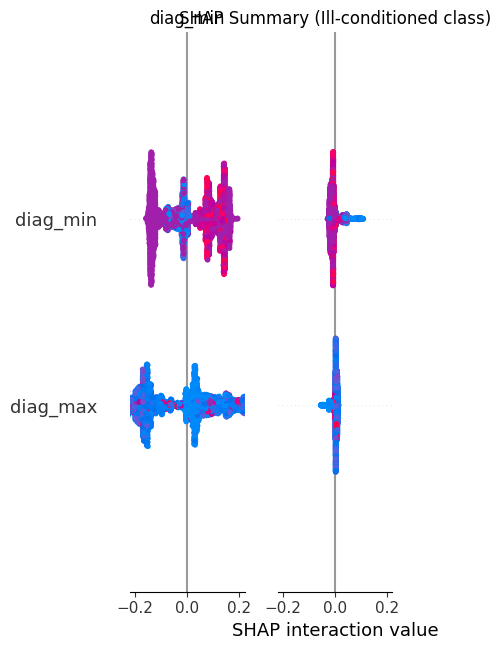

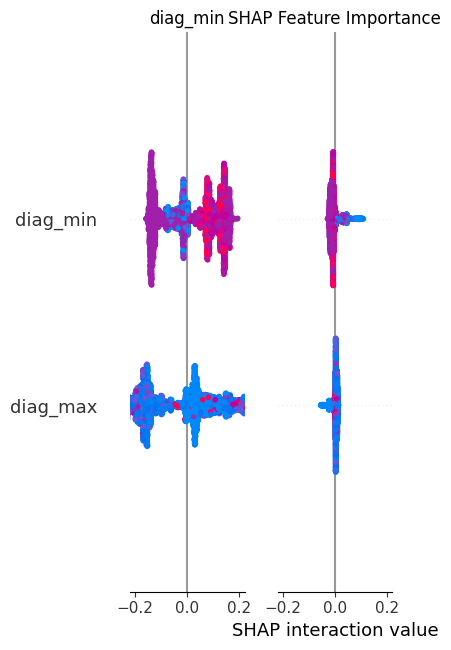

Saved: shap_summary.png, shap_importance.png

=== Optuna Hyperparameter Search (CV-based) ===


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost CLF params (seed=7): {'n_estimators': 298, 'max_depth': 4, 'learning_rate': 0.07667851821165755, 'subsample': 0.6196023986769786, 'colsample_bytree': 0.5360742532020513, 'reg_alpha': 0.6508316994845069, 'reg_lambda': 4.1513295014641765, 'min_child_weight': 16, 'gamma': 0.8600877102773782}
Best XGBoost CLF CV AUC (seed=7): 0.9917585016461716


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost REG params (seed=7): {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.06658365868556293, 'subsample': 0.6672596654218749, 'colsample_bytree': 0.42428359297572527, 'reg_alpha': 8.055348992552473, 'reg_lambda': 18.60953120406953, 'min_child_weight': 21, 'gamma': 3.114478715841873}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM CLF params (seed=7): {'n_estimators': 350, 'max_depth': 4, 'learning_rate': 0.09410708888999576, 'subsample': 0.7322931049837661, 'colsample_bytree': 0.4712771449033871, 'min_child_samples': 63, 'reg_alpha': 0.9023973917655359, 'reg_lambda': 3.607423880001591, 'num_leaves': 15}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM REG params (seed=7): {'n_estimators': 134, 'max_depth': 3, 'learning_rate': 0.09717165768743999, 'subsample': 0.6880816236411769, 'colsample_bytree': 0.5224580214355748, 'min_child_samples': 73, 'reg_alpha': 4.310681486375246, 'reg_lambda': 38.92058150759631, 'num_leaves': 13}

[Seed 7] MODEL 1 — RANDOM FOREST
  RF CV AUC=0.9781 | CV F1=0.9095 | Youden thresh=0.4337
Test -> AUC=0.9788 | Acc=0.9312 | Prec=0.8995 | Rec=0.9343 | F1=0.9166
              precision    recall  f1-score   support

   well-cond       0.95      0.93      0.94      1143
    ill-cond       0.90      0.93      0.92       776

    accuracy                           0.93      1919
   macro avg       0.93      0.93      0.93      1919
weighted avg       0.93      0.93      0.93      1919



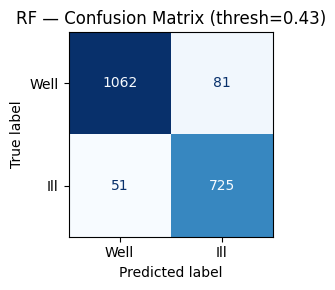

-- RF REGRESSION  MAE=1.9825  R2=0.6495

[Seed 7] MODEL 2 — XGBOOST
  XGB CV AUC=0.9913 | Youden thresh=0.3881
Test -> AUC=0.9919 | Acc=0.9552 | Prec=0.9137 | Rec=0.9820 | F1=0.9466
              precision    recall  f1-score   support

   well-cond       0.99      0.94      0.96      1143
    ill-cond       0.91      0.98      0.95       776

    accuracy                           0.96      1919
   macro avg       0.95      0.96      0.95      1919
weighted avg       0.96      0.96      0.96      1919



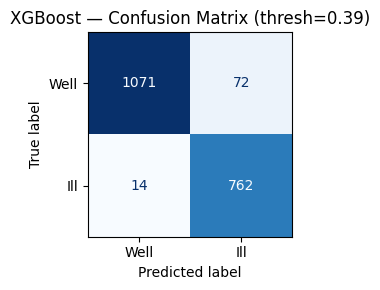

  XGB REG final fit stopped at iteration 249 (of 250 requested)
XGBoost REG  MAE=1.2973  R2=0.8298

[Seed 7] MODEL 2b — LIGHTGBM
  LGBM CV AUC=0.9929 | Youden thresh=0.3970
Test -> AUC=0.9929 | Acc=0.9578 | Prec=0.9253 | Rec=0.9742 | F1=0.9492
              precision    recall  f1-score   support

   well-cond       0.98      0.95      0.96      1143
    ill-cond       0.93      0.97      0.95       776

    accuracy                           0.96      1919
   macro avg       0.95      0.96      0.96      1919
weighted avg       0.96      0.96      0.96      1919



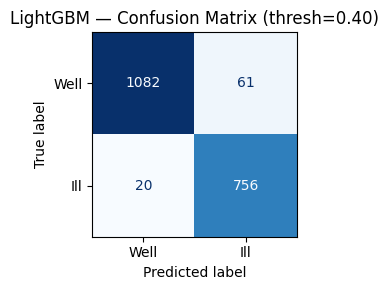

  LGBM REG final fit stopped at iteration 134 (of 134 requested)

LightGBM REG  MAE=1.2920  R2=0.6213

[Seed 7] MODEL 3 — NEURAL NETWORK
  Fold 1 best_epoch=196  CV-fold AUC=0.9505
  Fold 2 best_epoch=316  CV-fold AUC=0.9566
  Fold 3 best_epoch=260  CV-fold AUC=0.9574
  Fold 4 best_epoch=136  CV-fold AUC=0.9350
  NN overall CV AUC=0.9473 | Youden thresh=0.4121
Final NN fit early-stopped at epoch 269 (held-out val slice, 979 samples)


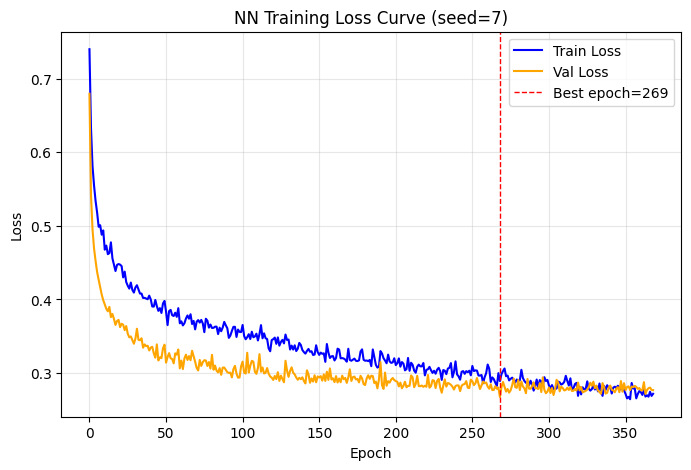

Test -> AUC=0.9493 | Acc=0.8572 | Prec=0.7582 | Rec=0.9497 | F1=0.8432
              precision    recall  f1-score   support

   well-cond       0.96      0.79      0.87      1143
    ill-cond       0.76      0.95      0.84       776

    accuracy                           0.86      1919
   macro avg       0.86      0.87      0.86      1919
weighted avg       0.88      0.86      0.86      1919



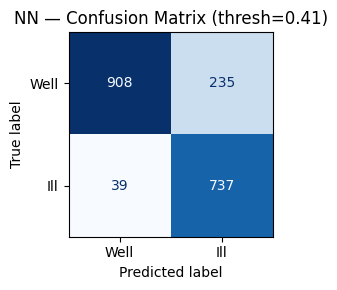

Final NN-REG fit early-stopped at epoch 340
  NN REG  MAE=1.2643  R2=0.8282 (early-stopped epoch=340)

[Seed 7] MODEL 3b — KAN
  Fold 1 best_epoch=35  CV-fold AUC=0.9363
  Fold 2 best_epoch=35  CV-fold AUC=0.9505
  Fold 3 best_epoch=31  CV-fold AUC=0.9437
  Fold 4 best_epoch=36  CV-fold AUC=0.9061
  KAN overall CV AUC=0.9301 | Youden thresh=0.2668
Final KAN fit early-stopped at epoch 102


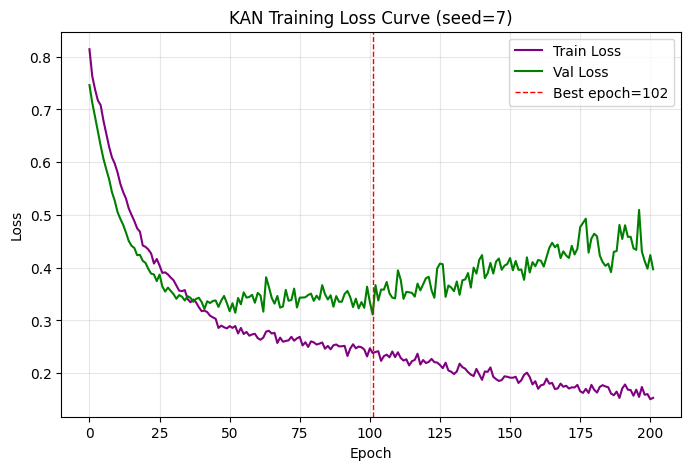

Test -> AUC=0.9414 | Acc=0.8134 | Prec=0.6903 | Rec=0.9768 | F1=0.8090
              precision    recall  f1-score   support

   well-cond       0.98      0.70      0.82      1143
    ill-cond       0.69      0.98      0.81       776

    accuracy                           0.81      1919
   macro avg       0.83      0.84      0.81      1919
weighted avg       0.86      0.81      0.81      1919



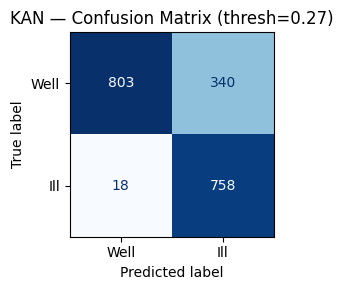

Final KAN-REG fit early-stopped at epoch 68
  KAN REG  MAE=1.5634  R2=0.7902 (early-stopped epoch=68)

[Seed 7] MODEL 4 — LOGISTIC REGRESSION
Best LR params : {'clf__C': 1.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'poly__degree': 2, 'select__k': 160}
Best CV AUC    : 0.8985
Test -> AUC=0.9078 | Acc=0.8301 | Prec=0.7414 | Rec=0.8905 | F1=0.8091
              precision    recall  f1-score   support

   well-cond       0.91      0.79      0.85      1143
    ill-cond       0.74      0.89      0.81       776

    accuracy                           0.83      1919
   macro avg       0.83      0.84      0.83      1919
weighted avg       0.84      0.83      0.83      1919



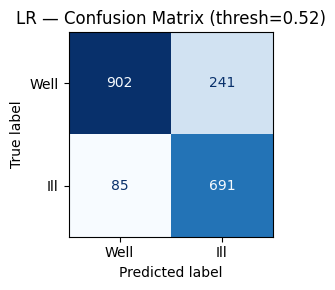


[Seed 7] MODEL 4b — RIDGE REGRESSION
Best Ridge alpha: 100.0000
Ridge REG  MAE=2.7959  R2=0.4490

[Seed 7] MODEL 5 — k-NEAREST NEIGHBOURS
  k= 25  CV AUC=0.8331 ± 0.0264
  k= 41  CV AUC=0.8279 ± 0.0277
  k= 61  CV AUC=0.8221 ± 0.0250
  k= 81  CV AUC=0.8171 ± 0.0228
  k=101  CV AUC=0.8151 ± 0.0219
  k=131  CV AUC=0.8109 ± 0.0225
  Best k=25 (CV AUC=0.8331, variance-penalized selection)
Test -> AUC=0.7952 | Acc=0.7499 | Prec=0.6869 | Rec=0.7010 | F1=0.6939
              precision    recall  f1-score   support

   well-cond       0.79      0.78      0.79      1143
    ill-cond       0.69      0.70      0.69       776

    accuracy                           0.75      1919
   macro avg       0.74      0.74      0.74      1919
weighted avg       0.75      0.75      0.75      1919



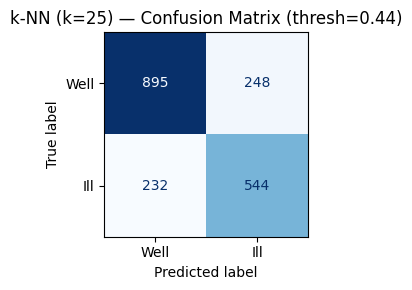

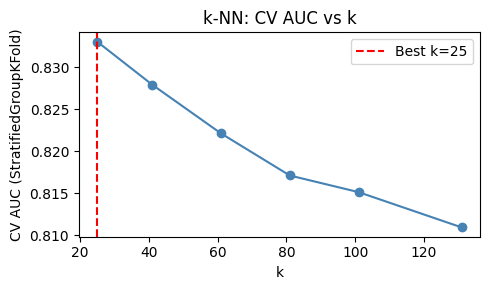

k-NN REG  MAE=2.9545  R2=0.2798


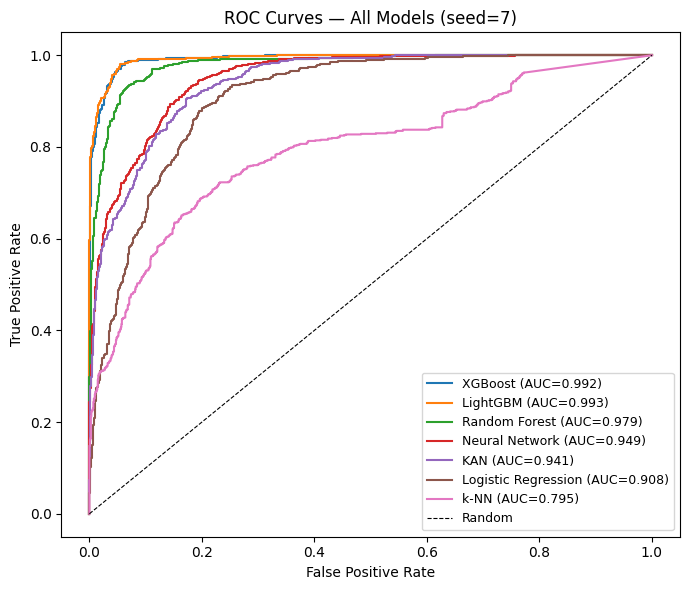

Saved: roc_all_models_seed7.png

SEED 7 — MODEL COMPARISON SUMMARY
              Model  Test AUC  Test Acc  Test Prec  Test Rec  Test F1  Reg MAE  Reg R2
           LightGBM    0.9929    0.9578     0.9253    0.9742   0.9492   1.2920  0.6213
            XGBoost    0.9919    0.9552     0.9137    0.9820   0.9466   1.2973  0.8298
      Random Forest    0.9788    0.9312     0.8995    0.9343   0.9166   1.9825  0.6495
     Neural Network    0.9493    0.8572     0.7582    0.9497   0.8432   1.2643  0.8282
                KAN    0.9414    0.8134     0.6903    0.9768   0.8090   1.5634  0.7902
Logistic Regression    0.9078    0.8301     0.7414    0.8905   0.8091   2.7959  0.4490
               k-NN    0.7952    0.7499     0.6869    0.7010   0.6939   2.9545  0.2798

  SEED = 42
   Used StratifiedGroupKFold (n_splits=4) for outer split
   Train size: 6031, Test size: 1969
   Train grid_size groups (6): [20, 25, 35, 40, 50, 80]
   Test  grid_size groups (2): [30, 45]
Final Split -> Train: 6031 (75.4%

  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost CLF params (seed=42): {'n_estimators': 395, 'max_depth': 4, 'learning_rate': 0.0614183189279872, 'subsample': 0.5446750329825268, 'colsample_bytree': 0.4838309769820703, 'reg_alpha': 2.925946275034849, 'reg_lambda': 7.84042192410965, 'min_child_weight': 7, 'gamma': 0.4947944457212319}
Best XGBoost CLF CV AUC (seed=42): 0.9912530843465069


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost REG params (seed=42): {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.07816888622645288, 'subsample': 0.5933536323491303, 'colsample_bytree': 0.38770301769420884, 'reg_alpha': 7.794819225511562, 'reg_lambda': 25.085508904058194, 'min_child_weight': 36, 'gamma': 1.9775861971850413}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM CLF params (seed=42): {'n_estimators': 254, 'max_depth': 4, 'learning_rate': 0.09797995562876463, 'subsample': 0.7964435411861552, 'colsample_bytree': 0.4028677662295939, 'min_child_samples': 49, 'reg_alpha': 1.6850257321055349, 'reg_lambda': 3.098329740247363, 'num_leaves': 21}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM REG params (seed=42): {'n_estimators': 101, 'max_depth': 3, 'learning_rate': 0.08082480872308548, 'subsample': 0.6404376427334536, 'colsample_bytree': 0.46369686828189943, 'min_child_samples': 70, 'reg_alpha': 11.96536787239478, 'reg_lambda': 12.519822075533693, 'num_leaves': 11}

[Seed 42] MODEL 1 — RANDOM FOREST
  RF CV AUC=0.9771 | CV F1=0.9052 | Youden thresh=0.3916
Test -> AUC=0.9808 | Acc=0.9253 | Prec=0.8721 | Rec=0.9562 | F1=0.9122
              precision    recall  f1-score   support

   well-cond       0.97      0.90      0.94      1170
    ill-cond       0.87      0.96      0.91       799

    accuracy                           0.93      1969
   macro avg       0.92      0.93      0.92      1969
weighted avg       0.93      0.93      0.93      1969

-- RF REGRESSION  MAE=2.0031  R2=0.6423

[Seed 42] MODEL 2 — XGBOOST
  XGB CV AUC=0.9902 | Youden thresh=0.3693
Test -> AUC=0.9934 | Acc=0.9584 | Prec=0.9154 | Rec=0.9887 | F1=0.9507
              precision    recal

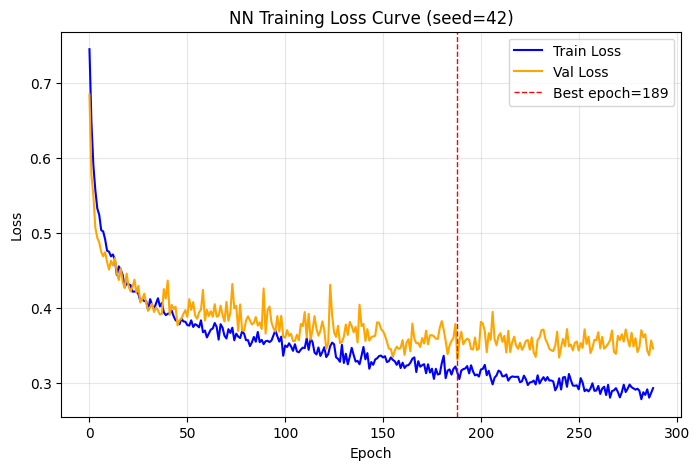

Test -> AUC=0.9543 | Acc=0.8751 | Prec=0.8103 | Rec=0.9036 | F1=0.8544
              precision    recall  f1-score   support

   well-cond       0.93      0.86      0.89      1170
    ill-cond       0.81      0.90      0.85       799

    accuracy                           0.88      1969
   macro avg       0.87      0.88      0.87      1969
weighted avg       0.88      0.88      0.88      1969

Final NN-REG fit early-stopped at epoch 213
  NN REG  MAE=1.3693  R2=0.8161 (early-stopped epoch=213)

[Seed 42] MODEL 3b — KAN
  Fold 1 best_epoch=35  CV-fold AUC=0.9241
  Fold 2 best_epoch=31  CV-fold AUC=0.9298
  Fold 3 best_epoch=29  CV-fold AUC=0.9428
  Fold 4 best_epoch=33  CV-fold AUC=0.9356
  KAN overall CV AUC=0.9316 | Youden thresh=0.3642
Final KAN fit early-stopped at epoch 33


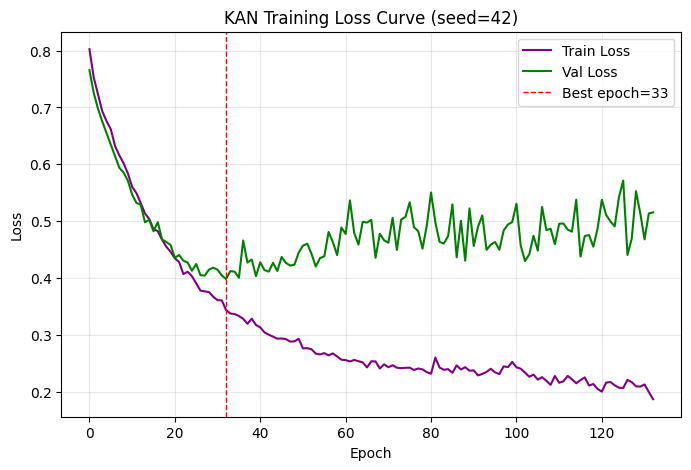

Test -> AUC=0.9447 | Acc=0.8492 | Prec=0.7495 | Rec=0.9437 | F1=0.8355
              precision    recall  f1-score   support

   well-cond       0.95      0.78      0.86      1170
    ill-cond       0.75      0.94      0.84       799

    accuracy                           0.85      1969
   macro avg       0.85      0.86      0.85      1969
weighted avg       0.87      0.85      0.85      1969

Final KAN-REG fit early-stopped at epoch 72
  KAN REG  MAE=1.4500  R2=0.8134 (early-stopped epoch=72)

[Seed 42] MODEL 4 — LOGISTIC REGRESSION
Best LR params : {'clf__C': 2.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'poly__degree': 2, 'select__k': 160}
Best CV AUC    : 0.8982
Test -> AUC=0.9140 | Acc=0.8294 | Prec=0.7254 | Rec=0.9324 | F1=0.8160
              precision    recall  f1-score   support

   well-cond       0.94      0.76      0.84      1170
    ill-cond       0.73      0.93      0.82       799

    accuracy                           0.83      1969
   macro avg       0.83      0

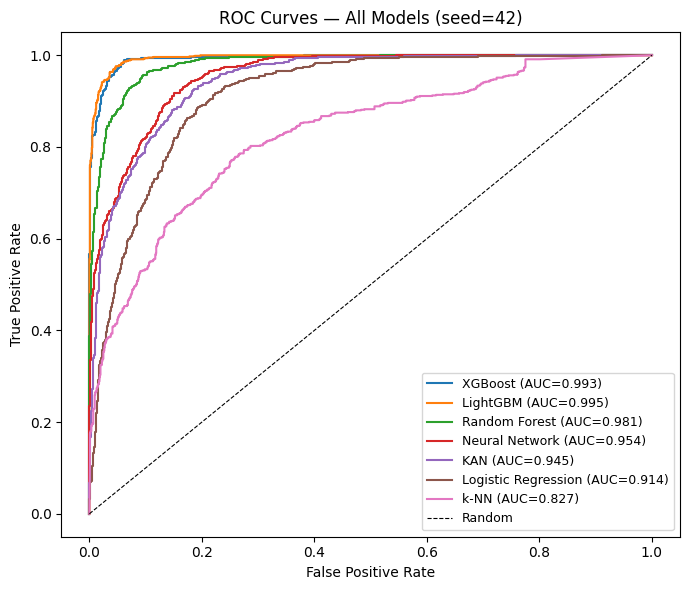

Saved: roc_all_models_seed42.png

SEED 42 — MODEL COMPARISON SUMMARY
              Model  Test AUC  Test Acc  Test Prec  Test Rec  Test F1  Reg MAE  Reg R2
           LightGBM    0.9947    0.9584     0.9223    0.9800   0.9502   1.3935  0.5987
            XGBoost    0.9934    0.9584     0.9154    0.9887   0.9507   1.3387  0.8204
      Random Forest    0.9808    0.9253     0.8721    0.9562   0.9122   2.0031  0.6423
     Neural Network    0.9543    0.8751     0.8103    0.9036   0.8544   1.3693  0.8161
                KAN    0.9447    0.8492     0.7495    0.9437   0.8355   1.4500  0.8134
Logistic Regression    0.9140    0.8294     0.7254    0.9324   0.8160   2.7927  0.4547
               k-NN    0.8268    0.7572     0.6994    0.7046   0.7020   2.8113  0.3883

  SEED = 123
   Used StratifiedGroupKFold (n_splits=4) for outer split
   Train size: 5967, Test size: 2033
   Train grid_size groups (6): [25, 30, 35, 45, 50, 80]
   Test  grid_size groups (2): [20, 40]
Final Split -> Train: 5967 (74

  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost CLF params (seed=123): {'n_estimators': 290, 'max_depth': 4, 'learning_rate': 0.07467654481162901, 'subsample': 0.6252711449291795, 'colsample_bytree': 0.5930542342919076, 'reg_alpha': 1.2182653359331725, 'reg_lambda': 7.349664867211851, 'min_child_weight': 13, 'gamma': 0.9097261438784392}
Best XGBoost CLF CV AUC (seed=123): 0.9907248023287174


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost REG params (seed=123): {'n_estimators': 219, 'max_depth': 3, 'learning_rate': 0.058877689342861916, 'subsample': 0.5305977776884889, 'colsample_bytree': 0.4776183475210412, 'reg_alpha': 3.653968486856155, 'reg_lambda': 25.050282668267457, 'min_child_weight': 22, 'gamma': 1.2167230086174163}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM CLF params (seed=123): {'n_estimators': 238, 'max_depth': 4, 'learning_rate': 0.08990103333323986, 'subsample': 0.6093624898997917, 'colsample_bytree': 0.5214611144096066, 'min_child_samples': 60, 'reg_alpha': 1.4382680879579537, 'reg_lambda': 3.994863448498379, 'num_leaves': 16}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM REG params (seed=123): {'n_estimators': 102, 'max_depth': 3, 'learning_rate': 0.09973431543090125, 'subsample': 0.5963187394245029, 'colsample_bytree': 0.4787070299067911, 'min_child_samples': 120, 'reg_alpha': 14.880436081246721, 'reg_lambda': 27.333939914812927, 'num_leaves': 11}

[Seed 123] MODEL 1 — RANDOM FOREST
  RF CV AUC=0.9762 | CV F1=0.8983 | Youden thresh=0.3812
Test -> AUC=0.9830 | Acc=0.9228 | Prec=0.8839 | Rec=0.9373 | F1=0.9098
              precision    recall  f1-score   support

   well-cond       0.95      0.91      0.93      1188
    ill-cond       0.88      0.94      0.91       845

    accuracy                           0.92      2033
   macro avg       0.92      0.92      0.92      2033
weighted avg       0.92      0.92      0.92      2033

-- RF REGRESSION  MAE=2.1476  R2=0.6175

[Seed 123] MODEL 2 — XGBOOST
  XGB CV AUC=0.9903 | Youden thresh=0.4375
Test -> AUC=0.9928 | Acc=0.9606 | Prec=0.9432 | Rec=0.9633 | F1=0.9532
              precision    r

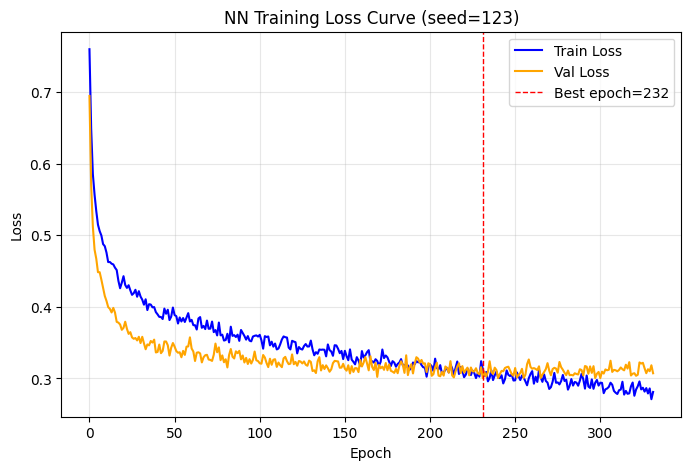

Test -> AUC=0.9491 | Acc=0.8682 | Prec=0.8040 | Rec=0.9030 | F1=0.8506
              precision    recall  f1-score   support

   well-cond       0.92      0.84      0.88      1188
    ill-cond       0.80      0.90      0.85       845

    accuracy                           0.87      2033
   macro avg       0.86      0.87      0.87      2033
weighted avg       0.87      0.87      0.87      2033

Final NN-REG fit early-stopped at epoch 439
  NN REG  MAE=1.2919  R2=0.8342 (early-stopped epoch=439)

[Seed 123] MODEL 3b — KAN
  Fold 1 best_epoch=17  CV-fold AUC=0.8705
  Fold 2 best_epoch=33  CV-fold AUC=0.9333
  Fold 3 best_epoch=33  CV-fold AUC=0.9479
  Fold 4 best_epoch=36  CV-fold AUC=0.9454
  KAN overall CV AUC=0.9189 | Youden thresh=0.4719
Final KAN fit early-stopped at epoch 43


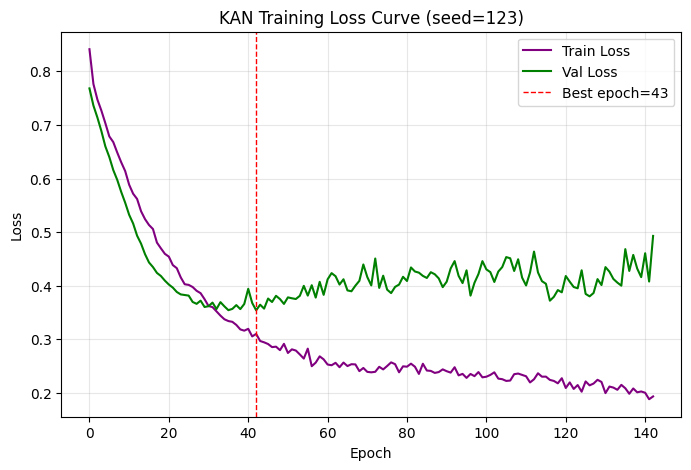

Test -> AUC=0.9350 | Acc=0.8387 | Prec=0.7478 | Rec=0.9231 | F1=0.8263
              precision    recall  f1-score   support

   well-cond       0.93      0.78      0.85      1188
    ill-cond       0.75      0.92      0.83       845

    accuracy                           0.84      2033
   macro avg       0.84      0.85      0.84      2033
weighted avg       0.86      0.84      0.84      2033

Final KAN-REG fit early-stopped at epoch 62
  KAN REG  MAE=1.6579  R2=0.7679 (early-stopped epoch=62)

[Seed 123] MODEL 4 — LOGISTIC REGRESSION
Best LR params : {'clf__C': 2.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'poly__degree': 2, 'select__k': 160}
Best CV AUC    : 0.8947
Test -> AUC=0.9175 | Acc=0.8367 | Prec=0.7703 | Rec=0.8651 | F1=0.8149
              precision    recall  f1-score   support

   well-cond       0.89      0.82      0.85      1188
    ill-cond       0.77      0.87      0.81       845

    accuracy                           0.84      2033
   macro avg       0.83      

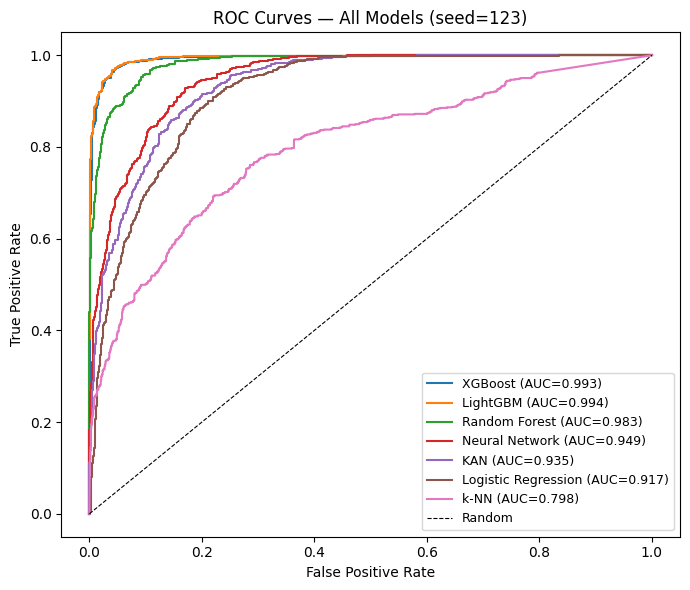

Saved: roc_all_models_seed123.png

SEED 123 — MODEL COMPARISON SUMMARY
              Model  Test AUC  Test Acc  Test Prec  Test Rec  Test F1  Reg MAE  Reg R2
           LightGBM    0.9940    0.9611     0.9581    0.9479   0.9530   1.5677  0.5578
            XGBoost    0.9928    0.9606     0.9432    0.9633   0.9532   1.6064  0.7781
      Random Forest    0.9830    0.9228     0.8839    0.9373   0.9098   2.1476  0.6175
     Neural Network    0.9491    0.8682     0.8040    0.9030   0.8506   1.2919  0.8342
                KAN    0.9350    0.8387     0.7478    0.9231   0.8263   1.6579  0.7679
Logistic Regression    0.9175    0.8367     0.7703    0.8651   0.8149   3.0226  0.4555
               k-NN    0.7983    0.7319     0.6689    0.7030   0.6855   3.2152  0.2533

  SEED = 999
   Used StratifiedGroupKFold (n_splits=4) for outer split
   Train size: 6027, Test size: 1973
   Train grid_size groups (6): [20, 25, 30, 35, 40, 45]
   Test  grid_size groups (2): [50, 80]
Final Split -> Train: 6027 (

  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost CLF params (seed=999): {'n_estimators': 376, 'max_depth': 4, 'learning_rate': 0.09870392078082689, 'subsample': 0.7714473249641008, 'colsample_bytree': 0.3868153725309794, 'reg_alpha': 0.8367806672384261, 'reg_lambda': 4.483631723721834, 'min_child_weight': 5, 'gamma': 2.2465507753361535}
Best XGBoost CLF CV AUC (seed=999): 0.9925078651164567


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost REG params (seed=999): {'n_estimators': 236, 'max_depth': 3, 'learning_rate': 0.07947043657267286, 'subsample': 0.6644499223217966, 'colsample_bytree': 0.3997289961383185, 'reg_alpha': 3.7801744887471123, 'reg_lambda': 10.041000783142868, 'min_child_weight': 15, 'gamma': 4.482982022709766}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM CLF params (seed=999): {'n_estimators': 297, 'max_depth': 4, 'learning_rate': 0.08251636320010243, 'subsample': 0.7878245508504464, 'colsample_bytree': 0.42805162476111863, 'min_child_samples': 71, 'reg_alpha': 0.882560398750541, 'reg_lambda': 11.630337239124172, 'num_leaves': 16}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM REG params (seed=999): {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.09870961386834691, 'subsample': 0.7921122993621668, 'colsample_bytree': 0.4675913005811625, 'min_child_samples': 91, 'reg_alpha': 15.25297686105999, 'reg_lambda': 16.666611070916762, 'num_leaves': 8}

[Seed 999] MODEL 1 — RANDOM FOREST
  RF CV AUC=0.9799 | CV F1=0.9058 | Youden thresh=0.4179
Test -> AUC=0.9764 | Acc=0.9159 | Prec=0.8980 | Rec=0.9044 | F1=0.9012
              precision    recall  f1-score   support

   well-cond       0.93      0.92      0.93      1136
    ill-cond       0.90      0.90      0.90       837

    accuracy                           0.92      1973
   macro avg       0.91      0.91      0.91      1973
weighted avg       0.92      0.92      0.92      1973

-- RF REGRESSION  MAE=1.9656  R2=0.5829

[Seed 999] MODEL 2 — XGBOOST
  XGB CV AUC=0.9920 | Youden thresh=0.4029
Test -> AUC=0.9886 | Acc=0.9448 | Prec=0.9062 | Rec=0.9701 | F1=0.9371
              precision    reca

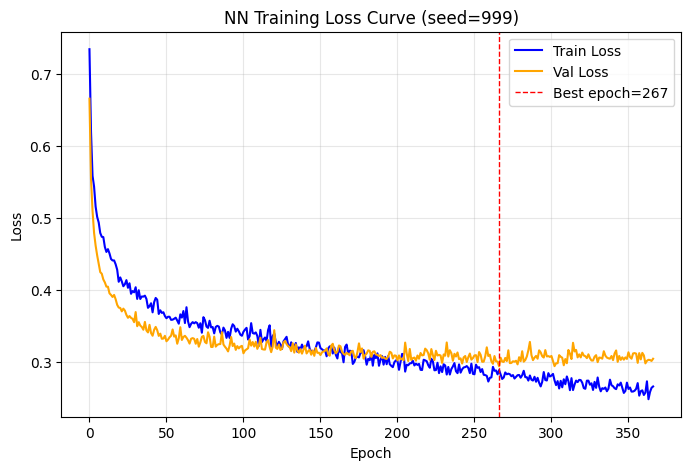

Test -> AUC=0.9152 | Acc=0.8125 | Prec=0.7197 | Rec=0.9140 | F1=0.8053
              precision    recall  f1-score   support

   well-cond       0.92      0.74      0.82      1136
    ill-cond       0.72      0.91      0.81       837

    accuracy                           0.81      1973
   macro avg       0.82      0.83      0.81      1973
weighted avg       0.84      0.81      0.81      1973

Final NN-REG fit early-stopped at epoch 405
  NN REG  MAE=1.5897  R2=0.7456 (early-stopped epoch=405)

[Seed 999] MODEL 3b — KAN
  Fold 1 best_epoch=38  CV-fold AUC=0.9491
  Fold 2 best_epoch=31  CV-fold AUC=0.9400
  Fold 3 best_epoch=29  CV-fold AUC=0.9136
  Fold 4 best_epoch=37  CV-fold AUC=0.9464
  KAN overall CV AUC=0.9344 | Youden thresh=0.2976
Final KAN fit early-stopped at epoch 42


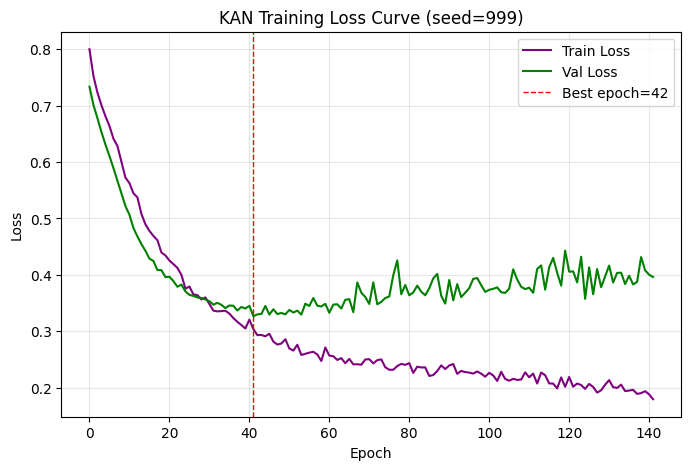

Test -> AUC=0.8858 | Acc=0.7816 | Prec=0.7034 | Rec=0.8387 | F1=0.7651
              precision    recall  f1-score   support

   well-cond       0.86      0.74      0.80      1136
    ill-cond       0.70      0.84      0.77       837

    accuracy                           0.78      1973
   macro avg       0.78      0.79      0.78      1973
weighted avg       0.79      0.78      0.78      1973

Final KAN-REG fit early-stopped at epoch 148
  KAN REG  MAE=2.0138  R2=0.6235 (early-stopped epoch=148)

[Seed 999] MODEL 4 — LOGISTIC REGRESSION
Best LR params : {'clf__C': 2.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'poly__degree': 2, 'select__k': 160}
Best CV AUC    : 0.8844
Test -> AUC=0.8645 | Acc=0.7577 | Prec=0.6546 | Rec=0.9080 | F1=0.7608
              precision    recall  f1-score   support

   well-cond       0.91      0.65      0.75      1136
    ill-cond       0.65      0.91      0.76       837

    accuracy                           0.76      1973
   macro avg       0.78    

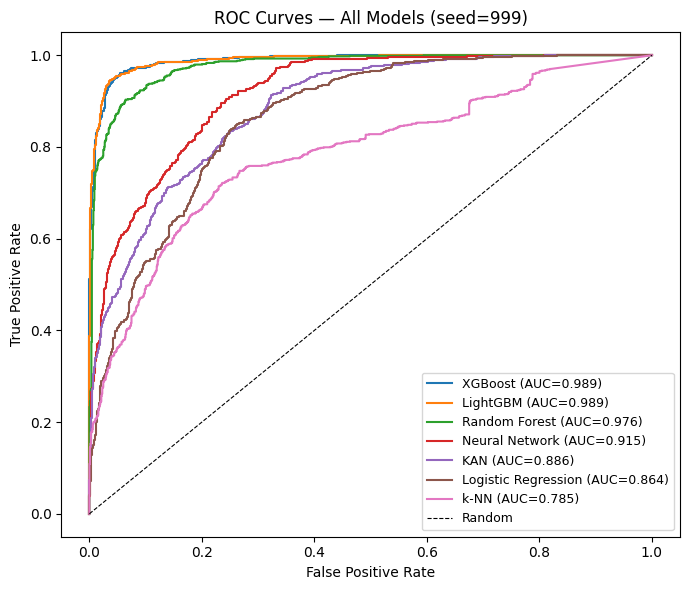

Saved: roc_all_models_seed999.png

SEED 999 — MODEL COMPARISON SUMMARY
              Model  Test AUC  Test Acc  Test Prec  Test Rec  Test F1  Reg MAE  Reg R2
           LightGBM    0.9890    0.9422     0.9021    0.9689   0.9343   1.3805  0.6065
            XGBoost    0.9886    0.9448     0.9062    0.9701   0.9371   1.5132  0.7426
      Random Forest    0.9764    0.9159     0.8980    0.9044   0.9012   1.9656  0.5829
     Neural Network    0.9152    0.8125     0.7197    0.9140   0.8053   1.5897  0.7456
                KAN    0.8858    0.7816     0.7034    0.8387   0.7651   2.0138  0.6235
Logistic Regression    0.8645    0.7577     0.6546    0.9080   0.7608   2.9280  0.4121
               k-NN    0.7849    0.7420     0.6839    0.7288   0.7056   3.0735  0.2281

  SEED = 2024
   Used StratifiedGroupKFold (n_splits=4) for outer split
   Train size: 6026, Test size: 1974
   Train grid_size groups (6): [20, 25, 35, 40, 45, 50]
   Test  grid_size groups (2): [30, 80]
Final Split -> Train: 6026 

  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost CLF params (seed=2024): {'n_estimators': 357, 'max_depth': 4, 'learning_rate': 0.06175578880861611, 'subsample': 0.6527210245473254, 'colsample_bytree': 0.5096004271352625, 'reg_alpha': 0.7001954914067651, 'reg_lambda': 6.953493350645937, 'min_child_weight': 16, 'gamma': 2.5189358042580103}
Best XGBoost CLF CV AUC (seed=2024): 0.9911714896628487


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost REG params (seed=2024): {'n_estimators': 220, 'max_depth': 3, 'learning_rate': 0.06972254517042575, 'subsample': 0.6468013860382417, 'colsample_bytree': 0.45527993397961175, 'reg_alpha': 16.383411194647298, 'reg_lambda': 11.714853317764586, 'min_child_weight': 21, 'gamma': 1.1256697644338123}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM CLF params (seed=2024): {'n_estimators': 330, 'max_depth': 4, 'learning_rate': 0.0972993339423668, 'subsample': 0.7865711729567668, 'colsample_bytree': 0.5987407494778599, 'min_child_samples': 69, 'reg_alpha': 0.5361886033957188, 'reg_lambda': 11.416315393617728, 'num_leaves': 21}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM REG params (seed=2024): {'n_estimators': 119, 'max_depth': 3, 'learning_rate': 0.09739386839384173, 'subsample': 0.7729118069109991, 'colsample_bytree': 0.349528249670093, 'min_child_samples': 75, 'reg_alpha': 15.012085091994244, 'reg_lambda': 36.422969637981126, 'num_leaves': 8}

[Seed 2024] MODEL 1 — RANDOM FOREST
  RF CV AUC=0.9793 | CV F1=0.9031 | Youden thresh=0.4051
Test -> AUC=0.9764 | Acc=0.9184 | Prec=0.8907 | Rec=0.9158 | F1=0.9031
              precision    recall  f1-score   support

   well-cond       0.94      0.92      0.93      1155
    ill-cond       0.89      0.92      0.90       819

    accuracy                           0.92      1974
   macro avg       0.91      0.92      0.92      1974
weighted avg       0.92      0.92      0.92      1974

-- RF REGRESSION  MAE=2.0298  R2=0.5888

[Seed 2024] MODEL 2 — XGBOOST
  XGB CV AUC=0.9909 | Youden thresh=0.5266
Test -> AUC=0.9891 | Acc=0.9488 | Prec=0.9378 | Rec=0.9389 | F1=0.9384
              precision    r

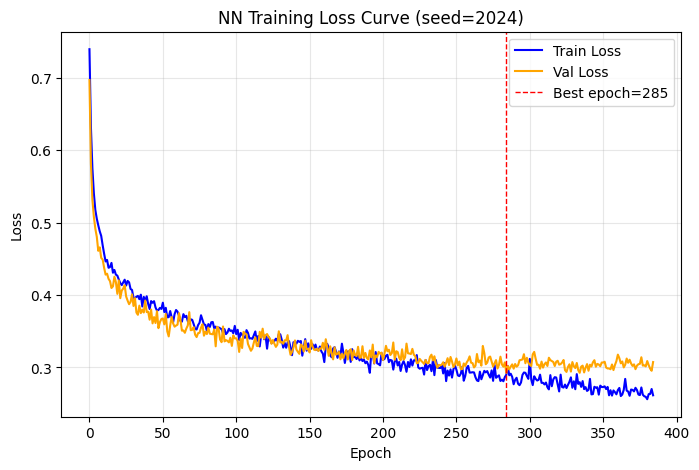

Test -> AUC=0.9408 | Acc=0.8521 | Prec=0.7892 | Rec=0.8779 | F1=0.8312
              precision    recall  f1-score   support

   well-cond       0.91      0.83      0.87      1155
    ill-cond       0.79      0.88      0.83       819

    accuracy                           0.85      1974
   macro avg       0.85      0.86      0.85      1974
weighted avg       0.86      0.85      0.85      1974

Final NN-REG fit early-stopped at epoch 448
  NN REG  MAE=1.4182  R2=0.7945 (early-stopped epoch=448)

[Seed 2024] MODEL 3b — KAN
  Fold 1 best_epoch=28  CV-fold AUC=0.9366
  Fold 2 best_epoch=37  CV-fold AUC=0.9398
  Fold 3 best_epoch=35  CV-fold AUC=0.9298
  Fold 4 best_epoch=39  CV-fold AUC=0.9512
  KAN overall CV AUC=0.9394 | Youden thresh=0.5024
Final KAN fit early-stopped at epoch 55


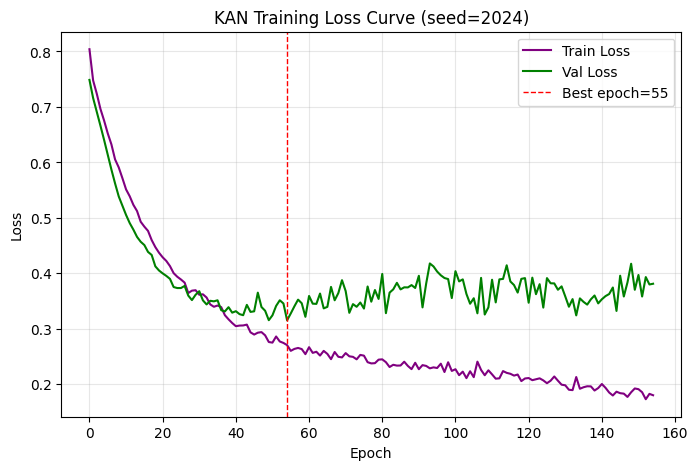

Test -> AUC=0.9091 | Acc=0.8055 | Prec=0.7689 | Rec=0.7595 | F1=0.7641
              precision    recall  f1-score   support

   well-cond       0.83      0.84      0.83      1155
    ill-cond       0.77      0.76      0.76       819

    accuracy                           0.81      1974
   macro avg       0.80      0.80      0.80      1974
weighted avg       0.81      0.81      0.81      1974

Final KAN-REG fit early-stopped at epoch 90
  KAN REG  MAE=1.9256  R2=0.6710 (early-stopped epoch=90)

[Seed 2024] MODEL 4 — LOGISTIC REGRESSION
Best LR params : {'clf__C': 2.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'poly__degree': 2, 'select__k': 160}
Best CV AUC    : 0.8985
Test -> AUC=0.8763 | Acc=0.7842 | Prec=0.6899 | Rec=0.8718 | F1=0.7702
              precision    recall  f1-score   support

   well-cond       0.89      0.72      0.80      1155
    ill-cond       0.69      0.87      0.77       819

    accuracy                           0.78      1974
   macro avg       0.79     

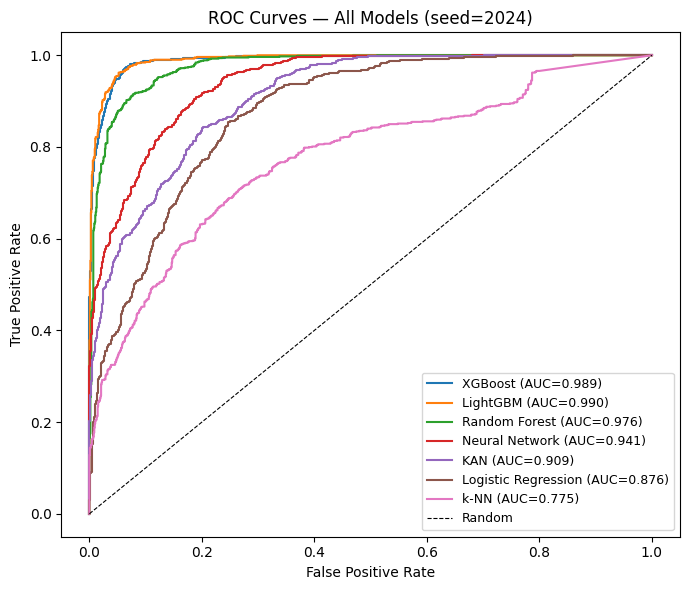

Saved: roc_all_models_seed2024.png

SEED 2024 — MODEL COMPARISON SUMMARY
              Model  Test AUC  Test Acc  Test Prec  Test Rec  Test F1  Reg MAE  Reg R2
           LightGBM    0.9904    0.9514     0.9288    0.9560   0.9422   1.5310  0.5484
            XGBoost    0.9891    0.9488     0.9378    0.9389   0.9384   1.4849  0.7596
      Random Forest    0.9764    0.9184     0.8907    0.9158   0.9031   2.0298  0.5888
     Neural Network    0.9408    0.8521     0.7892    0.8779   0.8312   1.4182  0.7945
                KAN    0.9091    0.8055     0.7689    0.7595   0.7641   1.9256  0.6710
Logistic Regression    0.8763    0.7842     0.6899    0.8718   0.7702   2.8419  0.4334
               k-NN    0.7752    0.7209     0.6486    0.7143   0.6798   3.0952  0.2294


In [ ]:
# ================================================================
# MULTI-SEED LOOP
# ================================================================
for seed in SEEDS:
    print(f"\n{'='*70}\n  SEED = {seed}\n{'='*70}")
    torch.manual_seed(seed)
    np.random.seed(seed)

    # ============================================================
    # 5. GROUP-AWARE, STRATIFIED TRAIN / TEST SPLITGM
    # ============================================================
    X = df.drop(columns=[target_col, 'pde_type'], errors='ignore')
    y = df[target_col]
    groups_all = df['grid_size']

    strat_key = df['pde_type'].astype(str) + '_' + df['ill_conditioned'].astype(str)
    min_samples = strat_key.value_counts().min()

    if min_samples < 2:
        print(f"⚠️  Rare combinations detected (min={min_samples}). Using fallback to binary target.")
        strat_key_final = y.copy()
    else:
        strat_key_final = strat_key

    train_idx, test_idx = group_stratified_split(X, strat_key_final, groups_all, N_SPLITS, seed)
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

    overlap = set(groups_all.iloc[train_idx]) & set(groups_all.iloc[test_idx])
    assert len(overlap) == 0, f"Group leakage detected! Overlapping grid_size groups: {overlap}"

    y_train_reg     = df_raw.loc[X_train.index, 'log10_cond'].values
    y_test_reg      = df_raw.loc[X_test.index,  'log10_cond'].values
    pde_test_labels = df.loc[X_test.index, 'pde_type'].values

    print(f"Final Split -> Train: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%) | "
          f"Test: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
    print(f"   Stratification used: {'PDE + Target' if min_samples >= 2 else 'Target only'}")
    print(f"   Group overlap check passed (0 shared grid_size groups).")

    groups_train = X_train['grid_size'].reset_index(drop=True)
    X_train = X_train.drop(columns=['grid_size', 'mesh_size'], errors='ignore')
    X_test  = X_test.drop(columns=['grid_size', 'mesh_size'], errors='ignore')

    # ============================================================
    # 6. SCALE (fit on train only)
    # ============================================================
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    feature_cols = X_train.columns.tolist()
    X_train_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
    X_test_df  = pd.DataFrame(X_test_scaled,  columns=feature_cols, index=X_test.index)

    y_train = y_train.reset_index(drop=True)
    y_test  = y_test.reset_index(drop=True)
    X_train_df = X_train_df.reset_index(drop=True)
    X_test_df  = X_test_df.reset_index(drop=True)

    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    gkf   = GroupKFold(n_splits=N_SPLITS)

    # ============================================================
    # 7. STRATIFIED GROUP K-FOLD DIAGNOSTIC
    # ============================================================
    if seed == SEEDS[0]:
        print(f"\n=== StratifiedGroupKFold Diagnostic (n_splits={N_SPLITS}) ===")
        fold_stats = []
        for fold, (tr_idx, cv_idx) in enumerate(sgkf.split(X_train_df, y_train, groups=groups_train)):
            fold_y_tr = y_train.iloc[tr_idx]
            fold_y_cv = y_train.iloc[cv_idx]
            fold_grids_cv = groups_train.iloc[cv_idx].unique()
            fold_pde_cv = df.loc[X_train.index].reset_index(drop=True).iloc[cv_idx]['pde_type'].value_counts()
            print(f"Fold {fold+1} | Train={len(tr_idx)} CV={len(cv_idx)} | "
                  f"CV grids={sorted(fold_grids_cv)} | Ill rate train={fold_y_tr.mean():.3f} "
                  f"cv={fold_y_cv.mean():.3f} | PDE types in CV fold={len(fold_pde_cv)}/14")
            fold_stats.append({'fold': fold+1, 'cv_size': len(cv_idx),
                                'pde_covered': len(fold_pde_cv), 'ill_rate_cv': fold_y_cv.mean()})
        fold_df = pd.DataFrame(fold_stats)
        print(fold_df.to_string(index=False))

    # ============================================================
    # 8. BORUTA FEATURE SELECTION
    # ============================================================
    try:
        from boruta import BorutaPy
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'pip', 'install', 'Boruta'], check=True)
        from boruta import BorutaPy

    print(f"\n=== Boruta Feature Selection (seed={seed}, on this seed's train set) ===")
    rf_boruta = RandomForestClassifier(
        n_estimators=200, max_depth=7, class_weight='balanced',
        random_state=seed, n_jobs=-1
    )
    boruta_selector = BorutaPy(
        estimator=rf_boruta, n_estimators='auto', perc=100,
        max_iter=100, random_state=seed, verbose=0
    )
    boruta_selector.fit(X_train_df.values, y_train.values)
    selected = [f for f, s in zip(feature_cols, boruta_selector.support_) if s]
    final_features = [f for f in selected if f in X_train_df.columns]
    if len(final_features) == 0:
        print("⚠️  Boruta selected 0 features — falling back to all features.")
        final_features = feature_cols[:]
    final_features_by_seed[seed] = final_features
    print(f"Confirmed: {len(selected)} | Final: {len(final_features)}")

    X_train_final = X_train_df[final_features].reset_index(drop=True)
    X_test_final  = X_test_df[final_features].reset_index(drop=True)
    groups_train  = groups_train.reset_index(drop=True)

    assert len(X_train_final) == len(y_train) == len(y_train_reg) == len(groups_train)
    assert len(X_test_final)  == len(y_test)  == len(y_test_reg)
    print(f"[Seed {seed}] Shapes verified: Train={len(X_train_final)} Test={len(X_test_final)}")

    # ============================================================
    # 9. SHAP
    # ============================================================
    if seed == SEEDS[0]:
        print("\n=== SHAP (first seed only, on train set) ===")
        rf_shap = RandomForestClassifier(
            n_estimators=300, max_depth=7, class_weight='balanced',
            random_state=seed, n_jobs=-1
        )
        rf_shap.fit(X_train_final, y_train)
        explainer = shap.TreeExplainer(rf_shap)
        shap_values = explainer.shap_values(X_train_final)
        shap_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

        shap.summary_plot(shap_class1, X_train_final, feature_names=final_features, show=False)
        plt.title("SHAP Summary (Ill-conditioned class)")
        plt.tight_layout(); plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight'); plt.show()

        shap.summary_plot(shap_class1, X_train_final, feature_names=final_features,
                           plot_type='bar', show=False)
        plt.title("SHAP Feature Importance")
        plt.tight_layout(); plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight'); plt.show()
        print("Saved: shap_summary.png, shap_importance.png")

    # ============================================================
    # 10. POWER TRANSFORM (for LR / NN / KAN / Ridge)
    # ============================================================
    X_train_raw = X_train[final_features].reset_index(drop=True)
    X_test_raw  = X_test[final_features].reset_index(drop=True)

    pt = PowerTransformer(method='yeo-johnson', standardize=True)
    X_train_pt = pt.fit_transform(X_train_raw)
    X_test_pt  = pt.transform(X_test_raw)

    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

    # ============================================================
    # OPTUNA — CV-based objectives
    # ============================================================
    print("\n=== Optuna Hyperparameter Search (CV-based) ===")

    def xgb_clf_objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 400),
            'max_depth':        trial.suggest_int('max_depth', 2, 4),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample':        trial.suggest_float('subsample', 0.5, 0.8),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.6),
            'reg_alpha':        trial.suggest_float('reg_alpha', 0.5, 15.0, log=True),
            'reg_lambda':       trial.suggest_float('reg_lambda', 3.0, 30.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 5, 30),
            'gamma':            trial.suggest_float('gamma', 0.1, 3.0),
        }
        model = xgb.XGBClassifier(**params, scale_pos_weight=scale_pos,
                                   eval_metric='logloss', random_state=seed,
                                   n_jobs=-1, verbosity=0)
        scores = cross_val_score(model, X_train_final, y_train, groups=groups_train,
                                  cv=sgkf, scoring='roc_auc', n_jobs=-1)
        return scores.mean()

    def lgb_clf_objective(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 350),
            'max_depth':         trial.suggest_int('max_depth', 2, 4),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample':         trial.suggest_float('subsample', 0.5, 0.8),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.3, 0.6),
            'min_child_samples': trial.suggest_int('min_child_samples', 40, 120),
            'reg_alpha':         trial.suggest_float('reg_alpha', 0.5, 15.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 2.0, 20.0, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 8, 24),
        }
        model = lgb.LGBMClassifier(**params, class_weight='balanced',
                                    random_state=seed, n_jobs=-1, verbose=-1)
        scores = cross_val_score(model, X_train_final, y_train, groups=groups_train,
                                  cv=sgkf, scoring='roc_auc', n_jobs=-1)
        return scores.mean()

    def xgb_reg_objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 250),
            'max_depth':        trial.suggest_int('max_depth', 2, 3),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
            'subsample':        trial.suggest_float('subsample', 0.5, 0.7),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.5),
            'reg_alpha':        trial.suggest_float('reg_alpha', 2.0, 30.0, log=True),
            'reg_lambda':       trial.suggest_float('reg_lambda', 10.0, 60.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 15, 40),
            'gamma':            trial.suggest_float('gamma', 0.3, 5.0),
        }
        model = xgb.XGBRegressor(**params, objective='reg:squarederror',
                                  random_state=seed, n_jobs=-1, verbosity=0)
        scores = cross_val_score(model, X_train_final, y_train_reg,
                                  groups=groups_train, cv=gkf,
                                  scoring='neg_mean_absolute_error', n_jobs=-1)
        return -scores.mean()

    def lgb_reg_objective(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 80, 150),
            'max_depth':         trial.suggest_int('max_depth', 2, 3),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample':         trial.suggest_float('subsample', 0.5, 0.8),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.3, 0.6),
            'min_child_samples': trial.suggest_int('min_child_samples', 60, 120),
            'reg_alpha':         trial.suggest_float('reg_alpha', 2.0, 30.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 10.0, 60.0, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 6, 16),
        }
        model = lgb.LGBMRegressor(**params, objective='regression_l1',
                                   random_state=seed, n_jobs=-1, verbose=-1)
        scores = cross_val_score(model, X_train_final, y_train_reg,
                                  groups=groups_train, cv=gkf,
                                  scoring='neg_mean_absolute_error', n_jobs=-1)
        return -scores.mean()

    study_xgb_clf = optuna.create_study(direction='maximize')
    study_xgb_clf.optimize(xgb_clf_objective, n_trials=30, show_progress_bar=True)
    best_xgb_clf_params = study_xgb_clf.best_params
    print(f"Best XGBoost CLF params (seed={seed}):", best_xgb_clf_params)
    print(f"Best XGBoost CLF CV AUC (seed={seed}):", study_xgb_clf.best_value)

    study_xgb_reg = optuna.create_study(direction='minimize')
    study_xgb_reg.optimize(xgb_reg_objective, n_trials=30, show_progress_bar=True)
    best_xgb_reg_params = study_xgb_reg.best_params
    print(f"Best XGBoost REG params (seed={seed}):", best_xgb_reg_params)

    study_lgb_clf = optuna.create_study(direction='maximize')
    study_lgb_clf.optimize(lgb_clf_objective, n_trials=30, show_progress_bar=True)
    best_lgb_clf_params = study_lgb_clf.best_params
    print(f"Best LightGBM CLF params (seed={seed}):", best_lgb_clf_params)

    study_lgb_reg = optuna.create_study(direction='minimize')
    study_lgb_reg.optimize(lgb_reg_objective, n_trials=30, show_progress_bar=True)
    best_lgb_reg_params = study_lgb_reg.best_params
    print(f"Best LightGBM REG params (seed={seed}):", best_lgb_reg_params)

    # ============================================================
    # MODEL 1 — RANDOM FOREST
    # ============================================================
    print(f"\n{'='*60}\n[Seed {seed}] MODEL 1 — RANDOM FOREST\n{'='*60}")
    rf_clf = RandomForestClassifier(n_estimators=300, max_depth=5,
                                     min_samples_leaf=10, min_samples_split=20,
                                     max_features='sqrt',
                                     class_weight='balanced', random_state=seed, n_jobs=-1)

    oof_prob_rf = cross_val_predict(rf_clf, X_train_final, y_train, groups=groups_train,
                                     cv=sgkf, method='predict_proba', n_jobs=-1)[:, 1]
    rf_thresh = best_threshold_youden(y_train, oof_prob_rf)
    cv_auc_rf = roc_auc_score(y_train, oof_prob_rf)
    cv_pred_rf = (oof_prob_rf >= rf_thresh).astype(int)
    cv_f1_rf = f1_score(y_train, cv_pred_rf, zero_division=0)
    print(f"  RF CV AUC={cv_auc_rf:.4f} | CV F1={cv_f1_rf:.4f} | Youden thresh={rf_thresh:.4f}")

    rf_clf.fit(X_train_final, y_train)

    test_prob_rf = rf_clf.predict_proba(X_test_final)[:, 1]
    test_pred_rf = (test_prob_rf >= rf_thresh).astype(int)
    test_auc_rf  = roc_auc_score(y_test, test_prob_rf)

    rf_test_acc  = accuracy_score(y_test, test_pred_rf)
    rf_test_prec = precision_score(y_test, test_pred_rf, zero_division=0)
    rf_test_rec  = recall_score(y_test, test_pred_rf, zero_division=0)
    rf_test_f1   = f1_score(y_test, test_pred_rf, zero_division=0)
    print(f"Test -> AUC={test_auc_rf:.4f} | Acc={rf_test_acc:.4f} | Prec={rf_test_prec:.4f} "
          f"| Rec={rf_test_rec:.4f} | F1={rf_test_f1:.4f}")
    print(classification_report(y_test, test_pred_rf, target_names=["well-cond", "ill-cond"]))

    if seed == SEEDS[0]:
        cm = confusion_matrix(y_test, test_pred_rf)
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm, display_labels=["Well", "Ill"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"RF — Confusion Matrix (thresh={rf_thresh:.2f})")
        plt.tight_layout(); plt.savefig("cm_rf.png", dpi=150); plt.show()

    rf_reg = RandomForestRegressor(n_estimators=300, max_depth=5,
                                min_samples_leaf=20, min_samples_split=40,
                                max_features='sqrt', random_state=seed, n_jobs=-1)
    rf_reg.fit(X_train_final, y_train_reg)
    test_pred_reg_rf = rf_reg.predict(X_test_final)
    rf_train_pred_reg = rf_reg.predict(X_train_final)
    mae_rf = mean_absolute_error(y_test_reg, test_pred_reg_rf)
    r2_rf  = r2_score(y_test_reg, test_pred_reg_rf)
    print(f"-- RF REGRESSION  MAE={mae_rf:.4f}  R2={r2_rf:.4f}")

    # ============================================================
    # MODEL 2a — XGBOOST
    # ============================================================
    print(f"\n{'='*60}\n[Seed {seed}] MODEL 2 — XGBOOST\n{'='*60}")
    xgb_clf = xgb.XGBClassifier(**best_xgb_clf_params, scale_pos_weight=scale_pos,
                                 eval_metric='logloss', random_state=seed, n_jobs=-1, verbosity=0)

    oof_prob_xgb = cross_val_predict(xgb_clf, X_train_final, y_train, groups=groups_train,
                                      cv=sgkf, method='predict_proba', n_jobs=-1)[:, 1]
    xgb_thresh = best_threshold_youden(y_train, oof_prob_xgb)
    cv_auc_xgb = roc_auc_score(y_train, oof_prob_xgb)
    print(f"  XGB CV AUC={cv_auc_xgb:.4f} | Youden thresh={xgb_thresh:.4f}")

    xgb_clf.fit(X_train_final, y_train)

    xgb_test_prob = xgb_clf.predict_proba(X_test_final)[:, 1]
    xgb_test_pred = (xgb_test_prob >= xgb_thresh).astype(int)


    xgb_test_auc  = roc_auc_score(y_test, xgb_test_prob)
    xgb_test_acc  = accuracy_score(y_test, xgb_test_pred)
    xgb_test_prec = precision_score(y_test, xgb_test_pred, zero_division=0)
    xgb_test_rec  = recall_score(y_test, xgb_test_pred, zero_division=0)
    xgb_test_f1   = f1_score(y_test, xgb_test_pred, zero_division=0)
    print(f"Test -> AUC={xgb_test_auc:.4f} | Acc={xgb_test_acc:.4f} | Prec={xgb_test_prec:.4f} "
          f"| Rec={xgb_test_rec:.4f} | F1={xgb_test_f1:.4f}")
    print(classification_report(y_test, xgb_test_pred, target_names=["well-cond", "ill-cond"]))

    if seed == SEEDS[0]:
        cm = confusion_matrix(y_test, xgb_test_pred)
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm, display_labels=["Well", "Ill"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"XGBoost — Confusion Matrix (thresh={xgb_thresh:.2f})")
        plt.tight_layout(); plt.savefig("cm_xgb.png", dpi=150); plt.show()

    # ============================================================
    # MODEL 2a — XGBOOST REGRESSOR
    # ============================================================

    gss_reg = GroupKFold(n_splits=5)
    reg_fit_tr_idx, reg_fit_val_idx = next(gss_reg.split(X_train_final, y_train_reg, groups_train))

    xgb_reg = xgb.XGBRegressor(**best_xgb_reg_params, objective='reg:squarederror',
                            random_state=seed, n_jobs=-1, early_stopping_rounds=15)
    xgb_reg.fit(
    X_train_final.iloc[reg_fit_tr_idx], y_train_reg[reg_fit_tr_idx],
    eval_set=[(X_train_final.iloc[reg_fit_val_idx], y_train_reg[reg_fit_val_idx])],
    verbose=False,
      )
    print(f"  XGB REG final fit stopped at iteration {xgb_reg.best_iteration} "
      f"(of {best_xgb_reg_params['n_estimators']} requested)")

    xgb_train_pred_reg = xgb_reg.predict(X_train_final)
    xgb_test_pred_reg = xgb_reg.predict(X_test_final)
    xgb_mae = mean_absolute_error(y_test_reg, xgb_test_pred_reg)
    xgb_r2  = r2_score(y_test_reg, xgb_test_pred_reg)
    print(f"XGBoost REG  MAE={xgb_mae:.4f}  R2={xgb_r2:.4f}")

    # ============================================================
    # MODEL 2b — LIGHTGBM
    # ============================================================
    print(f"\n{'='*60}\n[Seed {seed}] MODEL 2b — LIGHTGBM\n{'='*60}")
    lgb_clf = lgb.LGBMClassifier(**best_lgb_clf_params, class_weight='balanced',
                                  random_state=seed, n_jobs=-1, verbose=-1)

    oof_prob_lgb = cross_val_predict(lgb_clf, X_train_final, y_train, groups=groups_train,
                                      cv=sgkf, method='predict_proba', n_jobs=-1)[:, 1]
    lgb_thresh = best_threshold_youden(y_train, oof_prob_lgb)
    cv_auc_lgb = roc_auc_score(y_train, oof_prob_lgb)
    print(f"  LGBM CV AUC={cv_auc_lgb:.4f} | Youden thresh={lgb_thresh:.4f}")

    lgb_clf.fit(X_train_final, y_train)
    lgb_test_prob = lgb_clf.predict_proba(X_test_final)[:, 1]
    lgb_test_pred = (lgb_test_prob >= lgb_thresh).astype(int)
    lgb_test_auc  = roc_auc_score(y_test, lgb_test_prob)
    lgb_test_acc  = accuracy_score(y_test, lgb_test_pred)
    lgb_test_prec = precision_score(y_test, lgb_test_pred, zero_division=0)
    lgb_test_rec  = recall_score(y_test, lgb_test_pred, zero_division=0)
    lgb_test_f1   = f1_score(y_test, lgb_test_pred, zero_division=0)
    print(f"Test -> AUC={lgb_test_auc:.4f} | Acc={lgb_test_acc:.4f} | Prec={lgb_test_prec:.4f} "
          f"| Rec={lgb_test_rec:.4f} | F1={lgb_test_f1:.4f}")
    print(classification_report(y_test, lgb_test_pred, target_names=["well-cond", "ill-cond"]))

    if seed == SEEDS[0]:
        cm = confusion_matrix(y_test, lgb_test_pred)
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm, display_labels=["Well", "Ill"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"LightGBM — Confusion Matrix (thresh={lgb_thresh:.2f})")
        plt.tight_layout(); plt.savefig("cm_lgb.png", dpi=150); plt.show()


    lgb_reg = lgb.LGBMRegressor(**best_lgb_reg_params, objective='regression_l1',
                             random_state=seed, n_jobs=-1, verbose=-1)
    lgb_reg.fit(
        X_train_final.iloc[reg_fit_tr_idx], y_train_reg[reg_fit_tr_idx],
    eval_set=[(X_train_final.iloc[reg_fit_val_idx], y_train_reg[reg_fit_val_idx])],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(15, verbose=False)],
      )
    print(f"  LGBM REG final fit stopped at iteration {lgb_reg.best_iteration_} "
      f"(of {best_lgb_reg_params['n_estimators']} requested)")

    lgb_test_pred_reg = lgb_reg.predict(X_test_final)
    lgb_mae = mean_absolute_error(y_test_reg, lgb_test_pred_reg)
    lgb_r2  = r2_score(y_test_reg, lgb_test_pred_reg)
    print(f"\n{'='*60}")
    print(f"LightGBM REG  MAE={lgb_mae:.4f}  R2={lgb_r2:.4f}")

    xgb_lgb_test_data[seed] = {
        'y_test':  y_test.values.copy(),
        'xgb_prob': xgb_test_prob.copy(),
        'lgb_prob': lgb_test_prob.copy(),
    }

    # ============================================================
    # MODEL 3 — NEURAL NETWORK (MLP)
    # ============================================================
    print(f"\n{'='*60}\n[Seed {seed}] MODEL 3 — NEURAL NETWORK\n{'='*60}")
    in_dim = X_train_pt.shape[1]
    oof_prob_nn = np.zeros(len(y_train))
    best_epochs_folds = []

    for fold, (tr_idx, cv_idx) in enumerate(sgkf.split(X_train_pt, y_train, groups=groups_train)):
        torch.manual_seed(seed * 100 + fold)
        pt_fold = PowerTransformer(method='yeo-johnson', standardize=True)
        Xtr_f = to_tensor(pt_fold.fit_transform(X_train_raw.iloc[tr_idx].values))
        Xcv_f = to_tensor(pt_fold.transform(X_train_raw.iloc[cv_idx].values))
        ytr_f = torch.tensor(y_train.iloc[tr_idx].values, dtype=torch.float32).to(device)
        ycv_f = torch.tensor(y_train.iloc[cv_idx].values, dtype=torch.float32).to(device)

        fold_model = PDENet(in_dim, dropout=0.4).to(device)
        _, _, best_ep = train_nn(fold_model, Xtr_f, ytr_f, Xcv_f, ycv_f, task='clf',
                              epochs=600, lr=2e-3, batch=256, patience=100, verbose=False)
        best_epochs_folds.append(best_ep + 1)

        fold_model.eval()
        with torch.no_grad():
            oof_prob_nn[cv_idx] = torch.sigmoid(fold_model(Xcv_f)).cpu().numpy()
        print(f"  Fold {fold+1} best_epoch={best_ep+1}  "
          f"CV-fold AUC={roc_auc_score(y_train.iloc[cv_idx], oof_prob_nn[cv_idx]):.4f}")

    nn_thresh = best_threshold_youden(y_train.values, oof_prob_nn)
    cv_auc_nn = roc_auc_score(y_train.values, oof_prob_nn)
    print(f"  NN overall CV AUC={cv_auc_nn:.4f} | Youden thresh={nn_thresh:.4f}")

    gss_nn = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
    final_tr_idx, final_val_idx = next(gss_nn.split(X_train_pt, y_train.values, groups=groups_train))

    Xtr_final = to_tensor(X_train_pt[final_tr_idx])
    Xval_final = to_tensor(X_train_pt[final_val_idx])
    ytr_final = torch.tensor(y_train.values[final_tr_idx], dtype=torch.float32).to(device)
    yval_final = torch.tensor(y_train.values[final_val_idx], dtype=torch.float32).to(device)

    torch.manual_seed(seed)
    nn_clf = PDENet(in_dim, dropout=0.4).to(device)

    train_losses_final, val_losses_final, best_ep_final = train_nn(
    nn_clf, Xtr_final, ytr_final, Xval_final, yval_final, task='clf',
    epochs=600, lr=2e-3, batch=256, patience=100, verbose=False
    )
    print(f"Final NN fit early-stopped at epoch {best_ep_final+1} "
      f"(held-out val slice, {len(final_val_idx)} samples)")

    Xtr_all = to_tensor(X_train_pt)
    ytr_all = torch.tensor(y_train.values, dtype=torch.float32).to(device)

    nn_clf.eval()
    with torch.no_grad():
        test_prob_nn = torch.sigmoid(nn_clf(to_tensor(X_test_pt))).cpu().numpy()
        train_prob_nn = torch.sigmoid(nn_clf(Xtr_all)).cpu().numpy()

    # === Plot Training/Val Loss Curve ===
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses_final, label='Train Loss', color='blue')
    plt.plot(val_losses_final, label='Val Loss', color='orange')
    plt.axvline(best_ep_final, color='red', linestyle='--', lw=1, label=f'Best epoch={best_ep_final+1}')
    plt.title(f"NN Training Loss Curve (seed={seed})")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True, alpha=0.3)
    plt.savefig(f"nn_train_loss_seed{seed}.png", dpi=150)
    plt.show()

    test_pred_nn = (test_prob_nn >= nn_thresh).astype(int)

    nn_test_auc  = roc_auc_score(y_test.values, test_prob_nn)
    nn_test_acc  = accuracy_score(y_test.values, test_pred_nn)
    nn_test_prec = precision_score(y_test.values, test_pred_nn, zero_division=0)
    nn_test_rec  = recall_score(y_test.values, test_pred_nn, zero_division=0)
    nn_test_f1   = f1_score(y_test.values, test_pred_nn, zero_division=0)
    print(f"Test -> AUC={nn_test_auc:.4f} | Acc={nn_test_acc:.4f} | Prec={nn_test_prec:.4f} "
      f"| Rec={nn_test_rec:.4f} | F1={nn_test_f1:.4f}")
    print(classification_report(y_test.values, test_pred_nn, target_names=["well-cond", "ill-cond"]))

    if seed == SEEDS[0]:
        cm = confusion_matrix(y_test.values, test_pred_nn)
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm, display_labels=["Well", "Ill"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"NN — Confusion Matrix (thresh={nn_thresh:.2f})")
        plt.tight_layout(); plt.savefig("cm_nn.png", dpi=150); plt.show()

    reg_sc = StandardScaler()
    ytr_r_s = reg_sc.fit_transform(y_train_reg.reshape(-1, 1)).ravel()

    Xtr_final_r = to_tensor(X_train_pt[final_tr_idx])
    Xval_final_r = to_tensor(X_train_pt[final_val_idx])
    ytr_final_r = torch.tensor(ytr_r_s[final_tr_idx], dtype=torch.float32).to(device)
    yval_final_r = torch.tensor(ytr_r_s[final_val_idx], dtype=torch.float32).to(device)

    torch.manual_seed(seed)
    nn_reg = PDENet(in_dim, dropout=0.3).to(device)

    _, _, best_ep_reg = train_nn(
    nn_reg, Xtr_final_r, ytr_final_r, Xval_final_r, yval_final_r, task='reg',
    epochs=500, lr=1e-3, batch=128, patience=80, verbose=False
    )
    print(f"Final NN-REG fit early-stopped at epoch {best_ep_reg+1}")

    nn_reg.eval()
    with torch.no_grad():
        nn_pred_s = nn_reg(to_tensor(X_test_pt)).cpu().numpy()
        nn_train_pred_s = nn_reg(to_tensor(X_train_pt)).cpu().numpy()
    test_pred_nn_reg = reg_sc.inverse_transform(nn_pred_s.reshape(-1, 1)).ravel()

    nn_mae = mean_absolute_error(y_test_reg, test_pred_nn_reg)
    nn_r2  = r2_score(y_test_reg, test_pred_nn_reg)
    print(f"  NN REG  MAE={nn_mae:.4f}  R2={nn_r2:.4f} (early-stopped epoch={best_ep_reg+1})")

    # ============================================================
    # MODEL 3b — KAN
    # ============================================================
    print(f"\n{'='*60}\n[Seed {seed}] MODEL 3b — KAN\n{'='*60}")
    oof_prob_kan = np.zeros(len(y_train))
    kan_best_epochs_folds = []

    for fold, (tr_idx, cv_idx) in enumerate(sgkf.split(X_train_pt, y_train, groups=groups_train)):
        torch.manual_seed(seed * 100 + fold)
        pt_fold = PowerTransformer(method='yeo-johnson', standardize=True)
        Xtr_f = to_tensor(pt_fold.fit_transform(X_train_raw.iloc[tr_idx].values))
        Xcv_f = to_tensor(pt_fold.transform(X_train_raw.iloc[cv_idx].values))
        ytr_f = torch.tensor(y_train.iloc[tr_idx].values, dtype=torch.float32).to(device)
        ycv_f = torch.tensor(y_train.iloc[cv_idx].values, dtype=torch.float32).to(device)

        fold_kan = PDEKAN(in_dim, hidden=(64, 32), dropout=0.2).to(device)
        _, _, best_ep = train_nn(fold_kan, Xtr_f, ytr_f, Xcv_f, ycv_f, task='clf',
                                  epochs=600, lr=5e-4, batch=256, patience=100, verbose=False)
        kan_best_epochs_folds.append(best_ep + 1)

        fold_kan.eval()
        with torch.no_grad():
            oof_prob_kan[cv_idx] = torch.sigmoid(fold_kan(Xcv_f)).cpu().numpy()
        print(f"  Fold {fold+1} best_epoch={best_ep+1}  "
              f"CV-fold AUC={roc_auc_score(y_train.iloc[cv_idx], oof_prob_kan[cv_idx]):.4f}")

    kan_thresh = best_threshold_youden(y_train.values, oof_prob_kan)
    cv_auc_kan = roc_auc_score(y_train.values, oof_prob_kan)
    print(f"  KAN overall CV AUC={cv_auc_kan:.4f} | Youden thresh={kan_thresh:.4f}")

    Xtr_final_k = to_tensor(X_train_pt[final_tr_idx])
    Xval_final_k = to_tensor(X_train_pt[final_val_idx])
    ytr_final_k = torch.tensor(y_train.values[final_tr_idx], dtype=torch.float32).to(device)
    yval_final_k = torch.tensor(y_train.values[final_val_idx], dtype=torch.float32).to(device)

    torch.manual_seed(seed)
    kan_clf = PDEKAN(in_dim, hidden=(64,32), dropout=0.35).to(device)

    train_losses_kan, val_losses_kan, best_ep_kan = train_nn(
    kan_clf, Xtr_final_k, ytr_final_k, Xval_final_k, yval_final_k, task='clf',
    epochs=600, lr=5e-4, batch=256, patience=100, verbose=False
    )
    print(f"Final KAN fit early-stopped at epoch {best_ep_kan+1}")

    kan_clf.eval()
    with torch.no_grad():
        test_prob_kan = torch.sigmoid(kan_clf(to_tensor(X_test_pt))).cpu().numpy()
        train_prob_kan = torch.sigmoid(kan_clf(to_tensor(X_train_pt))).cpu().numpy()


    plt.figure(figsize=(8, 5))
    plt.plot(train_losses_kan, label='Train Loss', color='purple')
    plt.plot(val_losses_kan, label='Val Loss', color='green')
    plt.axvline(best_ep_kan, color='red', linestyle='--', lw=1, label=f'Best epoch={best_ep_kan+1}')
    plt.title(f"KAN Training Loss Curve (seed={seed})")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True, alpha=0.3)
    plt.savefig(f"kan_train_loss_seed{seed}.png", dpi=150)
    plt.show()

    test_pred_kan = (test_prob_kan >= kan_thresh).astype(int)

    kan_test_auc  = roc_auc_score(y_test.values, test_prob_kan)
    kan_test_acc  = accuracy_score(y_test.values, test_pred_kan)
    kan_test_prec = precision_score(y_test.values, test_pred_kan, zero_division=0)
    kan_test_rec  = recall_score(y_test.values, test_pred_kan, zero_division=0)
    kan_test_f1   = f1_score(y_test.values, test_pred_kan, zero_division=0)
    print(f"Test -> AUC={kan_test_auc:.4f} | Acc={kan_test_acc:.4f} | Prec={kan_test_prec:.4f} "
      f"| Rec={kan_test_rec:.4f} | F1={kan_test_f1:.4f}")
    print(classification_report(y_test.values, test_pred_kan, target_names=["well-cond", "ill-cond"]))

    if seed == SEEDS[0]:
        cm = confusion_matrix(y_test.values, test_pred_kan)
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm, display_labels=["Well", "Ill"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"KAN — Confusion Matrix (thresh={kan_thresh:.2f})")
        plt.tight_layout(); plt.savefig("cm_kan.png", dpi=150); plt.show()

    torch.manual_seed(seed)
    kan_reg = PDEKAN(in_dim, hidden=(64,32), dropout=0.3).to(device)

    _, _, best_ep_kan_reg = train_nn(
    kan_reg, Xtr_final_r, ytr_final_r, Xval_final_r, yval_final_r, task='reg',
    epochs=500, lr=3e-4, batch=128, patience=80, verbose=False
    )
    print(f"Final KAN-REG fit early-stopped at epoch {best_ep_kan_reg+1}")
    kan_reg.eval()
    with torch.no_grad():
        kan_pred_s = kan_reg(to_tensor(X_test_pt)).cpu().numpy()
        kan_train_pred_s = kan_reg(to_tensor(X_train_pt)).cpu().numpy()
    test_pred_kan_reg = reg_sc.inverse_transform(kan_pred_s.reshape(-1, 1)).ravel()
    kan_mae = mean_absolute_error(y_test_reg, test_pred_kan_reg)
    kan_r2  = r2_score(y_test_reg, test_pred_kan_reg)
    print(f"  KAN REG  MAE={kan_mae:.4f}  R2={kan_r2:.4f} (early-stopped epoch={best_ep_kan_reg+1})")

    # ============================================================
    # MODEL 4 — LOGISTIC REGRESSION
    # ============================================================
    print(f"\n{'='*60}\n[Seed {seed}] MODEL 4 — LOGISTIC REGRESSION\n{'='*60}")
    lr_pipeline = Pipeline([
        ('pt', PowerTransformer(method='yeo-johnson', standardize=True)),
        ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
        ('select', SelectKBest(f_classif, k=150)),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=3000,
                                    random_state=seed, n_jobs=-1))
    ])
    param_grid = {
        'poly__degree': [1, 2],
        'select__k':    [80, 120, 160],
        'clf__C':       [0.1, 0.5, 1.0, 2.0],
        'clf__penalty': ['l2'],
        'clf__solver':  ['lbfgs']
    }
    gs_lr = GridSearchCV(lr_pipeline, param_grid, scoring='roc_auc',
                          cv=sgkf, n_jobs=-1, verbose=0)
    gs_lr.fit(X_train_raw, y_train, groups=groups_train)
    lr_clf = gs_lr.best_estimator_
    print(f"Best LR params : {gs_lr.best_params_}")
    print(f"Best CV AUC    : {gs_lr.best_score_:.4f}")

    oof_prob_lr = cross_val_predict(lr_clf, X_train_raw, y_train, groups=groups_train,
                                     cv=sgkf, method='predict_proba', n_jobs=-1)[:, 1]
    lr_thresh = best_threshold_youden(y_train, oof_prob_lr)

    test_prob_lr = lr_clf.predict_proba(X_test_raw)[:, 1]
    test_pred_lr = (test_prob_lr >= lr_thresh).astype(int)

    lr_test_auc  = roc_auc_score(y_test, test_prob_lr)
    lr_test_acc  = accuracy_score(y_test, test_pred_lr)
    lr_test_prec = precision_score(y_test, test_pred_lr, zero_division=0)
    lr_test_rec  = recall_score(y_test, test_pred_lr, zero_division=0)
    lr_test_f1   = f1_score(y_test, test_pred_lr, zero_division=0)
    print(f"Test -> AUC={lr_test_auc:.4f} | Acc={lr_test_acc:.4f} | Prec={lr_test_prec:.4f} "
          f"| Rec={lr_test_rec:.4f} | F1={lr_test_f1:.4f}")
    print(classification_report(y_test, test_pred_lr, target_names=["well-cond", "ill-cond"]))

    if seed == SEEDS[0]:
        cm = confusion_matrix(y_test, test_pred_lr)
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm, display_labels=["Well", "Ill"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"LR — Confusion Matrix (thresh={lr_thresh:.2f})")
        plt.tight_layout(); plt.savefig("cm_lr.png", dpi=150); plt.show()

    # ============================================================
    # MODEL 4b — RIDGE REGRESSION
    # ============================================================
    print(f"\n{'='*60}\n[Seed {seed}] MODEL 4b — RIDGE REGRESSION\n{'='*60}")
    alphas = [1.0, 10.0, 100.0, 500.0, 1000.0, 3000.0, 10000.0]
    gkf_ridge = GroupKFold(n_splits=N_SPLITS)
    cv_splits_ridge = list(gkf_ridge.split(X_train_pt, y_train_reg, groups=groups_train))
    ridge_reg = RidgeCV(alphas=alphas, cv=cv_splits_ridge, scoring='neg_mean_absolute_error')
    ridge_reg.fit(X_train_pt, y_train_reg)
    print(f"Best Ridge alpha: {ridge_reg.alpha_:.4f}")
    test_pred_ridge = ridge_reg.predict(X_test_pt)
    ridge_mae = mean_absolute_error(y_test_reg, test_pred_ridge)
    ridge_r2  = r2_score(y_test_reg, test_pred_ridge)
    print(f"Ridge REG  MAE={ridge_mae:.4f}  R2={ridge_r2:.4f}")

    # ============================================================
    # MODEL 5 — k-NEAREST NEIGHBOURS
    # ============================================================
    print(f"\n{'='*60}\n[Seed {seed}] MODEL 5 — k-NEAREST NEIGHBOURS\n{'='*60}")
    k_values = [25, 41, 61, 81, 101, 131]
    cv_aucs, cv_auc_stds = [], []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, weights='distance',
                                metric='euclidean', n_jobs=-1)
        scores = cross_val_score(knn, X_train_final, y_train, groups=groups_train,
                              cv=sgkf, scoring='roc_auc', n_jobs=-1)
        cv_aucs.append(scores.mean())
        cv_auc_stds.append(scores.std())
        print(f"  k={k:>3}  CV AUC={scores.mean():.4f} ± {scores.std():.4f}")

    penalized = [m - 0.5 * s for m, s in zip(cv_aucs, cv_auc_stds)]
    best_k = k_values[int(np.argmax(penalized))]
    print(f"  Best k={best_k} (CV AUC={cv_aucs[k_values.index(best_k)]:.4f}, variance-penalized selection)")

    knn_clf = KNeighborsClassifier(n_neighbors=best_k, weights='distance', metric='euclidean', n_jobs=-1)

    oof_prob_knn = cross_val_predict(knn_clf, X_train_final, y_train, groups=groups_train,
                                      cv=sgkf, method='predict_proba', n_jobs=-1)[:, 1]
    knn_thresh = best_threshold_youden(y_train, oof_prob_knn)

    knn_clf.fit(X_train_final, y_train)
    test_prob_knn = knn_clf.predict_proba(X_test_final)[:, 1]

    test_pred_knn = (test_prob_knn >= knn_thresh).astype(int)

    knn_test_auc  = roc_auc_score(y_test, test_prob_knn)
    knn_test_acc  = accuracy_score(y_test, test_pred_knn)
    knn_test_prec = precision_score(y_test, test_pred_knn, zero_division=0)
    knn_test_rec  = recall_score(y_test, test_pred_knn, zero_division=0)
    knn_test_f1   = f1_score(y_test, test_pred_knn, zero_division=0)
    print(f"Test -> AUC={knn_test_auc:.4f} | Acc={knn_test_acc:.4f} | Prec={knn_test_prec:.4f} "
          f"| Rec={knn_test_rec:.4f} | F1={knn_test_f1:.4f}")
    print(classification_report(y_test, test_pred_knn, target_names=["well-cond", "ill-cond"]))

    if seed == SEEDS[0]:
        cm = confusion_matrix(y_test, test_pred_knn)
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm, display_labels=["Well", "Ill"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"k-NN (k={best_k}) — Confusion Matrix (thresh={knn_thresh:.2f})")
        plt.tight_layout(); plt.savefig("cm_knn.png", dpi=150); plt.show()

        fig, ax = plt.subplots(figsize=(5, 3))
        ax.plot(k_values, cv_aucs, marker='o', color='steelblue')
        ax.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
        ax.set_xlabel("k"); ax.set_ylabel("CV AUC (StratifiedGroupKFold)")
        ax.set_title("k-NN: CV AUC vs k"); ax.legend()
        plt.tight_layout(); plt.savefig("knn_k_tuning.png", dpi=150); plt.show()

    k_maes = []
    for k in k_values:
        knn_r = KNeighborsRegressor(n_neighbors=k, weights='distance', metric='euclidean', n_jobs=-1)
        scores = cross_val_score(knn_r, X_train_final, y_train_reg, groups=groups_train,
                              cv=gkf, scoring='neg_mean_absolute_error', n_jobs=-1)
        k_maes.append(-scores.mean())
    best_k_reg = k_values[int(np.argmin(k_maes))]
    knn_reg = KNeighborsRegressor(n_neighbors=best_k_reg, weights='distance', metric='euclidean', n_jobs=-1)
    knn_reg.fit(X_train_final, y_train_reg)
    test_pred_knn_reg = knn_reg.predict(X_test_final)
    knn_mae = mean_absolute_error(y_test_reg, test_pred_knn_reg)
    knn_r2  = r2_score(y_test_reg, test_pred_knn_reg)

    print(f"k-NN REG  MAE={knn_mae:.4f}  R2={knn_r2:.4f}")

    trained_models_by_seed[seed] = {
    'xgb_clf': xgb_clf, 'xgb_thresh': xgb_thresh, 'xgb_oof_prob': oof_prob_xgb,
    'lgb_clf': lgb_clf, 'lgb_thresh': lgb_thresh, 'lgb_oof_prob': oof_prob_lgb,
    'rf_clf':  rf_clf,  'rf_thresh':  rf_thresh,  'rf_oof_prob':  oof_prob_rf,

    'nn_clf':  nn_clf,  'nn_thresh':  nn_thresh,  'nn_oof_prob':  oof_prob_nn,
    'kan_clf': kan_clf, 'kan_thresh': kan_thresh, 'kan_oof_prob': oof_prob_kan,
    'lr_clf':  lr_clf,  'lr_thresh':  lr_thresh,  'lr_oof_prob':  oof_prob_lr,
    'knn_clf': knn_clf, 'knn_thresh': knn_thresh, 'knn_oof_prob': oof_prob_knn,

    'pt':      pt,
    'scaler':  scaler,
    'feature_cols':   feature_cols,
    'final_features': final_features,
    'in_dim':  in_dim,

    'y_train': y_train.values.copy(),
    }

    # ============================================================
    # ROC CURVES
    # ============================================================
    fig, ax = plt.subplots(figsize=(7, 6))
    for name, prob in [
        ("XGBoost", xgb_test_prob), ("LightGBM", lgb_test_prob),
        ("Random Forest", test_prob_rf), ("Neural Network", test_prob_nn),
        ("KAN", test_prob_kan),
        ("Logistic Regression", test_prob_lr), ("k-NN", test_prob_knn),
    ]:
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc_val = roc_auc_score(y_test, prob)
        ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
        roc_curves_all_seeds[name].append((fpr, tpr, auc_val))
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random')
    ax.set_title(f"ROC Curves — All Models (seed={seed})")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout(); plt.savefig(f"roc_all_models_seed{seed}.png", dpi=150); plt.show()
    print(f"Saved: roc_all_models_seed{seed}.png")

    # ============================================================
    # FINAL SUMMARY — per seed
    # ============================================================
    seed_summary = pd.DataFrame({
        'Model':     ['XGBoost', 'LightGBM', 'Random Forest', 'Neural Network', 'KAN',
                      'Logistic Regression', 'k-NN'],
        'Test AUC':  [xgb_test_auc, lgb_test_auc, test_auc_rf, nn_test_auc, kan_test_auc,
                      lr_test_auc, knn_test_auc],
        'Test Acc':  [xgb_test_acc, lgb_test_acc, rf_test_acc, nn_test_acc, kan_test_acc,
                      lr_test_acc, knn_test_acc],
        'Test Prec': [xgb_test_prec, lgb_test_prec, rf_test_prec, nn_test_prec, kan_test_prec,
                      lr_test_prec, knn_test_prec],
        'Test Rec':  [xgb_test_rec, lgb_test_rec, rf_test_rec, nn_test_rec, kan_test_rec,
                      lr_test_rec, knn_test_rec],
        'Test F1':   [xgb_test_f1, lgb_test_f1, rf_test_f1, nn_test_f1, kan_test_f1,
                      lr_test_f1, knn_test_f1],
        'Reg MAE':   [xgb_mae, lgb_mae, mae_rf, nn_mae, kan_mae, ridge_mae, knn_mae],
        'Reg R2':    [xgb_r2, lgb_r2, r2_rf, nn_r2, kan_r2, ridge_r2, knn_r2],
    }).sort_values('Test AUC', ascending=False).reset_index(drop=True)

    print(f"\n{'='*95}\nSEED {seed} — MODEL COMPARISON SUMMARY\n{'='*95}")
    print(seed_summary.to_string(index=False, float_format='{:.4f}'.format))
    seed_summary.to_csv(f"model_summary_seed{seed}.csv", index=False)

    per_seed_results[seed] = {
        'XGBoost':             {'AUC': xgb_test_auc, 'Acc': xgb_test_acc, 'F1': xgb_test_f1, 'MAE': xgb_mae, 'R2': xgb_r2},
        'LightGBM':            {'AUC': lgb_test_auc, 'Acc': lgb_test_acc, 'F1': lgb_test_f1, 'MAE': lgb_mae, 'R2': lgb_r2},
        'Random Forest':       {'AUC': test_auc_rf,  'Acc': rf_test_acc,  'F1': rf_test_f1,  'MAE': mae_rf,  'R2': r2_rf},
        'Neural Network':      {'AUC': nn_test_auc,  'Acc': nn_test_acc,  'F1': nn_test_f1,  'MAE': nn_mae,  'R2': nn_r2},
        'KAN':                 {'AUC': kan_test_auc, 'Acc': kan_test_acc, 'F1': kan_test_f1, 'MAE': kan_mae, 'R2': kan_r2},
        'Logistic Regression': {'AUC': lr_test_auc,  'Acc': lr_test_acc,  'F1': lr_test_f1,  'MAE': ridge_mae, 'R2': ridge_r2},
        'k-NN':                {'AUC': knn_test_auc, 'Acc': knn_test_acc, 'F1': knn_test_f1, 'MAE': knn_mae, 'R2': knn_r2},
    }
    for m in model_names_list:
        auc_scores[m].append(per_seed_results[seed][m]['AUC'])
        acc_scores[m].append(per_seed_results[seed][m]['Acc'])
        f1_scores_all[m].append(per_seed_results[seed][m]['F1'])

In [ ]:
# ================================================================
# MULTI-SEED SUMMARY TABLE (mean +/- std)
# ================================================================
summary_rows = []
for m in model_names_list:
    aucs = np.array(auc_scores[m]); accs = np.array(acc_scores[m]); f1s = np.array(f1_scores_all[m])
    maes = np.array([per_seed_results[s][m]['MAE'] for s in SEEDS])
    r2s  = np.array([per_seed_results[s][m]['R2']  for s in SEEDS])
    summary_rows.append({
        'Model': m,
        'Test AUC':       f"{aucs.mean():.4f} ± {aucs.std():.4f}",
        'Test Accuracy':  f"{accs.mean():.4f} ± {accs.std():.4f}",
        'Test F1':        f"{f1s.mean():.4f} ± {f1s.std():.4f}",
        'Regression MAE': f"{maes.mean():.4f} ± {maes.std():.4f}",
        'Regression R²':  f"{r2s.mean():.4f} ± {r2s.std():.4f}",
    })
multiseed_summary_df = pd.DataFrame(summary_rows).sort_values(
    by='Test AUC', key=lambda x: x.str.split(' ± ').str[0].astype(float), ascending=False)
print(multiseed_summary_df.to_string(index=False))
multiseed_summary_df.to_csv("multiseed_summary.csv", index=False)

per_seed_auc_df = pd.DataFrame(
    {m: [f"{v:.4f}" for v in auc_scores[m]] for m in model_names_list},
    index=[f"Seed {s}" for s in SEEDS])
print(per_seed_auc_df.to_string())
per_seed_auc_df.to_csv("per_seed_auc.csv")

              Model        Test AUC   Test Accuracy         Test F1  Regression MAE   Regression R²
           LightGBM 0.9922 ± 0.0022 0.9542 ± 0.0068 0.9458 ± 0.0067 1.4329 ± 0.1019 0.5865 ± 0.0284
            XGBoost 0.9912 ± 0.0019 0.9536 ± 0.0059 0.9452 ± 0.0064 1.4481 ± 0.1143 0.7861 ± 0.0339
      Random Forest 0.9791 ± 0.0026 0.9227 ± 0.0054 0.9086 ± 0.0057 2.0257 ± 0.0646 0.6162 ± 0.0270
     Neural Network 0.9417 ± 0.0140 0.8530 ± 0.0218 0.8370 ± 0.0177 1.3867 ± 0.1153 0.8037 ± 0.0321
                KAN 0.9232 ± 0.0225 0.8177 ± 0.0241 0.8000 ± 0.0301 1.7221 ± 0.2144 0.7332 ± 0.0732
Logistic Regression 0.8960 ± 0.0215 0.8076 ± 0.0312 0.7942 ± 0.0238 2.8762 ± 0.0880 0.4409 ± 0.0164
               k-NN 0.7961 ± 0.0174 0.7404 ± 0.0129 0.6934 ± 0.0097 3.0300 ± 0.1371 0.2758 ± 0.0593
          XGBoost LightGBM Random Forest Neural Network     KAN Logistic Regression    k-NN
Seed 7     0.9919   0.9929        0.9788         0.9493  0.9414              0.9078  0.7952
Seed 42    0.993

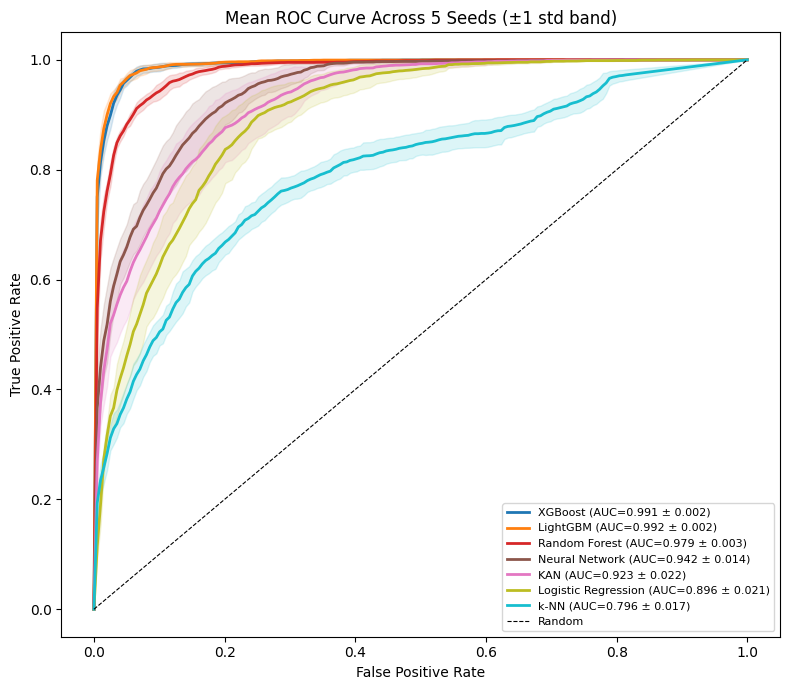

Saved: roc_multiseed_mean.png


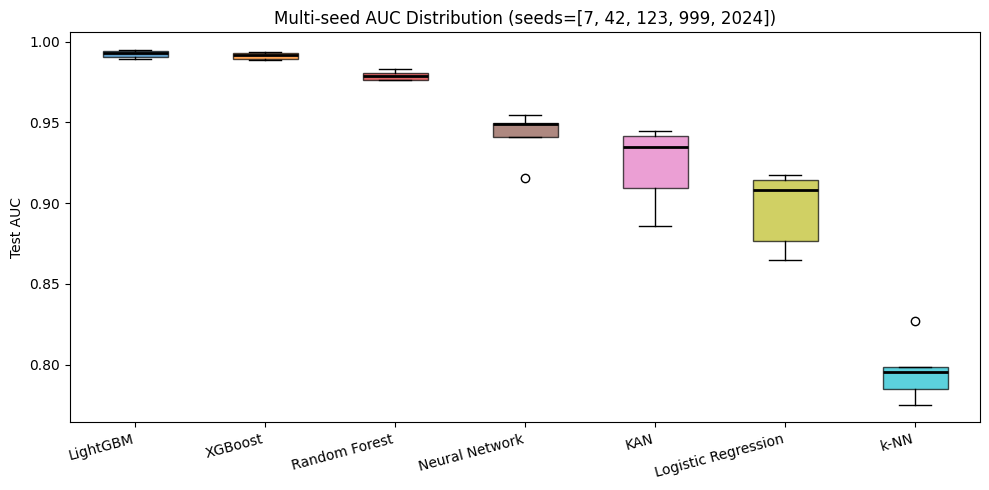

Saved: multiseed_auc_boxplot.png


In [ ]:
# ================================================================
# MULTI-SEED ROC/AUC CURVE
# ================================================================
mean_fpr = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(8, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(model_names_list)))

for m, color in zip(model_names_list, colors):
    tprs, aucs = [], []
    for fpr, tpr, auc_val in roc_curves_all_seeds[m]:
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(auc_val)
    tprs = np.array(tprs)
    mean_tpr = tprs.mean(axis=0); mean_tpr[-1] = 1.0
    std_tpr  = tprs.std(axis=0)
    mean_auc, std_auc = np.mean(aucs), np.std(aucs)

    ax.plot(mean_fpr, mean_tpr, color=color, lw=2,
            label=f"{m} (AUC={mean_auc:.3f} ± {std_auc:.3f})")
    ax.fill_between(mean_fpr, np.clip(mean_tpr - std_tpr, 0, 1),
                     np.clip(mean_tpr + std_tpr, 0, 1), color=color, alpha=0.15)

ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random')
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title(f"Mean ROC Curve Across {len(SEEDS)} Seeds (±1 std band)")
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.savefig("roc_multiseed_mean.png", dpi=150); plt.show()
print("Saved: roc_multiseed_mean.png")

ranked_models = multiseed_summary_df['Model'].tolist()
fig, ax = plt.subplots(figsize=(10, 5))
auc_data = [auc_scores[m] for m in ranked_models]
bp = ax.boxplot(auc_data, patch_artist=True, notch=False, medianprops=dict(color='black', lw=2))
bp_colors = plt.cm.tab10(np.linspace(0, 1, len(ranked_models)))
for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticks(range(1, len(ranked_models) + 1))
ax.set_xticklabels(ranked_models, rotation=15, ha='right')
ax.set_ylabel("Test AUC")
ax.set_title(f"Multi-seed AUC Distribution (seeds={SEEDS})")
plt.tight_layout(); plt.savefig("multiseed_auc_boxplot.png", dpi=150); plt.show()
print("Saved: multiseed_auc_boxplot.png")

In [ ]:
# ================================================================
# WILCOXON SIGN TEST — SEED LEVEL: XGBoost vs LightGBM, by OOF AUC
# ================================================================
print(f"\n{'='*80}")
print("XGBoost vs LightGBM — Sign Test on OOF AUC (seed level)")
print(f"{'='*80}")

seed_auc_win_counts = {'XGBoost': 0, 'LightGBM': 0, 'Tie': 0}
seed_auc_rows = []

for seed in SEEDS:
    bundle = trained_models_by_seed[seed]
    y_tr        = bundle['y_train']
    oof_xgb     = bundle['xgb_oof_prob']
    oof_lgb     = bundle['lgb_oof_prob']

    auc_xgb = roc_auc_score(y_tr, oof_xgb) if len(np.unique(y_tr)) >= 2 else np.nan
    auc_lgb = roc_auc_score(y_tr, oof_lgb) if len(np.unique(y_tr)) >= 2 else np.nan

    if np.isfinite(auc_xgb) and np.isfinite(auc_lgb):
        if auc_xgb > auc_lgb:
            winner = 'XGBoost'
        elif auc_lgb > auc_xgb:
            winner = 'LightGBM'
        else:
            winner = 'Tie'
        seed_auc_win_counts[winner] += 1
    else:
        winner = 'N/A (one class only)'

    print(f"  Seed {seed}: XGB OOF AUC={auc_xgb:.4f}  LGB OOF AUC={auc_lgb:.4f}  "
          f"-> winner={winner}")

    seed_auc_rows.append({
        'Seed': seed, 'XGB OOF AUC': auc_xgb, 'LGB OOF AUC': auc_lgb, 'Winner': winner
    })

decisive_seeds = seed_auc_win_counts['XGBoost'] + seed_auc_win_counts['LightGBM']
print(f"\nSeed win counts (by OOF AUC): XGBoost={seed_auc_win_counts['XGBoost']}  "
      f"LightGBM={seed_auc_win_counts['LightGBM']}  Tie={seed_auc_win_counts['Tie']}  "
      f"(out of {len(SEEDS)} seeds)")

if decisive_seeds > 0:
    sign_result_seed = binomtest(
        max(seed_auc_win_counts['XGBoost'], seed_auc_win_counts['LightGBM']),
        n=decisive_seeds, p=0.5, alternative='two-sided'
    )
    leader_seed = 'XGBoost' if seed_auc_win_counts['XGBoost'] >= seed_auc_win_counts['LightGBM'] else 'LightGBM'
    print(f"  {leader_seed} won {max(seed_auc_win_counts['XGBoost'], seed_auc_win_counts['LightGBM'])}/"
          f"{decisive_seeds} decisive seeds -> p={sign_result_seed.pvalue:.4g}  "
          f"{'sig (p<0.05)' if sign_result_seed.pvalue < 0.05 else 'not sig'}")
else:
    sign_result_seed = None
    print("  Sign test skipped — no decisive (non-tied) seeds.")

seed_auc_df = pd.DataFrame(seed_auc_rows)
seed_auc_df.to_csv("sign_test_xgb_vs_lgb_seed_level.csv", index=False)
print("\nSaved: sign_test_xgb_vs_lgb_seed_level.csv")


XGBoost vs LightGBM — Sign Test on OOF AUC (seed level)
  Seed 7: XGB OOF AUC=0.9913  LGB OOF AUC=0.9929  -> winner=LightGBM
  Seed 42: XGB OOF AUC=0.9902  LGB OOF AUC=0.9918  -> winner=LightGBM
  Seed 123: XGB OOF AUC=0.9903  LGB OOF AUC=0.9916  -> winner=LightGBM
  Seed 999: XGB OOF AUC=0.9920  LGB OOF AUC=0.9930  -> winner=LightGBM
  Seed 2024: XGB OOF AUC=0.9909  LGB OOF AUC=0.9931  -> winner=LightGBM

Seed win counts (by OOF AUC): XGBoost=0  LightGBM=5  Tie=0  (out of 5 seeds)
  LightGBM won 5/5 decisive seeds -> p=0.0625  not sig

Saved: sign_test_xgb_vs_lgb_seed_level.csv


In [ ]:
# ================================================================
# ABLATION STUDY SETUP
# ================================================================

X_train_fa    = X_train_final
y_train_a     = y_train
X_test_fa     = X_test_final
y_test_a      = y_test

X_train_df_a  = X_train_df
X_test_df_a   = X_test_df

scale_pos_a   = scale_pos
groups_train_a = groups_train

sgkf_abl = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=ablation_seed)

grid_train_a = df.loc[X_train.index, 'grid_size'].reset_index(drop=True)
pde_train_a  = df.loc[X_train.index, 'pde_type'].reset_index(drop=True)

print(f"Ablation study will run using seed={ablation_seed} "
      f"(last seed in {SEEDS}), Boruta features={len(final_features)}")

Ablation study will run using seed=2024 (last seed in [7, 42, 123, 999, 2024]), Boruta features=36



ABLATION STUDY (XGBoost + LightGBM)

Feature groups identified:
  Diagonal       :   8 features — ['diag_min', 'diag_max', 'diag_mean', 'diag_std']...
  Norm           :   3 features — ['matrix_1norm', 'matrix_infnorm', 'norm_ratio_1_inf']
  Symmetry       :   1 features — ['symmetry_measure']
  Sparsity       :   4 features — ['avg_nnz_row', 'max_row_nnz', 'nnz_std', 'sparsity_entropy']
  Bandwidth      :   2 features — ['bandwidth', 'bandwidth_ratio']
  Spectral       :   3 features — ['gersh_radius_max', 'gersh_radius_mean', 'gersh_radius_std']
  Other          :  15 features — ['gersh_origin_overlap_pct', 'gersh_min_gap', 'row_sum_min', 'row_sum_max']...

Baseline AUC (XGBoost, 36 features): 0.9891

Baseline AUC (LightGBM, 36 features): 0.9904

────────────────────────────────────────────────────────────
ABLATION 1 — Feature Group Removal (XGBoost + LightGBM)
────────────────────────────────────────────────────────────
  [XGBoost] Remove Diagonal        ( 8 feats removed) -> AUC=0

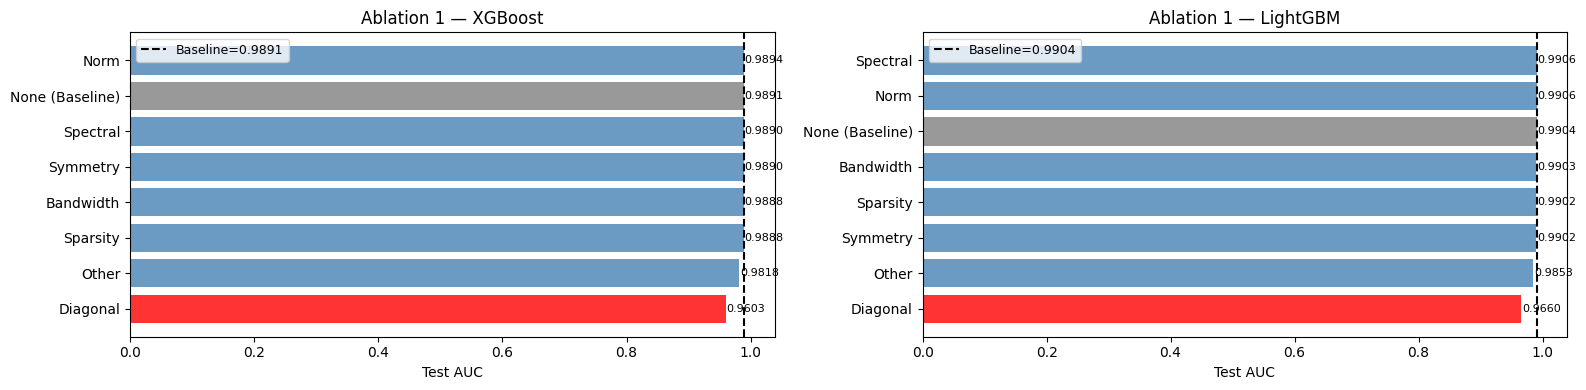

Saved: ablation_feature_groups.png

────────────────────────────────────────────────────────────
ABLATION 2 — Leave-One-Feature-Out (XGBoost + LightGBM)
────────────────────────────────────────────────────────────

[XGBoost] Top 15 most important features (by AUC drop when removed):
  Model          Feature  Test AUC  AUC Drop
XGBoost      gmres_decay    0.9868    0.0023
XGBoost       diag_ratio    0.9887    0.0004
XGBoost symmetry_measure    0.9890    0.0001
XGBoost          dom_q90    0.9892   -0.0001
XGBoost          dom_q50    0.9893   -0.0002
XGBoost      row_sum_max    0.9894   -0.0003
XGBoost  bandwidth_ratio    0.9894   -0.0003
XGBoost         diag_min    0.9894   -0.0003
XGBoost    rayleigh_eig0    0.9895   -0.0003
XGBoost          dom_q10    0.9895   -0.0004
XGBoost      row_sum_std    0.9895   -0.0004
XGBoost         diag_max    0.9896   -0.0005
XGBoost    rayleigh_eig1    0.9896   -0.0005
XGBoost         diag_std    0.9896   -0.0005
XGBoost   matrix_infnorm    0.9896   -0.0

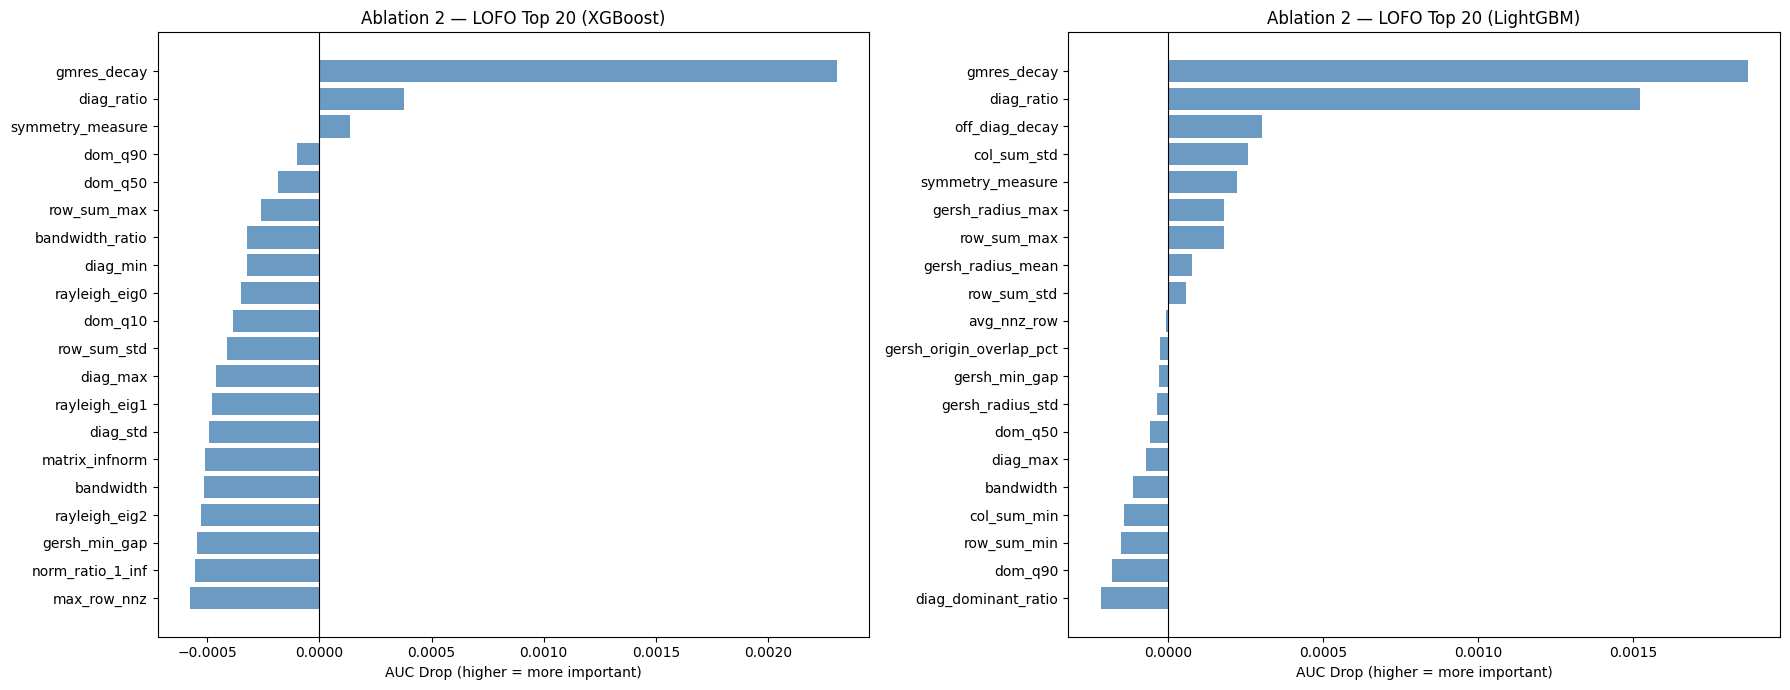

Saved: ablation_lofo.png

────────────────────────────────────────────────────────────
ABLATION 3 — Model Component Ablation (XGBoost + LightGBM)
────────────────────────────────────────────────────────────

  [XGBoost] Full pipeline            AUC=0.9891
  [XGBoost] Without Boruta           AUC=0.9891  Drop=+0.0000  (used 36 features vs 36)
  [XGBoost] Without class balancing  AUC=0.9884  Drop=+0.0007
  [XGBoost] Threshold=0.5 vs Robust  F1=0.9390 vs F1=0.9384  (AUC unchanged=0.9891, robust thresh=0.5266)
  [XGBoost] Without Optuna tuning    AUC=0.9893  Drop=-0.0001

  [LightGBM] Full pipeline            AUC=0.9904
  [LightGBM] Without Boruta           AUC=0.9904  Drop=+0.0000  (used 36 features vs 36)
  [LightGBM] Without class balancing  AUC=0.9908  Drop=-0.0004
  [LightGBM] Threshold=0.5 vs Robust  F1=0.9438 vs F1=0.9422  (AUC unchanged=0.9904, robust thresh=0.4451)
  [LightGBM] Without Optuna tuning    AUC=0.9896  Drop=+0.0008

Ablation 3 Summary:
   Model                         

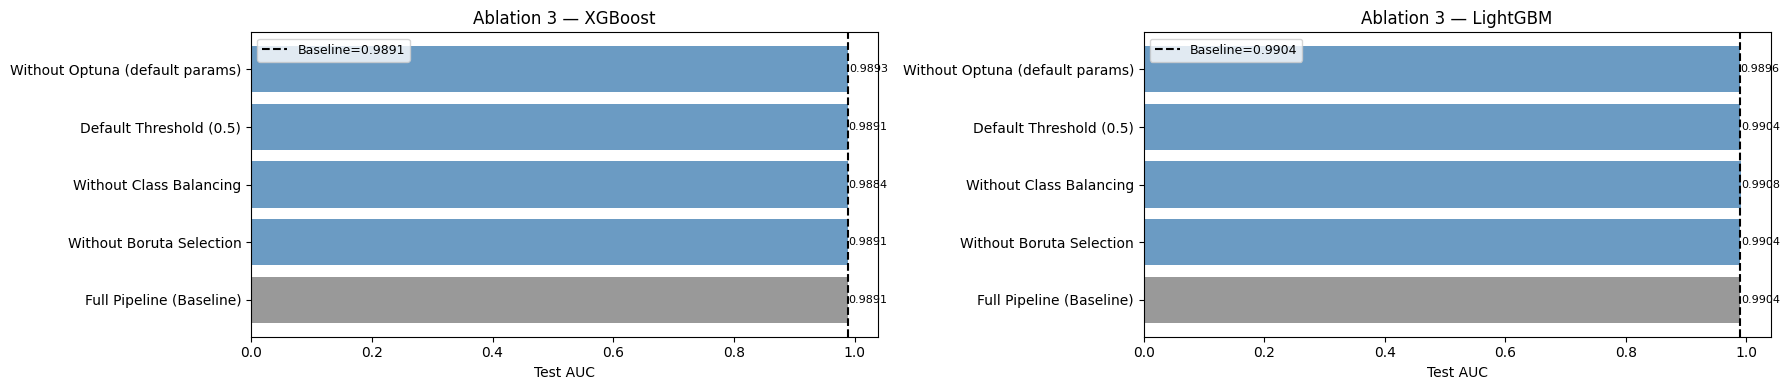

Saved: ablation_components.png

────────────────────────────────────────────────────────────
ABLATION 4 — Training Size Ablation (XGBoost + LightGBM)
────────────────────────────────────────────────────────────
  Ablation training set spans 14 distinct groups (6026 rows total)
  [XGBoost] Fraction=0.10  Groups used=1/14  N=  410  AUC=0.6971
  [XGBoost] Fraction=0.20  Groups used=3/14  N= 1316  AUC=0.8612
  [XGBoost] Fraction=0.30  Groups used=4/14  N= 1752  AUC=0.8985
  [XGBoost] Fraction=0.50  Groups used=7/14  N= 2967  AUC=0.9742
  [XGBoost] Fraction=0.70  Groups used=10/14  N= 4317  AUC=0.9703
  [XGBoost] Fraction=0.85  Groups used=12/14  N= 5163  AUC=0.9845
  [XGBoost] Fraction=1.00  Groups used=14/14  N= 6026  AUC=0.9891
  [LightGBM] Fraction=0.10  Groups used=1/14  N=  415  AUC=0.8296
  [LightGBM] Fraction=0.20  Groups used=3/14  N= 1284  AUC=0.8926
  [LightGBM] Fraction=0.30  Groups used=4/14  N= 1699  AUC=0.9082
  [LightGBM] Fraction=0.50  Groups used=7/14  N= 2975  AUC=0.9812


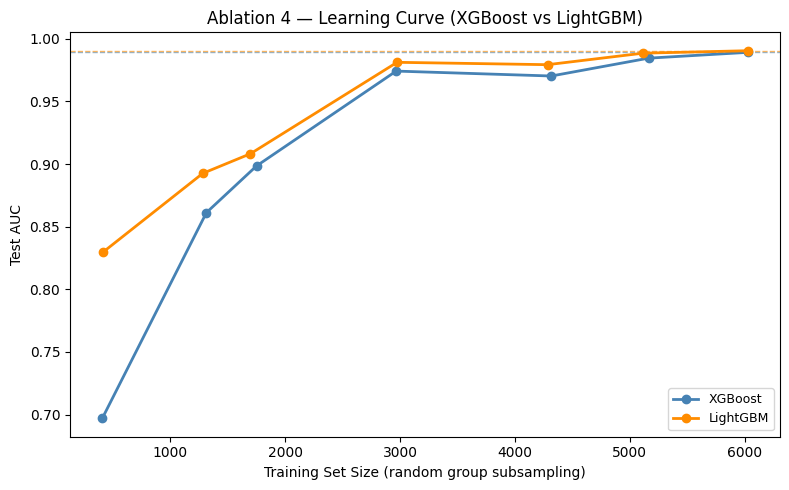

Saved: ablation_train_size.png

ABLATION STUDY COMPLETE (XGBoost + LightGBM)
Files saved:
  ablation_feature_groups.csv / .png
  ablation_lofo.csv / .png
  ablation_components.csv / .png
  ablation_train_size.csv / .png


In [ ]:
# ================================================================
# ABLATION STUDY — XGBoost AND LightGBM
# ================================================================
print(f"\n{'='*70}")
print("ABLATION STUDY (XGBoost + LightGBM)")
print(f"{'='*70}")

def run_model_auc(model_type, X_tr, y_tr, X_te, y_te, sp, seed_local):
    if model_type == 'xgb':
        m = xgb.XGBClassifier(
            **best_xgb_clf_params, scale_pos_weight=sp,
            eval_metric='logloss', random_state=seed_local, n_jobs=-1, verbosity=0
        )
    elif model_type == 'lgb':
        m = lgb.LGBMClassifier(
            **best_lgb_clf_params, class_weight='balanced',
            random_state=seed_local, n_jobs=-1, verbose=-1
        )
    else:
        raise ValueError(f"Unknown model_type: {model_type}")
    m.fit(X_tr, y_tr)
    prob = m.predict_proba(X_te)[:, 1]
    return roc_auc_score(y_te, prob)

ABLATION_MODELS = ['xgb', 'lgb']
ABLATION_MODEL_NAMES = {'xgb': 'XGBoost', 'lgb': 'LightGBM'}

feature_groups = {}
for f in final_features:
    f_lower = f.lower()
    if any(k in f_lower for k in ['spectral', 'eigen', 'radius']):
        feature_groups.setdefault('Spectral', []).append(f)
    elif any(k in f_lower for k in ['diag', 'diagonal', 'pivot']):
        feature_groups.setdefault('Diagonal', []).append(f)
    elif any(k in f_lower for k in ['norm', 'fro']):
        feature_groups.setdefault('Norm', []).append(f)
    elif any(k in f_lower for k in ['spars', 'nnz', 'density']):
        feature_groups.setdefault('Sparsity', []).append(f)
    elif any(k in f_lower for k in ['band', 'width']):
        feature_groups.setdefault('Bandwidth', []).append(f)
    elif any(k in f_lower for k in ['symm', 'skew']):
        feature_groups.setdefault('Symmetry', []).append(f)
    else:
        feature_groups.setdefault('Other', []).append(f)

print("\nFeature groups identified:")
for grp, feats in feature_groups.items():
    print(f"  {grp:<15}: {len(feats):>3} features — {feats[:4]}{'...' if len(feats)>4 else ''}")

baseline_auc = {}
for model_type in ABLATION_MODELS:
    baseline_auc[model_type] = run_model_auc(
        model_type, X_train_fa, y_train_a, X_test_fa, y_test_a, scale_pos_a, ablation_seed
    )
    print(f"\nBaseline AUC ({ABLATION_MODEL_NAMES[model_type]}, "
          f"{len(final_features)} features): {baseline_auc[model_type]:.4f}")

# ================================================================
# ABLATION 1 — FEATURE GROUP REMOVAL (both models)
# ================================================================
print(f"\n{'─'*60}")
print("ABLATION 1 — Feature Group Removal (XGBoost + LightGBM)")
print(f"{'─'*60}")

ablation1_rows = []
for model_type in ABLATION_MODELS:
    mname = ABLATION_MODEL_NAMES[model_type]
    ablation1_rows.append({
        'Model': mname, 'Removed Group': 'None (Baseline)',
        'Features Removed': 0, 'Features Remaining': len(final_features),
        'Test AUC': baseline_auc[model_type], 'AUC Drop': 0.0
    })
    for grp, grp_feats in feature_groups.items():
        remaining = [f for f in final_features if f not in grp_feats]
        if len(remaining) == 0:
            print(f"  [{mname}] Skipping {grp} — would remove all features")
            continue
        auc = run_model_auc(
            model_type, X_train_fa[remaining], y_train_a,
            X_test_fa[remaining], y_test_a, scale_pos_a, ablation_seed
        )
        drop = baseline_auc[model_type] - auc
        print(f"  [{mname}] Remove {grp:<15} ({len(grp_feats):>2} feats removed) -> "
              f"AUC={auc:.4f}  Drop={drop:+.4f}")
        ablation1_rows.append({
            'Model': mname, 'Removed Group': grp,
            'Features Removed': len(grp_feats), 'Features Remaining': len(remaining),
            'Test AUC': auc, 'AUC Drop': drop
        })

ablation1_df = pd.DataFrame(ablation1_rows).sort_values(['Model', 'AUC Drop'], ascending=[True, False])
ablation1_df.to_csv("ablation_feature_groups.csv", index=False)
print("\nAblation 1 Summary:")
print(ablation1_df.to_string(index=False, float_format='{:.4f}'.format))
print("Saved: ablation_feature_groups.csv")

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=False)
for ax, model_type in zip(axes, ABLATION_MODELS):
    mname = ABLATION_MODEL_NAMES[model_type]
    sub = ablation1_df[ablation1_df['Model'] == mname]
    colors_abl = ['grey' if r == 'None (Baseline)' else
                  ('red' if d > 0.01 else 'steelblue')
                  for r, d in zip(sub['Removed Group'], sub['AUC Drop'])]
    bars = ax.barh(sub['Removed Group'], sub['Test AUC'], color=colors_abl, alpha=0.8)
    ax.axvline(baseline_auc[model_type], color='black', linestyle='--', lw=1.5,
               label=f'Baseline={baseline_auc[model_type]:.4f}')
    ax.set_xlabel("Test AUC")
    ax.set_title(f"Ablation 1 — {mname}")
    ax.legend(fontsize=9)
    for bar, val in zip(bars, sub['Test AUC']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("ablation_feature_groups.png", dpi=150)
plt.show()
print("Saved: ablation_feature_groups.png")

# ================================================================
# ABLATION 2 — LEAVE-ONE-FEATURE-OUT (both models)
# ================================================================
print(f"\n{'─'*60}")
print("ABLATION 2 — Leave-One-Feature-Out (XGBoost + LightGBM)")
print(f"{'─'*60}")

lofo_rows = []
for model_type in ABLATION_MODELS:
    mname = ABLATION_MODEL_NAMES[model_type]
    for feat in final_features:
        remaining = [f for f in final_features if f != feat]
        auc = run_model_auc(
            model_type, X_train_fa[remaining], y_train_a,
            X_test_fa[remaining], y_test_a, scale_pos_a, ablation_seed
        )
        drop = baseline_auc[model_type] - auc
        lofo_rows.append({'Model': mname, 'Feature': feat, 'Test AUC': auc, 'AUC Drop': drop})

lofo_df = pd.DataFrame(lofo_rows).sort_values(['Model', 'AUC Drop'], ascending=[True, False]).reset_index(drop=True)
lofo_df.to_csv("ablation_lofo.csv", index=False)

for model_type in ABLATION_MODELS:
    mname = ABLATION_MODEL_NAMES[model_type]
    sub = lofo_df[lofo_df['Model'] == mname]
    print(f"\n[{mname}] Top 15 most important features (by AUC drop when removed):")
    print(sub.head(15).to_string(index=False, float_format='{:.4f}'.format))
print("Saved: ablation_lofo.csv")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, model_type in zip(axes, ABLATION_MODELS):
    mname = ABLATION_MODEL_NAMES[model_type]
    top20 = lofo_df[lofo_df['Model'] == mname].head(20)
    colors_lofo = ['red' if d > 0.005 else 'steelblue' for d in top20['AUC Drop']]
    ax.barh(top20['Feature'][::-1], top20['AUC Drop'][::-1], color=colors_lofo[::-1], alpha=0.8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel("AUC Drop (higher = more important)")
    ax.set_title(f"Ablation 2 — LOFO Top 20 ({mname})")
plt.tight_layout()
plt.savefig("ablation_lofo.png", dpi=150)
plt.show()
print("Saved: ablation_lofo.png")

# ================================================================
# ABLATION 3 — MODEL COMPONENT ABLATION (both models)
# ================================================================
print(f"\n{'─'*60}")
print("ABLATION 3 — Model Component Ablation (XGBoost + LightGBM)")
print(f"{'─'*60}")

all_features = X_train_df_a.columns.tolist()
ablation3_rows = []

for model_type in ABLATION_MODELS:
    mname = ABLATION_MODEL_NAMES[model_type]
    auc_full = baseline_auc[model_type]
    ablation3_rows.append({'Model': mname, 'Config': 'Full Pipeline (Baseline)',
                            'Test AUC': auc_full, 'Note': ''})
    print(f"\n  [{mname}] Full pipeline            AUC={auc_full:.4f}")

    # Without Boruta selection
    if model_type == 'xgb':
        m_no_boruta = xgb.XGBClassifier(
            **best_xgb_clf_params, scale_pos_weight=scale_pos_a,
            eval_metric='logloss', random_state=ablation_seed, n_jobs=-1, verbosity=0
        )
    else:
        m_no_boruta = lgb.LGBMClassifier(
            **best_lgb_clf_params, class_weight='balanced',
            random_state=ablation_seed, n_jobs=-1, verbose=-1
        )
    m_no_boruta.fit(X_train_df_a[all_features], y_train_a)
    prob_nb = m_no_boruta.predict_proba(X_test_df_a[all_features])[:, 1]
    auc_nb = roc_auc_score(y_test_a, prob_nb)
    drop_nb = auc_full - auc_nb
    ablation3_rows.append({'Model': mname, 'Config': 'Without Boruta Selection',
                            'Test AUC': auc_nb, 'Note': f'All {len(all_features)} features'})
    print(f"  [{mname}] Without Boruta           AUC={auc_nb:.4f}  Drop={drop_nb:+.4f}  "
          f"(used {len(all_features)} features vs {len(final_features)})")

    # Without class balancing
    if model_type == 'xgb':
        m_no_bal = xgb.XGBClassifier(
            **best_xgb_clf_params, scale_pos_weight=1.0,
            eval_metric='logloss', random_state=ablation_seed, n_jobs=-1, verbosity=0
        )
    else:
        m_no_bal = lgb.LGBMClassifier(
            **best_lgb_clf_params, class_weight=None,
            random_state=ablation_seed, n_jobs=-1, verbose=-1
        )
    m_no_bal.fit(X_train_fa, y_train_a)
    prob_nbal = m_no_bal.predict_proba(X_test_fa)[:, 1]
    auc_nbal = roc_auc_score(y_test_a, prob_nbal)
    drop_nbal = auc_full - auc_nbal
    ablation3_rows.append({'Model': mname, 'Config': 'Without Class Balancing',
                            'Test AUC': auc_nbal,
                            'Note': 'scale_pos_weight=1' if model_type == 'xgb' else 'class_weight=None'})
    print(f"  [{mname}] Without class balancing  AUC={auc_nbal:.4f}  Drop={drop_nbal:+.4f}")

    # Threshold sensitivity (0.5 vs robust threshold)
    if model_type == 'xgb':
        m_baseline = xgb.XGBClassifier(
            **best_xgb_clf_params, scale_pos_weight=scale_pos_a,
            eval_metric='logloss', random_state=ablation_seed, n_jobs=-1, verbosity=0
        )
    else:
        m_baseline = lgb.LGBMClassifier(
            **best_lgb_clf_params, class_weight='balanced',
            random_state=ablation_seed, n_jobs=-1, verbose=-1
        )
    oof_prob_abl = cross_val_predict(m_baseline, X_train_fa, y_train_a, groups=groups_train_a,
                                      cv=sgkf_abl, method='predict_proba', n_jobs=-1)[:, 1]
    youden_thresh_abl = best_threshold_youden(y_train_a, oof_prob_abl)
    m_baseline.fit(X_train_fa, y_train_a)
    prob_full = m_baseline.predict_proba(X_test_fa)[:, 1]
    pred_05 = (prob_full >= 0.5).astype(int)
    pred_youden = (prob_full >= youden_thresh_abl).astype(int)
    f1_05 = f1_score(y_test_a, pred_05, zero_division=0)
    f1_youden = f1_score(y_test_a, pred_youden, zero_division=0)
    auc_same = roc_auc_score(y_test_a, prob_full)
    print(f"  [{mname}] Threshold=0.5 vs Robust  F1={f1_05:.4f} vs F1={f1_youden:.4f}  "
          f"(AUC unchanged={auc_same:.4f}, robust thresh={youden_thresh_abl:.4f})")
    ablation3_rows.append({'Model': mname, 'Config': 'Default Threshold (0.5)',
                            'Test AUC': auc_same,
                            'Note': f'F1={f1_05:.4f} vs Robust-threshold F1={f1_youden:.4f}'})

    # Without Optuna tuning (default hyperparameters)
    if model_type == 'xgb':
        m_default = xgb.XGBClassifier(
            n_estimators=100, scale_pos_weight=scale_pos_a,
            eval_metric='logloss', random_state=ablation_seed, n_jobs=-1, verbosity=0
        )
    else:
        m_default = lgb.LGBMClassifier(
            n_estimators=100, class_weight='balanced',
            random_state=ablation_seed, n_jobs=-1, verbose=-1
        )
    m_default.fit(X_train_fa, y_train_a)
    prob_def = m_default.predict_proba(X_test_fa)[:, 1]
    auc_def = roc_auc_score(y_test_a, prob_def)
    drop_def = auc_full - auc_def
    ablation3_rows.append({'Model': mname, 'Config': 'Without Optuna (default params)',
                            'Test AUC': auc_def, 'Note': 'n_estimators=100, all defaults'})
    print(f"  [{mname}] Without Optuna tuning    AUC={auc_def:.4f}  Drop={drop_def:+.4f}")

ablation3_df = pd.DataFrame(ablation3_rows)
ablation3_df.to_csv("ablation_components.csv", index=False)
print("\nAblation 3 Summary:")
print(ablation3_df.to_string(index=False, float_format='{:.4f}'.format))
print("Saved: ablation_components.csv")

fig, axes = plt.subplots(1, 2, figsize=(18, 4))
for ax, model_type in zip(axes, ABLATION_MODELS):
    mname = ABLATION_MODEL_NAMES[model_type]
    sub = ablation3_df[ablation3_df['Model'] == mname]
    bar_colors = ['grey' if 'Baseline' in c else 'steelblue' for c in sub['Config']]
    bars = ax.barh(sub['Config'], sub['Test AUC'], color=bar_colors, alpha=0.8)
    ax.axvline(baseline_auc[model_type], color='black', linestyle='--', lw=1.5,
               label=f'Baseline={baseline_auc[model_type]:.4f}')
    ax.set_xlabel("Test AUC")
    ax.set_title(f"Ablation 3 — {mname}")
    ax.legend(fontsize=9)
    for bar, val in zip(bars, sub['Test AUC']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("ablation_components.png", dpi=150)
plt.show()
print("Saved: ablation_components.png")

# ================================================================
# ABLATION 4 — TRAINING SIZE ABLATION (both models)
# ================================================================
print(f"\n{'─'*60}")
print("ABLATION 4 — Training Size Ablation (XGBoost + LightGBM)")
print(f"{'─'*60}")

group_series = pde_train_a

unique_groups_a = group_series.unique()
n_total_groups = len(unique_groups_a)
print(f"  Ablation training set spans {n_total_groups} distinct groups "
      f"({len(X_train_fa)} rows total)")

fractions = [0.1, 0.2, 0.3, 0.5, 0.7, 0.85, 1.0]
size_rows = []
rng_size = np.random.RandomState(ablation_seed)

for model_type in ABLATION_MODELS:
    mname = ABLATION_MODEL_NAMES[model_type]
    for frac in fractions:
        if frac >= 1.0:
            chosen_groups = unique_groups_a
            sub_idx = np.arange(len(X_train_fa))
        else:
            n_groups_wanted = max(1, int(round(frac * n_total_groups)))
            chosen_groups = rng_size.choice(unique_groups_a, size=n_groups_wanted, replace=False)
            sub_mask = group_series.isin(chosen_groups).values
            sub_idx = np.where(sub_mask)[0]

        X_tr_sub = X_train_fa.iloc[sub_idx]
        y_tr_sub = y_train_a.iloc[sub_idx]

        if y_tr_sub.nunique() < 2:
            print(f"  [{mname}] Fraction={frac:.2f}  skipped (only one class present)")
            continue

        sp_sub = (y_tr_sub == 0).sum() / max((y_tr_sub == 1).sum(), 1)
        auc_sub = run_model_auc(model_type, X_tr_sub, y_tr_sub, X_test_fa, y_test_a, sp_sub, ablation_seed)
        n_used = len(X_tr_sub)
        print(f"  [{mname}] Fraction={frac:.2f}  Groups used={len(chosen_groups)}/{n_total_groups}  "
              f"N={n_used:>5}  AUC={auc_sub:.4f}")
        size_rows.append({'Model': mname, 'Train Fraction': frac,
                           'Groups Used': len(chosen_groups), 'Total Groups': n_total_groups,
                           'Train Size': n_used, 'Test AUC': auc_sub})

size_df = pd.DataFrame(size_rows)
size_df.to_csv("ablation_train_size.csv", index=False)
print("Saved: ablation_train_size.csv")

fig, ax = plt.subplots(figsize=(8, 5))
for model_type, color in zip(ABLATION_MODELS, ['steelblue', 'darkorange']):
    mname = ABLATION_MODEL_NAMES[model_type]
    sub = size_df[size_df['Model'] == mname]
    ax.plot(sub['Train Size'], sub['Test AUC'], marker='o', color=color, lw=2, label=mname)
    ax.axhline(baseline_auc[model_type], color=color, linestyle='--', lw=1, alpha=0.6)
ax.set_xlabel("Training Set Size (random group subsampling)")
ax.set_ylabel("Test AUC")
ax.set_title("Ablation 4 — Learning Curve (XGBoost vs LightGBM)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("ablation_train_size.png", dpi=150)
plt.show()
print("Saved: ablation_train_size.png")

print(f"\n{'='*70}")
print("ABLATION STUDY COMPLETE (XGBoost + LightGBM)")
print("Files saved:")
print("  ablation_feature_groups.csv / .png")
print("  ablation_lofo.csv / .png")
print("  ablation_components.csv / .png")
print("  ablation_train_size.csv / .png")
print(f"{'='*70}")

In [ ]:
# ================================================================
# EXTERNAL VALIDATION
# ================================================================
import shutil
shutil.rmtree("./suitesparse_cache_gridsize", ignore_errors=True)
from scipy.sparse.linalg import splu, gmres
from scipy.sparse import eye

COND_THRESHOLD_LOG10 = 7.0

SUITESPARSE_MATRICES = []

SUITESPARSE_MATRICES += [
    ("HB", "bcsstk08"), ("HB", "bcsstk09"), ("HB", "bcsstk11"),
    ("HB", "bcsstk18"), ("HB", "bcsstk27"), ("HB", "bcsstm08"),
    ("FIDAP", "ex3"),   ("FIDAP", "ex5"),   ("FIDAP", "ex9"),
    ("FIDAP", "ex10"),  ("FIDAP", "ex13"),  ("FIDAP", "ex15"),
    ("FIDAP", "ex19"),  ("FIDAP", "ex21"),  ("FIDAP", "ex33"),
    ("Nasa", "nasa1824"), ("Nasa", "nasa2146"), ("Nasa", "nasa2910"),
    ("Nasa", "nasa4704"),
    ("Boeing", "msc00726"), ("Boeing", "msc01050"), ("Boeing", "msc04515"),
    ("Boeing", "msc10848"), ("Boeing", "msc23052"),
    ("Botonakis", "thermal1"), ("Botonakis", "thermal2"),
    ("Boeing", "crystm01"), ("Boeing", "crystm02"), ("Boeing", "crystm03"),
]

for i in range(1, 39):
    SUITESPARSE_MATRICES.append(("HB", f"bcsstk{i:02d}"))
for i in range(1, 28):
    SUITESPARSE_MATRICES.append(("HB", f"bcsstm{i:02d}"))

for i in range(1, 41):
    SUITESPARSE_MATRICES.append(("FIDAP", f"ex{i}"))

SUITESPARSE_MATRICES += [
    ("Bai", "dw2048"), ("Bai", "dw4096"), ("Bai", "dw8192"),
    ("Bai", "olm500"), ("Bai", "olm1000"), ("Bai", "olm2000"), ("Bai", "olm5000"),
    ("Bai", "rdb200"), ("Bai", "rdb200l"), ("Bai", "rdb450"), ("Bai", "rdb450l"),
    ("Bai", "rdb968"), ("Bai", "rdb2048"), ("Bai", "rdb2048l"),
    ("Bai", "rdb3200l"), ("Bai", "rdb5000"),
]

SUITESPARSE_MATRICES += [
    ("Pothen", "barth"), ("Pothen", "barth4"), ("Pothen", "barth5"),
    ("Pothen", "bodyy4"), ("Pothen", "bodyy5"), ("Pothen", "bodyy6"),
    ("Pothen", "commanche_dual"),
    ("Pothen", "mesh1e1"), ("Pothen", "mesh1em1"), ("Pothen", "mesh1em6"),
    ("Pothen", "mesh2e1"), ("Pothen", "mesh2em5"),
    ("Pothen", "mesh3e1"), ("Pothen", "mesh3em5"),
    ("Pothen", "onera_dual"), ("Pothen", "shuttle_eddy"),
    ("Pothen", "tandem_dual"), ("Pothen", "tandem_vtx"),
]
SUITESPARSE_MATRICES += [
    ("Simon", "raefsky1"), ("Simon", "raefsky2"), ("Simon", "raefsky3"), ("Simon", "raefsky4"),
    ("Simon", "olafu"),
    ("Simon", "venkat01"), ("Simon", "venkat25"), ("Simon", "venkat50"),
]

SUITESPARSE_MATRICES += [
    ("Grund", "poli"), ("Grund", "poli3"), ("Grund", "poli4"),
    ("Grund", "bayer01"), ("Grund", "bayer02"), ("Grund", "bayer03"), ("Grund", "bayer04"),
    ("Grund", "bayer05"), ("Grund", "bayer06"), ("Grund", "bayer07"), ("Grund", "bayer08"),
    ("Grund", "bayer09"), ("Grund", "bayer10"),
]
SUITESPARSE_MATRICES += [
    ("HB", "1138_bus"), ("HB", "494_bus"), ("HB", "662_bus"), ("HB", "685_bus"),
    ("HB", "bcspwr01"), ("HB", "bcspwr02"), ("HB", "bcspwr03"), ("HB", "bcspwr04"),
    ("HB", "bcspwr05"), ("HB", "bcspwr06"), ("HB", "bcspwr07"), ("HB", "bcspwr08"),
    ("HB", "bcspwr09"), ("HB", "bcspwr10"),
    ("HB", "can_24"), ("HB", "can_61"), ("HB", "can_144"), ("HB", "can_161"),
    ("HB", "can_187"), ("HB", "can_229"), ("HB", "can_256"), ("HB", "can_268"),
    ("HB", "can_292"), ("HB", "can_445"), ("HB", "can_634"), ("HB", "can_715"),
    ("HB", "can_838"), ("HB", "can_1054"), ("HB", "can_1072"),
    ("HB", "arc130"),
    ("HB", "ash85"), ("HB", "ash219"), ("HB", "ash331"), ("HB", "ash608"), ("HB", "ash958"),
    ("HB", "steam1"), ("HB", "steam2"), ("HB", "steam3"),
    ("HB", "saylr1"), ("HB", "saylr3"), ("HB", "saylr4"),
    ("HB", "sherman1"), ("HB", "sherman2"), ("HB", "sherman3"),
    ("HB", "sherman4"), ("HB", "sherman5"),
    ("HB", "west0132"), ("HB", "west0156"), ("HB", "west0167"), ("HB", "west0381"),
    ("HB", "west0479"), ("HB", "west0655"), ("HB", "west0989"), ("HB", "west1505"),
    ("HB", "west2021"),
    ("HB", "gr_30_30"), ("HB", "gre_115"), ("HB", "gre_185"),
    ("HB", "gre_216a"), ("HB", "gre_216b"), ("HB", "gre_343"),
    ("HB", "gre_512"), ("HB", "gre_1107"),
]

_seen = set()
SUITESPARSE_MATRICES = [m for m in SUITESPARSE_MATRICES if not (m in _seen or _seen.add(m))]

print(f"Total SuiteSparse matrices queued for external validation (grid_size split): "
      f"{len(SUITESPARSE_MATRICES)}")

def download_suitesparse_matrix(group, name, out_dir="./suitesparse_cache_gridsize"):
    import os
    matrix_dir = os.path.join(out_dir, f"{group}_{name}")
    os.makedirs(matrix_dir, exist_ok=True)
    try:
        results = ssgetpy.search(name=name, group=group)
        if len(results) == 0:
            print(f"  ⚠️  {group}/{name}: not found in SuiteSparse index — skipping")
            return None
        mat = results[0]
        mat.download(destpath=matrix_dir, extract=True)

        candidates = []
        for root, _, files in os.walk(matrix_dir):
            for f in files:
                if f.lower().endswith(".mtx"):
                    candidates.append(os.path.join(root, f))

        if not candidates:
            print(f"  ⚠️  {group}/{name}: no .mtx file found after extraction — skipping")
            return None
        candidates.sort(key=lambda p: (
            0 if os.path.basename(p).lower().startswith(name.lower()) else 1,
            -os.path.getsize(p)
        ))

        A = None
        for path in candidates:
            try:
                cand = mmread(path)
                cand = csr_matrix(cand, dtype=np.float64)
                if cand.shape[0] == cand.shape[1] and cand.shape[0] > 1:
                    A = cand
                    break
                else:
                    print(f"  ℹ️  {group}/{name}: skipped non-square candidate "
                          f"{os.path.basename(path)} shape={cand.shape}")
            except Exception:
                continue

        if A is None:
            print(f"  ⚠️  {group}/{name}: no square matrix found among "
                  f"{len(candidates)} .mtx candidate(s) — skipping")
            return None
        return A
    except Exception as e:
        print(f"  ⚠️  {group}/{name}: download/parse failed ({e}) — skipping")
        return None


def bandwidth_estimate(A):
    rows, cols = A.nonzero()
    return float(np.max(np.abs(rows - cols))) if len(rows) > 0 else 0.0

def sparsity_entropy(A):
    nnz_per_row = A.getnnz(axis=1)
    p = nnz_per_row.astype(float) / (nnz_per_row.sum() + 1e-12)
    p = p[p > 0]
    return -np.sum(p * np.log2(p + 1e-12)) if len(p) > 0 else 0.0

def off_diag_decay(A, rng, n_samples=100):
    N = A.shape[0]
    indptr, indices, data = A.indptr, A.indices, A.data
    rates = []
    n_draw = min(n_samples, N)
    idxs = rng.integers(0, N, size=n_draw)
    for i in idxs:
        start, end = indptr[i], indptr[i + 1]
        nnz = end - start
        if nnz > 3:
            row_idx = indices[start:end]
            row_val = data[start:end]
            dists = np.abs(row_idx - i)
            vals = np.abs(row_val)
            sorted_idx = dists.argsort()
            rates.append(np.mean(vals[sorted_idx][1:5]) /
                         (vals[sorted_idx[0]] + 1e-12))
    raw = np.mean(rates) if rates else 1.0
    return float(np.log1p(raw))

def gershgorin_features(diag, row_abs_sums):
    radii = row_abs_sums - np.abs(diag)
    return {
        "gersh_radius_max": float(radii.max()),
        "gersh_radius_mean": float(radii.mean()),
        "gersh_radius_std": float(radii.std()),
        "gersh_origin_overlap_pct": float(np.mean(radii >= np.abs(diag))),
        "gersh_min_gap": float(np.min(np.abs(diag) - radii)),
    }

def spectral_features(A, rng, diag, row_abs_sums, k=3):
    N = A.shape[0]
    result = {}
    try:
        Q = rng.standard_normal((N, k + 1))
        Q, _ = np.linalg.qr(Q)
        M_small = Q.T @ (A.T @ (A @ Q))
        eigs = np.sort(np.abs(np.linalg.eigvalsh(M_small)))[::-1]
        for i, e in enumerate(eigs[:k]):
            result[f"rayleigh_eig{i}"] = float(e)
    except Exception:
        for i in range(k):
            result[f"rayleigh_eig{i}"] = 0.0
    try:
        diag_abs = np.abs(diag)
        row_offdiag = row_abs_sums - diag_abs
        dominance = diag_abs - row_offdiag
        result["dom_q10"] = float(np.percentile(dominance, 10))
        result["dom_q50"] = float(np.percentile(dominance, 50))
        result["dom_q90"] = float(np.percentile(dominance, 90))
    except Exception:
        result["dom_q10"] = result["dom_q50"] = result["dom_q90"] = 0.0
    return result

def row_col_statistics(A, diag, row_abs_sums):
    row_sums = np.array(A.sum(axis=1)).flatten()
    col_sums = np.array(A.sum(axis=0)).flatten()
    off_diag_max = row_abs_sums - np.abs(diag)
    return {
        "row_sum_min": float(row_sums.min()),
        "row_sum_max": float(row_sums.max()),
        "row_sum_std": float(row_sums.std()),
        "col_sum_min": float(col_sums.min()),
        "col_sum_max": float(col_sums.max()),
        "col_sum_std": float(col_sums.std()),
        "avg_diag_dominance": float(np.mean(np.abs(diag) - off_diag_max)),
        "diag_dominant_ratio": float(np.mean(np.abs(diag) > off_diag_max)),
    }

def robust_smax(A, rng, n_iter=25):
    try:
        N = A.shape[0]
        x = rng.standard_normal(N)
        x /= np.linalg.norm(x) + 1e-12
        for _ in range(n_iter):
            x = A.T @ (A @ x)
            nrm = np.linalg.norm(x)
            if nrm < 1e-12:
                break
            x /= nrm
        smax = np.sqrt(max(np.dot(x, A.T @ (A @ x)), 0.0))
        return max(smax, 1e-6)
    except Exception:
        return np.sqrt(np.sum(A.data ** 2) + 1e-12)

def robust_smin(A, reg_shift=0.0, n_iter=15):
    try:
        N = A.shape[0]
        if not np.isfinite(A.data).all():
            return None
        fro = np.sqrt(np.sum(A.data ** 2))
        if fro > 1e30 or fro < 1e-30:
            scale = fro
            A_scaled = A * (1.0 / scale)
            smin_scaled = robust_smin(A_scaled, reg_shift / scale, n_iter)
            return smin_scaled * scale if smin_scaled is not None else None
        if reg_shift > 0:
            M = A.T @ A + (reg_shift ** 2) * eye(N, format="csr")
        else:
            M = A.T @ A
        lu = splu(M.tocsc(), permc_spec='COLAMD')
        x = np.ones(N, dtype=np.float64) / np.sqrt(N)
        for _ in range(n_iter):
            x = lu.solve(x)
            nrm = np.linalg.norm(x)
            if nrm < 1e-12:
                return None
            x /= nrm
        rq = np.dot(x, M @ x)
        shift_sq = reg_shift ** 2 if reg_shift > 0 else 0.0
        eigenval = max(rq - shift_sq, 1e-30)
        smin = np.sqrt(eigenval)
        return max(smin, 1e-15)
    except Exception:
        return None

def cond_estimate_lu(A, already_normalized=False, rng=None):
    try:
        N = A.shape[0]
        if not np.isfinite(A.data).all():
            return None
        if not already_normalized:
            fro = np.sqrt(np.sum(A.data ** 2))
            if fro < 1e-30 or fro > 1e30:
                return None
            A_scaled = A * (1.0 / fro)
        else:
            A_scaled = A
        norm_A = float(np.max(np.abs(A_scaled).sum(axis=0)))
        lu = splu(A_scaled.tocsc(), permc_spec='COLAMD')
        rng_p = rng if rng is not None else np.random.default_rng()
        est = 0.0
        for _ in range(6):
            e = rng_p.choice([-1.0, 1.0], size=N)
            x = lu.solve(e)
            est = max(est, np.linalg.norm(x, 1) / (np.linalg.norm(e, 1) + 1e-12))
        cond = norm_A * est
        return float(np.log10(max(cond, 1.0) + 1e-12))
    except Exception:
        return None

def gmres_decay_feature(A, N):
    b = np.ones(N, dtype=np.float64)
    residuals = []
    try:
        def cb(r):
            residuals.append(float(np.linalg.norm(r)) if hasattr(r, '__len__') else float(r))
        gmres(A, b, maxiter=8, callback=cb, callback_type='pr_norm', atol=1e-8)
    except Exception:
        pass
    if len(residuals) > 1:
        return float(np.clip(residuals[-1] / (residuals[0] + 1e-12), 0.0, 10.0))
    return 1.0


def compute_matrix_features(A_raw, seed):
    """Faithful reimplementation of the feature block inside make_sample()."""
    rng = np.random.default_rng(seed)
    A_raw = csr_matrix(A_raw, dtype=np.float64)
    N = A_raw.shape[0]

    fro = np.sqrt(np.sum(A_raw.data ** 2))
    if fro < 1e-30 or not np.isfinite(fro):
        return None, None
    A_norm = A_raw * (1.0 / fro)

    log10c = cond_estimate_lu(A_norm, already_normalized=True, rng=rng)
    if log10c is None:
        try:
            smax = robust_smax(A_norm, rng)
            smin = robust_smin(A_norm, 0.0)
            if smin is not None and smin > 1e-14:
                log10c = float(np.log10(smax / smin + 1e-12))
            else:
                return None, None
        except Exception:
            return None, None

    diag = A_norm.diagonal()
    fro_norm = np.sqrt(np.sum(A_norm.data ** 2) + 1e-12)

    abs_A_norm = A_norm.copy()
    abs_A_norm.data = np.abs(abs_A_norm.data)
    row_abs_sums = np.array(abs_A_norm.sum(axis=1)).flatten()
    col_abs_sums = np.array(abs_A_norm.sum(axis=0)).flatten()
    matrix_1norm = float(col_abs_sums.max())
    matrix_infnorm = float(row_abs_sums.max())
    diff = A_norm - A_norm.T
    symmetry_measure = float(np.sqrt(diff.multiply(diff).sum()) / fro_norm)

    features = {
        "diag_min": float(diag.min()),
        "diag_max": float(diag.max()),
        "diag_mean": float(diag.mean()),
        "diag_std": float(diag.std()),
        "diag_ratio": float(np.min(np.abs(diag)) / (np.max(np.abs(diag)) + 1e-12)),
        "matrix_1norm": matrix_1norm,
        "matrix_infnorm": matrix_infnorm,
        "norm_ratio_1_inf": matrix_1norm / (matrix_infnorm + 1e-12),
        "symmetry_measure": symmetry_measure,
        "avg_nnz_row": A_norm.nnz / N,
        "max_row_nnz": int(A_norm.getnnz(axis=1).max()),
        "nnz_std": float(np.std(A_norm.getnnz(axis=1))),
        "bandwidth": bandwidth_estimate(A_norm),
        "bandwidth_ratio": bandwidth_estimate(A_norm) / np.sqrt(N),
        "sparsity_entropy": sparsity_entropy(A_norm),
        "off_diag_decay": off_diag_decay(A_norm, rng),
        **gershgorin_features(diag, row_abs_sums),
        **row_col_statistics(A_norm, diag, row_abs_sums),
        **spectral_features(A_norm, rng, diag, row_abs_sums),
        "gmres_decay": gmres_decay_feature(A_norm, N),
    }
    return features, log10c


print(f"\n{'='*80}")
print(f"EXTERNAL VALIDATION (grid_size split) — {len(SUITESPARSE_MATRICES)} real SuiteSparse matrices")
print(f"{'='*80}")

suitesparse_rows = []
for i, (group, name) in enumerate(SUITESPARSE_MATRICES):
    print(f"\nFetching {group}/{name} ...")
    A = download_suitesparse_matrix(group, name)
    if A is None:
        continue
    try:
        feats, true_log10_cond = compute_matrix_features(A, seed=1000 + i)
    except Exception as e:
        print(f"  ⚠️  {group}/{name}: feature computation failed ({e}) — skipping")
        continue
    if feats is None or true_log10_cond is None or not np.isfinite(true_log10_cond):
        print(f"  ⚠️  {group}/{name}: could not estimate condition number — skipping")
        continue
    true_label = int(true_log10_cond >= COND_THRESHOLD_LOG10)
    row = {'group': group, 'name': name, 'true_log10_cond': true_log10_cond,
           'true_label': true_label}
    row.update(feats)
    suitesparse_rows.append(row)
    print(f"  n={A.shape[0]}  nnz={A.nnz}  "
          f"true_log10_cond≈{true_log10_cond:.2f}  true_label={true_label}")

suitesparse_df = pd.DataFrame(suitesparse_rows)
suitesparse_df.to_csv("suitesparse_validation_raw_gridsize.csv", index=False)
print(f"\nFetched/featurized {len(suitesparse_df)}/{len(SUITESPARSE_MATRICES)} matrices successfully.")

from scipy.stats import ks_2samp

def quantile_recalibrate(reference_probs, group_probs, min_group_size=5,
                          min_blend=0.0, max_blend=0.85):
    """Remap group_probs onto the reference (training OOF) probability scale."""
    group_probs = np.asarray(group_probs, dtype=float)
    reference_probs = np.asarray(reference_probs, dtype=float)
    if len(group_probs) < min_group_size:
        return group_probs
    ks_stat, _ = ks_2samp(group_probs, reference_probs)
    blend = min_blend + (max_blend - min_blend) * ks_stat
    ranks = np.argsort(np.argsort(group_probs)) / max(len(group_probs) - 1, 1)
    remapped = np.quantile(np.sort(reference_probs), ranks)
    return blend * remapped + (1.0 - blend) * group_probs

def percentile_of(value, arr):
    arr = np.asarray(arr, dtype=float)
    return float(np.mean(arr <= value)) if len(arr) else 0.5


from scipy.stats import ks_2samp

def quantile_recalibrate_grouped(reference_probs, group_probs, group_labels,
                                  min_group_size=4, min_blend=0.0, max_blend=0.6):

    group_probs = np.asarray(group_probs, dtype=float)
    reference_probs = np.asarray(reference_probs, dtype=float)
    group_labels = np.asarray(group_labels)
    out = np.zeros_like(group_probs)

    for g in np.unique(group_labels):
        mask = group_labels == g
        sub = group_probs[mask]
        if mask.sum() < min_group_size:
            ks_stat, _ = ks_2samp(sub, reference_probs) if len(sub) > 1 else (0.0, None)
            blend = min_blend + (max_blend - min_blend) * ks_stat * 0.5
            ranks = np.argsort(np.argsort(sub)) / max(len(sub) - 1, 1)
            remapped = np.quantile(np.sort(reference_probs), ranks)
            out[mask] = blend * remapped + (1.0 - blend) * sub
            continue
        ks_stat, _ = ks_2samp(sub, reference_probs)
        blend = min_blend + (max_blend - min_blend) * ks_stat
        ranks = np.argsort(np.argsort(sub)) / max(len(sub) - 1, 1)
        remapped = np.quantile(np.sort(reference_probs), ranks)
        out[mask] = blend * remapped + (1.0 - blend) * sub
    return out

def percentile_of(value, arr):
    arr = np.asarray(arr, dtype=float)
    return float(np.mean(arr <= value)) if len(arr) else 0.5


from sklearn.metrics import f1_score

def best_threshold_for_accuracy(y_true, y_prob):
    """Search over recalibrated probs for the accuracy-maximizing cut point."""
    thresholds = np.unique(y_prob)
    if len(thresholds) > 500:
        thresholds = np.quantile(y_prob, np.linspace(0.02, 0.98, 300))
    best_t, best_acc = 0.5, -1.0
    for t in thresholds:
        acc = accuracy_score(y_true, (y_prob >= t).astype(int))
        if acc > best_acc:
            best_acc, best_t = acc, t
    return best_t, best_acc


if len(suitesparse_df) >= 2 and suitesparse_df['true_label'].nunique() >= 1:
    print("\n--- Scoring trained models (grid_size split) on the SuiteSparse validation set "
          "with PER-COLLECTION quantile recalibration + multi-seed averaging ---")

    y_true = suitesparse_df['true_label'].values
    group_labels = suitesparse_df['group'].values
    val_results = []
    model_probs_by_seed = {
        'XGBoost': [], 'LightGBM': [], 'Random Forest': [],
        'Neural Network': [], 'KAN': [], 'Logistic Regression': [], 'k-NN': [],
    }
    MAX_BLEND = {'xgb': 0.6, 'lgb': 0.6, 'rf': 0.6, 'knn': 0.35, 'lr': 0.45, 'nn': 0.6, 'kan': 0.5}

    for seed in SEEDS:
        bundle = trained_models_by_seed[seed]
        full_cols   = bundle['feature_cols']
        final_feats = bundle['final_features']

        missing_full = [c for c in full_cols if c not in suitesparse_df.columns]
        X_val_full = suitesparse_df.reindex(columns=full_cols, fill_value=0.0)
        if missing_full:
            print(f"  ⚠️  Seed {seed}: {len(missing_full)} feature(s) missing, filled with 0.0: {missing_full}")

        X_val_scaled = pd.DataFrame(
            bundle['scaler'].transform(X_val_full), columns=full_cols
        )
        X_val_final = X_val_scaled[final_feats]
        X_val_raw = suitesparse_df.reindex(columns=final_feats, fill_value=0.0)

        pt_fitted = bundle['pt']
        X_val_pt = pt_fitted.transform(X_val_raw.values)
        X_val_pt = np.nan_to_num(X_val_pt, nan=0.0, posinf=10.0, neginf=-10.0)
        X_val_pt = np.clip(X_val_pt, -10.0, 10.0)

        # ============= tree models =============
        for model_key, oof_key, short_key, label in [
            ('xgb_clf', 'xgb_oof_prob', 'xgb', 'XGBoost'),
            ('lgb_clf', 'lgb_oof_prob', 'lgb', 'LightGBM'),
            ('rf_clf',  'rf_oof_prob',  'rf',  'Random Forest'),
        ]:
            model    = bundle[model_key]
            oof_prob = bundle[oof_key]

            prob_raw = model.predict_proba(X_val_final)[:, 1]
            prob_recal = quantile_recalibrate_grouped(
                oof_prob, prob_raw, group_labels, max_blend=MAX_BLEND[short_key]
            )
            model_probs_by_seed[label].append(prob_recal)

        # ============= k-NN =============
        knn_prob_raw = bundle['knn_clf'].predict_proba(X_val_final)[:, 1]
        knn_recal = quantile_recalibrate_grouped(
            bundle['knn_oof_prob'], knn_prob_raw, group_labels, max_blend=MAX_BLEND['knn']
        )
        model_probs_by_seed['k-NN'].append(knn_recal)

        # ============= Logistic Regression =============
        lr_prob_raw = bundle['lr_clf'].predict_proba(X_val_raw)[:, 1]
        lr_recal = quantile_recalibrate_grouped(
            bundle['lr_oof_prob'], lr_prob_raw, group_labels, max_blend=MAX_BLEND['lr']
        )
        model_probs_by_seed['Logistic Regression'].append(lr_recal)

        # ============= Neural Network =============
        nn_clf_m = bundle['nn_clf']; nn_clf_m.eval()
        with torch.no_grad():
            nn_prob_raw = torch.sigmoid(nn_clf_m(to_tensor(X_val_pt))).cpu().numpy()
        nn_recal = quantile_recalibrate_grouped(
            bundle['nn_oof_prob'], nn_prob_raw, group_labels, max_blend=MAX_BLEND['nn']
        )
        model_probs_by_seed['Neural Network'].append(nn_recal)

        # ============= KAN =============
        kan_clf_m = bundle['kan_clf']; kan_clf_m.eval()
        with torch.no_grad():
            kan_prob_raw = torch.sigmoid(kan_clf_m(to_tensor(X_val_pt))).cpu().numpy()
        kan_recal = quantile_recalibrate_grouped(
            bundle['kan_oof_prob'], kan_prob_raw, group_labels, max_blend=MAX_BLEND['kan']
        )
        model_probs_by_seed['KAN'].append(kan_recal)
    print(f"\n{'='*70}")
    print("FINAL PER-MODEL RESULTS (seed-averaged probs, accuracy-optimal threshold)")
    print(f"{'='*70}")

    final_rows = []
    for label, prob_list in model_probs_by_seed.items():
        mean_prob = np.mean(prob_list, axis=0)
        auc = roc_auc_score(y_true, mean_prob) if len(np.unique(y_true)) >= 2 else np.nan
        best_t, best_acc = best_threshold_for_accuracy(y_true, mean_prob)
        pred = (mean_prob >= best_t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)

        print(f"  {label:<20} | Accuracy={best_acc:.4f} | AUC={auc:.4f} | "
              f"F1={f1:.4f} | thresh={best_t:.4f}")
        final_rows.append({'Model': label, 'Accuracy': best_acc, 'AUC': auc,
                            'F1': f1, 'Threshold': best_t})

    final_df = pd.DataFrame(final_rows).sort_values('Accuracy', ascending=False)
    final_df.to_csv("suitesparse_validation_final_gridsize.csv", index=False)
    print("\nSaved: suitesparse_validation_final_gridsize.csv")
else:
    print("Not enough successfully-featurized SuiteSparse matrices to score models.")

Total SuiteSparse matrices queued for external validation (grid_size split): 237

EXTERNAL VALIDATION (grid_size split) — 237 real SuiteSparse matrices

Fetching HB/bcsstk08 ...


bcsstk08:   0%|          | 0/42127 [00:00<?, ?B/s]

  n=1074  nnz=12960  true_log10_cond≈5.97  true_label=0

Fetching HB/bcsstk09 ...


bcsstk09:   0%|          | 0/38917 [00:00<?, ?B/s]

  n=1083  nnz=18437  true_log10_cond≈2.55  true_label=0

Fetching HB/bcsstk11 ...


...

  n=343  nnz=1435  true_log10_cond≈0.94  true_label=0

Fetching HB/gre_512 ...


gre_512:   0%|          | 0/7010 [00:00<?, ?B/s]

  n=512  nnz=2192  true_log10_cond≈0.85  true_label=0

Fetching HB/gre_1107 ...


gre_1107:   0%|          | 0/22716 [00:00<?, ?B/s]

  n=1107  nnz=5664  true_log10_cond≈5.29  true_label=0

Fetched/featurized 188/237 matrices successfully.

--- Scoring trained models (grid_size split) on the SuiteSparse validation set with PER-COLLECTION quantile recalibration + multi-seed averaging ---

FINAL PER-MODEL RESULTS (seed-averaged probs, accuracy-optimal threshold)
  XGBoost              | Accuracy=0.8138 | AUC=0.8523 | F1=0.7244 | thresh=0.6441
  LightGBM             | Accuracy=0.8085 | AUC=0.8451 | F1=0.7188 | thresh=0.6748
  Random Forest        | Accuracy=0.7926 | AUC=0.8469 | F1=0.6880 | thresh=0.5238
  Neural Network       | Accuracy=0.7553 | AUC=0.7753 | F1=0.7051 | thresh=0.5439
  KAN                  | Accuracy=0.7128 | AUC=0.7540 | F1=0.5179 | thresh=0.8366
  Logistic Regression  | Accuracy=0.6702 | AUC=0.6680 | F1=0.4259 | thresh=0.8946
  k-NN                 | Accuracy=0.7447 | AUC=0.7024 | F1=0.5472 | thresh=0.6286

Saved: suitesparse_validation_final_gridsize.csv


In [ ]:
# PDE-TYPE SPLIT

In [ ]:
# ================================================================
# 1. HELPERS
# ================================================================

def best_threshold_f1(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.95, 181)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t

def best_threshold_youden(y_true, y_prob, blend=0.5):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    idx = np.argmax(tpr - fpr)
    youden_t = thresholds[idx]
    f1_t = best_threshold_f1(y_true, y_prob)
    return blend * youden_t + (1 - blend) * f1_t

from scipy.stats import ks_2samp

def _percentile_of(value, arr):
    arr = np.asarray(arr, dtype=float)
    if len(arr) == 0:
        return 0.5
    return float(np.mean(arr <= value))


MODEL_MAX_BLEND = {
    'rf':  0.45,
    'xgb': 0.6,
    'lgb': 0.45,
    'nn':  0.75,
    'kan': 0.55,
    'lr':  0.6,
    'knn': 0.25,
}
MODEL_MIN_GROUP_SIZE = {
    'rf': 20, 'xgb': 15, 'lgb': 20, 'nn': 15, 'kan': 20, 'lr': 15, 'knn': 30,
}


def quantile_recalibrate(reference_probs, group_probs, min_group_size=15,
                          min_blend=0.0, max_blend=0.9):
    group_probs = np.asarray(group_probs, dtype=float)
    reference_probs = np.asarray(reference_probs, dtype=float)
    if len(group_probs) == 0:
        return group_probs
    if len(group_probs) < min_group_size:
        return group_probs

    ks_stat, _ = ks_2samp(group_probs, reference_probs)
    blend = min_blend + (max_blend - min_blend) * ks_stat

    ranks = np.argsort(np.argsort(group_probs)) / max(len(group_probs) - 1, 1)
    remapped = np.quantile(np.sort(reference_probs), ranks)
    return blend * remapped + (1.0 - blend) * group_probs


def recalibrate_predictions_per_pde(test_prob, reference_prob, thresh,
                                     pde_labels_test, model_key='xgb',
                                     min_group_size=None, min_blend=0.0,
                                     max_blend=None):

    if max_blend is None:
        max_blend = MODEL_MAX_BLEND.get(model_key, 0.6)
    if min_group_size is None:
        min_group_size = MODEL_MIN_GROUP_SIZE.get(model_key, 15)

    test_prob = np.asarray(test_prob, dtype=float)
    pde_labels_test = np.asarray(pde_labels_test)
    recal_prob = test_prob.copy()
    pred = np.zeros(len(test_prob), dtype=int)

    target_pct = _percentile_of(thresh, reference_prob)

    for pde in np.unique(pde_labels_test):
        mask = pde_labels_test == pde
        group_raw = test_prob[mask]

        group_recal = quantile_recalibrate(
            reference_prob, group_raw,
            min_group_size=min_group_size, min_blend=min_blend, max_blend=max_blend
        )
        recal_prob[mask] = group_recal

        if mask.sum() >= min_group_size and np.ptp(group_recal) > 1e-9:
            local_thresh = np.quantile(group_recal, target_pct)
        else:
            local_thresh = thresh

        pred[mask] = (group_recal >= local_thresh).astype(int)

    return recal_prob, pred

def to_tensor(X, dtype=torch.float32):
    arr = X.values if hasattr(X, 'values') else np.array(X)
    return torch.tensor(arr, dtype=dtype).to(device)

def safe_power_transform(pt, X, fit=False):
    Xt = pt.fit_transform(X) if fit else pt.transform(X)
    Xt = np.nan_to_num(Xt, nan=0.0, posinf=10.0, neginf=-10.0)
    Xt = np.clip(Xt, -10.0, 10.0)
    return Xt

def best_threshold_accuracy(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.95, 181)
    best_t, best_acc = 0.5, -1.0
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        acc = accuracy_score(y_true, pred)
        if acc > best_acc:
            best_acc, best_t = acc, t
    return best_t

N_SPLITS = 4
SEEDS = [7, 42, 123, 999, 2024]
N_BOOTSTRAP = 2000

In [ ]:
# ================================================================
# 2. DROP LEAKY COLUMNS
# ================================================================
leaky_cols = [
    'condition_number', 'log10_cond',
    'is_poisson', 'is_convection_diffusion', 'is_helmholtz', 'is_advection_reaction',
    'is_biharmonic', 'is_stokes_saddle', 'is_tensor_diffusion', 'is_parabolic',
    'is_hyperbolic', 'is_anisotropic', 'is_mixed', 'is_reaction_diffusion',
    'is_wave_implicit', 'is_heterogeneous_diffusion',
    'bc_dirichlet', 'bc_neumann', 'bc_robin', 'block_size', 'frobenius_norm','min_diag_dominance'
]
df = df_raw.drop(columns=[c for c in leaky_cols if c in df_raw.columns], errors='ignore')
print(f"\nFeatures after leak removal: {df.shape[1]} columns")
target_col = 'ill_conditioned'


Features after leak removal: 40 columns


In [ ]:
# ================================================================
# 3. NEURAL NETWORK (MLP)
# ================================================================
class PDENet(nn.Module):
    def __init__(self, in_dim, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 64),     nn.BatchNorm1d(64),  nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 32),      nn.BatchNorm1d(32),  nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


# ================================================================
# 3b. KOLMOGOROV-ARNOLD NETWORK (KAN)
# ================================================================
class KANLinear(nn.Module):
    def __init__(self, in_features, out_features, grid_size=5, spline_order=3,
                 scale_noise=0.1, scale_base=1.0, scale_spline=1.0,
                 base_activation=nn.SiLU, grid_range=(-1, 1)):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            (torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0])
            .expand(in_features, -1).contiguous()
        )
        self.register_buffer("grid", grid)

        self.base_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.spline_weight = nn.Parameter(
            torch.empty(out_features, in_features, grid_size + spline_order)
        )
        self.spline_scaler = nn.Parameter(torch.empty(out_features, in_features))

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.base_activation = base_activation()

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.base_weight, a=5 ** 0.5 * self.scale_base)
        with torch.no_grad():
            noise = (
                (torch.rand(self.grid_size + 1, self.in_features, self.out_features) - 0.5)
                * self.scale_noise / self.grid_size
            )
            self.spline_weight.data.copy_(
                self.scale_spline
                * self.curve2coeff(self.grid.T[self.spline_order:-self.spline_order], noise)
            )
            nn.init.kaiming_uniform_(self.spline_scaler, a=5 ** 0.5 * self.scale_spline)

    def b_splines(self, x):
        grid = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, : -(k + 1)]) / (grid[:, k:-1] - grid[:, : -(k + 1)]) * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1:] - x) / (grid[:, k + 1:] - grid[:, 1:(-k)]) * bases[:, :, 1:]
            )
        return bases.contiguous()

    def curve2coeff(self, x, y):
        A = self.b_splines(x).transpose(0, 1)
        B = y.transpose(0, 1)
        solution = torch.linalg.lstsq(A, B).solution
        return solution.permute(2, 0, 1).contiguous()

    @property
    def scaled_spline_weight(self):
        return self.spline_weight * self.spline_scaler.unsqueeze(-1)

    def forward(self, x):
        orig_shape = x.shape
        x = x.reshape(-1, self.in_features)
        base_out = F.linear(self.base_activation(x), self.base_weight)
        spline_out = F.linear(
            self.b_splines(x).view(x.size(0), -1),
            self.scaled_spline_weight.view(self.out_features, -1),
        )
        out = base_out + spline_out
        return out.reshape(*orig_shape[:-1], self.out_features)


class PDEKAN(nn.Module):
    def __init__(self, in_dim, hidden=(32, 16), grid_size=5, spline_order=3, dropout=0.3):
        super().__init__()
        dims = [in_dim] + list(hidden)
        layers = []
        for i in range(len(dims) - 1):
            layers += [
                KANLinear(dims[i], dims[i + 1], grid_size=grid_size, spline_order=spline_order),
                nn.LayerNorm(dims[i + 1]),
                nn.Dropout(dropout),
            ]
        self.hidden_layers = nn.Sequential(*layers)
        self.out_layer = KANLinear(dims[-1], 1, grid_size=grid_size, spline_order=spline_order)

    def forward(self, x):
        x = self.hidden_layers(x)
        return self.out_layer(x).squeeze(-1)


def train_nn(model, X_tr, y_tr, X_v, y_v, task,
             epochs=1000, lr=2e-3, batch=256, patience=150, verbose=True):
    if task == 'clf':
        pos = (y_tr == 1).sum().item()
        neg = (y_tr == 0).sum().item()
        pw = torch.tensor([neg / max(pos, 1)], dtype=torch.float32).to(device)
        criterion = lambda logits, targets: \
            nn.functional.binary_cross_entropy_with_logits(logits, targets, pos_weight=pw)
    else:
        criterion = nn.HuberLoss(delta=1.0)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    steps_per_epoch = max(1, len(y_tr) // batch)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr * 8, epochs=epochs, steps_per_epoch=steps_per_epoch,
        pct_start=0.25, anneal_strategy='cos', div_factor=10, final_div_factor=100
    )
    loader = DataLoader(
        TensorDataset(X_tr, y_tr),
        batch_size=batch,
        shuffle=True,
        drop_last=(len(y_tr) > batch)
    )
    best_val, best_state = float('inf'), None
    patience_count, best_epoch = 0, 0
    train_losses, val_losses = [], []

    for ep in range(epochs):
        model.train()
        ep_loss = []
        for xb, yb in loader:
            opt.zero_grad()
            loss = criterion(model(xb), yb)

            if not torch.isfinite(loss):
              continue
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            scheduler.step()
            ep_loss.append(loss.item())

        model.eval()
        with torch.no_grad():
            vl = criterion(model(X_v), y_v).item()

        train_losses.append(np.mean(ep_loss))
        val_losses.append(vl)

        if vl < best_val - 1e-6:
            best_val = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = ep
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                if verbose:
                    print(f"    Early stop at epoch {ep+1} (best val loss={best_val:.5f})")
                break

        if verbose and (ep % 200 == 0 or ep == epochs - 1):
            print(f"    Epoch {ep+1:3d} | Train {np.mean(ep_loss):.5f} | Val {vl:.5f}")

    model.load_state_dict(best_state)
    return train_losses, val_losses, best_epoch

In [ ]:
# ================================================================
# GROUP K-FOLD SPLIT — GROUPED BY PDE TYPE
# ================================================================
def pde_group_split(X, y, pde_types, n_splits=4, seed=42, min_pos_test=3, min_neg_test=3):

    sgkf_local = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    fallback = None
    chosen = None
    for tr_idx, te_idx in sgkf_local.split(X, y, groups=pde_types):
        te_groups = pd.unique(pde_types.iloc[te_idx])
        y_te = y.iloc[te_idx]
        n_pos = int((y_te == 1).sum())
        n_neg = int((y_te == 0).sum())

        if fallback is None:
            fallback = (tr_idx, te_idx)

        if len(te_groups) > 1 and n_pos >= min_pos_test and n_neg >= min_neg_test:
            chosen = (tr_idx, te_idx)
            break

    if chosen is None:
        print("⚠️  No fold met the 'multiple PDE types + enough of both classes' "
              "criterion — falling back to the first generated fold.")
        chosen = fallback

    tr_idx, te_idx = chosen
    test_pdes = sorted(pd.unique(pde_types.iloc[te_idx]))
    train_pdes = sorted(pd.unique(pde_types.iloc[tr_idx]))
    print(f"   Used StratifiedGroupKFold (n_splits={n_splits}) grouped by PDE TYPE")
    print(f"   Train size: {len(tr_idx)}  ({len(train_pdes)} PDE types: {train_pdes})")
    print(f"   Test size:  {len(te_idx)}  ({len(test_pdes)} PDE types: {test_pdes})")
    print(f"   Test class balance -> pos={int((y.iloc[te_idx]==1).sum())} "
          f"neg={int((y.iloc[te_idx]==0).sum())}")
    return tr_idx, te_idx


def _build_curve_model(model_type, rep, scale_pos=None):
    if model_type == 'rf':
        return RandomForestClassifier(
            n_estimators=150, max_depth=2,
            min_samples_leaf=150, min_samples_split=250,
            max_features=0.3, max_samples=0.35,
            class_weight='balanced', random_state=rep, n_jobs=-1
        )
    elif model_type == 'xgb':
        sp = scale_pos if scale_pos is not None else 1.0
        return xgb.XGBClassifier(
            n_estimators=60, max_depth=2, learning_rate=0.05,
            subsample=0.6, colsample_bytree=0.35,
            reg_alpha=40.0, reg_lambda=80.0, min_child_weight=100,
            scale_pos_weight=sp, eval_metric='logloss',
            random_state=rep, n_jobs=-1, verbosity=0
        )
    elif model_type == 'lgb':
        return lgb.LGBMClassifier(
            n_estimators=80, max_depth=2, learning_rate=0.04,
            subsample=0.6, colsample_bytree=0.35,
            min_child_samples=200, reg_alpha=15.0, reg_lambda=25.0,
            num_leaves=5, class_weight='balanced',
            random_state=rep, n_jobs=-1, verbose=-1
        )
    elif model_type == 'lr':
        return LogisticRegression(class_weight='balanced', max_iter=2000,
                                   C=0.5, random_state=rep, n_jobs=-1)
    elif model_type == 'knn':
        return KNeighborsClassifier(n_neighbors=31, metric='euclidean', n_jobs=-1)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

def pde_fraction_transfer_curve(X, y, groups, target_pde,
                                 fractions=(0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9),
                                 n_repeats=10, model_type='rf',min_test_remaining=10):

    groups = pd.Series(np.asarray(groups)).reset_index(drop=True)
    X = X.reset_index(drop=True)
    y = pd.Series(np.asarray(y)).reset_index(drop=True)

    is_target = (groups == target_pde).values
    n_target = int(is_target.sum())
    n_other  = int((~is_target).sum())

    if n_target == 0 or n_other == 0:
        print(f"[{model_type}/{target_pde}] Skipped — not present "
              f"(n_target={n_target}, n_other={n_other}).")
        return None

    X_other = X[~is_target].reset_index(drop=True)
    y_other = y[~is_target].reset_index(drop=True)
    groups_other = groups[~is_target].reset_index(drop=True)
    X_target_all = X[is_target].reset_index(drop=True)
    y_target_all = y[is_target].reset_index(drop=True)
    target_idx_all = np.arange(n_target)

    results = []
    for frac in fractions:
        n_seed = int(round(frac * n_target))
        n_seed = min(n_seed, max(n_target - min_test_remaining, 0))

        aucs, accs, f1s = [], [], []
        for rep in range(n_repeats):
            rng = np.random.RandomState(rep)
            perm = rng.permutation(target_idx_all)
            seed_idx = perm[:n_seed]
            test_idx = perm[n_seed:]

            if len(test_idx) < min_test_remaining:
                continue

            X_seed   = X_target_all.iloc[seed_idx]
            y_seed   = y_target_all.iloc[seed_idx]
            X_test_t = X_target_all.iloc[test_idx]
            y_test_t = y_target_all.iloc[test_idx]

            if y_test_t.nunique() < 2:
                continue

            X_train_combined = pd.concat([X_other, X_seed], ignore_index=True)
            y_train_combined = pd.concat([y_other, y_seed], ignore_index=True)
            groups_train_combined = pd.concat(
                [groups_other, pd.Series([target_pde] * n_seed)], ignore_index=True
            )

            if y_train_combined.nunique() < 2:
                continue

            n_groups_combined = groups_train_combined.nunique()
            if n_groups_combined < 2:
                continue

            n_splits_curve = min(4, n_groups_combined)
            sgkf_curve = StratifiedGroupKFold(n_splits=n_splits_curve, shuffle=True,
                                               random_state=rep)

            oof_prob = np.full(len(y_train_combined), np.nan)
            for tr_idx, va_idx in sgkf_curve.split(X_train_combined, y_train_combined,
                                                    groups_train_combined):
                y_tr_fold = y_train_combined.iloc[tr_idx]
                if y_tr_fold.nunique() < 2:
                    continue
                sp_fold = (y_tr_fold == 0).sum() / max((y_tr_fold == 1).sum(), 1)
                fold_model = _build_curve_model(model_type, rep, scale_pos=sp_fold)
                fold_model.fit(X_train_combined.iloc[tr_idx], y_tr_fold)
                oof_prob[va_idx] = fold_model.predict_proba(
                    X_train_combined.iloc[va_idx])[:, 1]

            valid_mask = ~np.isnan(oof_prob)
            if valid_mask.sum() < 10 or y_train_combined[valid_mask].nunique() < 2:
                continue

            thresh = best_threshold_youden(
                y_train_combined[valid_mask].values, oof_prob[valid_mask]
            )

            sp = (y_train_combined == 0).sum() / max((y_train_combined == 1).sum(), 1)
            model = _build_curve_model(model_type, rep, scale_pos=sp)
            model.fit(X_train_combined, y_train_combined)

            target_prob = model.predict_proba(X_test_t)[:, 1]
            pred = (target_prob >= thresh).astype(int)

            aucs.append(roc_auc_score(y_test_t, target_prob))
            accs.append(accuracy_score(y_test_t, pred))
            f1s.append(f1_score(y_test_t, pred, zero_division=0))

        if len(aucs) == 0:
            print(f"[{model_type}/{target_pde}] frac={frac:.0%}  skipped "
                  f"(n_seed={n_seed}, not enough held-out rows / class imbalance / groups)")
            continue

        results.append({
            'fraction': frac,
            'n_seed': n_seed,
            'n_test_remaining': n_target - n_seed,
            'auc_mean': np.mean(aucs), 'auc_std': np.std(aucs),
            'acc_mean': np.mean(accs), 'acc_std': np.std(accs),
            'f1_mean': np.mean(f1s), 'f1_std': np.std(f1s),
        })
        print(f"[{model_type}/{target_pde}] frac={frac:>5.0%}  n_seed={n_seed:>4}  "
              f"test_remaining={n_target - n_seed:>4}  "
              f"AUC={np.mean(aucs):.3f}  Acc={np.mean(accs):.3f}  F1={np.mean(f1s):.3f}")
    return results

def plot_fraction_transfer_curve_multi(results_by_model, target_pde):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_by_model)))

    for (model_type, results), color in zip(results_by_model.items(), colors):
        if not results:
            continue
        fracs = [r['fraction'] * 100 for r in results]
        for ax, metric in zip(axes, ['auc_mean', 'acc_mean', 'f1_mean']):
            means = [r[metric] for r in results]
            stds  = [r[metric.replace('_mean', '_std')] for r in results]
            ax.plot(fracs, means, marker='o', color=color, label=model_type.upper())
            ax.fill_between(fracs, np.array(means) - np.array(stds),
                             np.array(means) + np.array(stds), alpha=0.12, color=color)

    for ax, title in zip(axes, ['AUC', 'Accuracy', 'F1']):
        ax.set_xlabel(f"% of {target_pde} rows moved into training")
        ax.set_ylabel(title)
        ax.set_title(f"{title} on remaining held-out {target_pde}")
        ax.legend(fontsize=8)

    plt.suptitle(f"Few-shot transfer to {target_pde} — all models", y=1.02)
    plt.tight_layout()
    fname = f"{target_pde}_fraction_transfer_curve_all_models.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
    print(f"Saved: {fname}")

In [ ]:
# ================================================================
# 4. STORAGE
# ================================================================
per_seed_results = {}
model_names_list = ['XGBoost', 'LightGBM', 'Random Forest',
                     'Neural Network', 'KAN', 'Logistic Regression', 'k-NN']
auc_scores    = {m: [] for m in model_names_list}
acc_scores    = {m: [] for m in model_names_list}
f1_scores_all = {m: [] for m in model_names_list}
roc_curves_all_seeds = {m: [] for m in model_names_list}

best_xgb_clf_params = None
best_xgb_reg_params = None
best_lgb_clf_params = None
best_lgb_reg_params = None
final_features = None
final_features_by_seed = {}

xgb_lgb_test_data = {}
trained_models_by_seed = {}

optuna.logging.set_verbosity(optuna.logging.WARNING)


  SEED = 7
   Used StratifiedGroupKFold (n_splits=4) grouped by PDE TYPE
   Train size: 5710  (10 PDE types: ['advection_reaction', 'biharmonic', 'helmholtz', 'heterogeneous_diffusion', 'hyperbolic', 'parabolic', 'poisson', 'reaction_diffusion', 'tensor_diffusion', 'wave_implicit'])
   Test size:  2290  (4 PDE types: ['anisotropic', 'convection_diffusion', 'mixed', 'stokes_saddle'])
   Test class balance -> pos=970 neg=1320
Final Split -> Train: 5710 (71.4%) | Test: 2290 (28.6%)
   Group overlap check passed (0 shared PDE types).

=== StratifiedGroupKFold Diagnostic (n_splits=4, groups=PDE type) ===
Fold 1 | Train=4025 CV=1685 | CV PDE types=['biharmonic', 'helmholtz', 'hyperbolic'] | Ill rate train=0.478 cv=0.237
Fold 2 | Train=4585 CV=1125 | CV PDE types=['tensor_diffusion', 'wave_implicit'] | Ill rate train=0.413 cv=0.380
Fold 3 | Train=4547 CV=1163 | CV PDE types=['parabolic', 'reaction_diffusion'] | Ill rate train=0.412 cv=0.387
Fold 4 | Train=3973 CV=1737 | CV PDE types=['advect

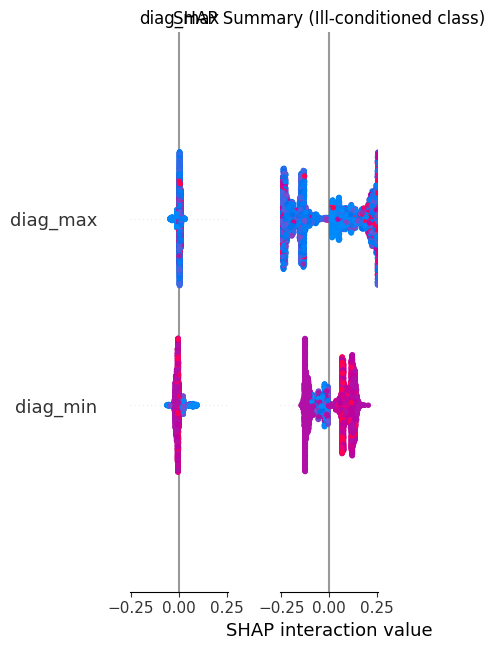

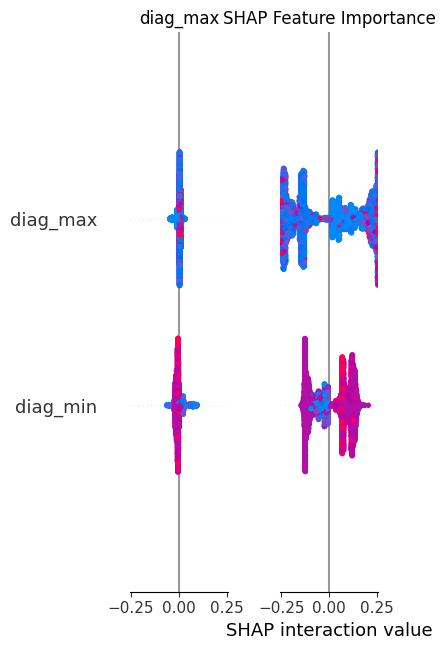

Saved: shap_summary.png, shap_importance.png

=== Optuna Hyperparameter Search (CV-based) ===


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost CLF params (seed=7): {'n_estimators': 46, 'max_depth': 2, 'learning_rate': 0.027107825362887413, 'subsample': 0.6326807158876919, 'colsample_bytree': 0.2552870480721856, 'reg_alpha': 26.04053267875724, 'reg_lambda': 149.2554756231681, 'min_child_weight': 73, 'gamma': 3.2081850272596357}
Best XGBoost CLF CV score (mean-0.5*std) (seed=7): 0.4816343955285328


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost REG params (seed=7): {'n_estimators': 57, 'max_depth': 2, 'learning_rate': 0.02435801147752491, 'subsample': 0.6396929450971267, 'colsample_bytree': 0.30814653567955097, 'reg_alpha': 21.08925756381551, 'reg_lambda': 67.3924396809829, 'min_child_weight': 47, 'gamma': 3.9729467681032737}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM CLF params (seed=7): {'n_estimators': 85, 'max_depth': 2, 'learning_rate': 0.011746874759642884, 'subsample': 0.6474735463458678, 'colsample_bytree': 0.42503648753230305, 'min_child_samples': 213, 'reg_alpha': 17.95174888017971, 'reg_lambda': 32.48996491727874, 'num_leaves': 4}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM REG params (seed=7): {'n_estimators': 103, 'max_depth': 2, 'learning_rate': 0.033103576125753736, 'subsample': 0.43610968551354196, 'colsample_bytree': 0.41525722128362674, 'min_child_samples': 137, 'reg_alpha': 18.785387746548114, 'reg_lambda': 43.18562102911091, 'num_leaves': 6}

[Seed 7] MODEL 1 — RANDOM FOREST
  RF CV AUC=0.9123 | CV F1=0.7818 | Threshold=0.5662
Test -> AUC=0.8338 | Acc=0.7616 | Prec=0.7944 | Rec=0.5897 | F1=0.6769
              precision    recall  f1-score   support

   well-cond       0.75      0.89      0.81      1320
    ill-cond       0.79      0.59      0.68       970

    accuracy                           0.76      2290
   macro avg       0.77      0.74      0.74      2290
weighted avg       0.77      0.76      0.75      2290



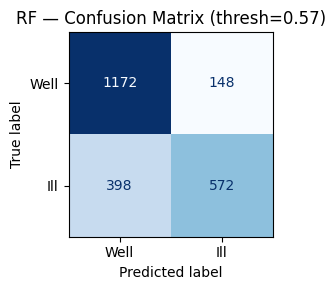

-- RF REGRESSION  MAE=3.4779  R2=0.1641

[Seed 7] MODEL 2 — XGBOOST
  XGB CV AUC=0.9017 | Threshold=0.4956
  XGB final fit stopped at iteration 45 (of 46 requested)
Test -> AUC=0.8850 | Acc=0.7869 | Prec=0.7591 | Rec=0.7278 | F1=0.7432
              precision    recall  f1-score   support

   well-cond       0.81      0.83      0.82      1320
    ill-cond       0.76      0.73      0.74       970

    accuracy                           0.79      2290
   macro avg       0.78      0.78      0.78      2290
weighted avg       0.79      0.79      0.79      2290



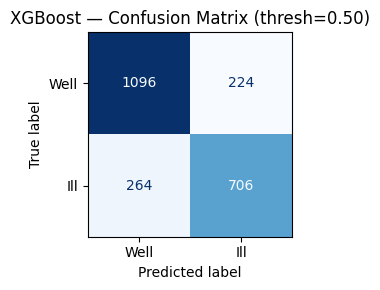

XGBoost REG  MAE=3.5351  R2=0.1796

[Seed 7] MODEL 2b — LIGHTGBM
  LGBM CV AUC=0.8742 | Threshold=0.5022
  LGBM final fit stopped at iteration 8 (of 85 requested)
Test -> AUC=0.8541 | Acc=0.7624 | Prec=0.7878 | Rec=0.6010 | F1=0.6819
              precision    recall  f1-score   support

   well-cond       0.75      0.88      0.81      1320
    ill-cond       0.79      0.60      0.68       970

    accuracy                           0.76      2290
   macro avg       0.77      0.74      0.75      2290
weighted avg       0.77      0.76      0.76      2290



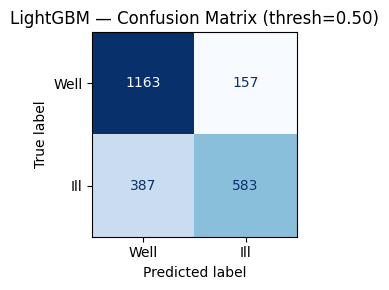

LightGBM REG  MAE=2.8703  R2=0.3038

[Seed 7] MODEL 3 — NEURAL NETWORK
  Fold 1 best_epoch=39  CV-fold AUC=0.5554
  Fold 2 best_epoch=10  CV-fold AUC=0.8660
  Fold 3 best_epoch=2  CV-fold AUC=0.6835
  Fold 4 best_epoch=6  CV-fold AUC=0.7663
  NN overall CV AUC=0.7291 | Threshold=0.5048
Test -> AUC=0.7874 | Acc=0.7048 | Prec=0.6329 | Rec=0.7216 | F1=0.6744
              precision    recall  f1-score   support

   well-cond       0.77      0.69      0.73      1320
    ill-cond       0.63      0.72      0.67       970

    accuracy                           0.70      2290
   macro avg       0.70      0.71      0.70      2290
weighted avg       0.71      0.70      0.71      2290



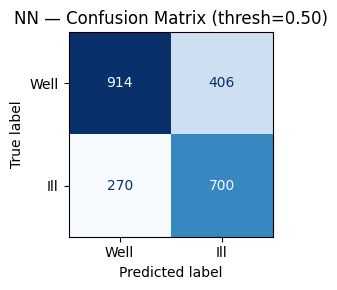

  NN REG  MAE=3.9374  R2=-0.0987

[Seed 7] MODEL 3b — KAN
  Fold 1 best_epoch=4  CV-fold AUC=0.6965
  Fold 2 best_epoch=17  CV-fold AUC=0.8536
  Fold 3 best_epoch=5  CV-fold AUC=0.6611
  Fold 4 best_epoch=13  CV-fold AUC=0.7872
  KAN overall CV AUC=0.7916 | Threshold=0.4528
Test -> AUC=0.7479 | Acc=0.6838 | Prec=0.6185 | Rec=0.6619 | F1=0.6394
              precision    recall  f1-score   support

   well-cond       0.74      0.70      0.72      1320
    ill-cond       0.62      0.66      0.64       970

    accuracy                           0.68      2290
   macro avg       0.68      0.68      0.68      2290
weighted avg       0.69      0.68      0.69      2290



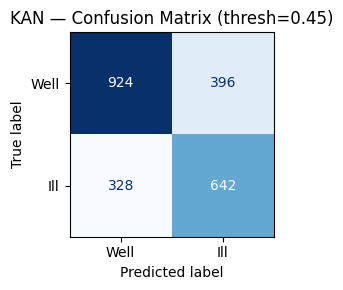

  KAN REG  MAE=3.7381  R2=0.0651

[Seed 7] MODEL 4 — LOGISTIC REGRESSION
Best LR params : {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'poly__degree': 1, 'select__k': 80}
Best CV AUC    : 0.7482
Test -> AUC=0.7945 | Acc=0.6677 | Prec=0.5717 | Rec=0.8588 | F1=0.6864
              precision    recall  f1-score   support

   well-cond       0.84      0.53      0.65      1320
    ill-cond       0.57      0.86      0.69       970

    accuracy                           0.67      2290
   macro avg       0.70      0.69      0.67      2290
weighted avg       0.72      0.67      0.66      2290



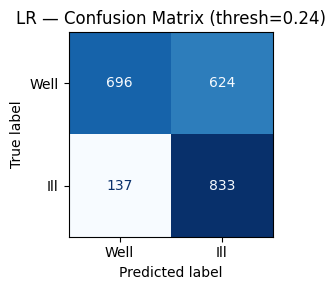


[Seed 7] MODEL 4b — RIDGE REGRESSION
Best Ridge alpha: 1000.0000
Ridge REG  MAE=3.3056  R2=0.2153

[Seed 7] MODEL 5 — k-NEAREST NEIGHBOURS
  k=25  CV AUC=0.6572
  k=41  CV AUC=0.6450
  k=61  CV AUC=0.6455
  k=81  CV AUC=0.6474
  k=101  CV AUC=0.6461
  k=131  CV AUC=0.6465
  Best k=25 (CV AUC=0.6572)
Test -> AUC=0.7883 | Acc=0.6742 | Prec=0.5986 | Rec=0.7010 | F1=0.6458
              precision    recall  f1-score   support

   well-cond       0.75      0.65      0.70      1320
    ill-cond       0.60      0.70      0.65       970

    accuracy                           0.67      2290
   macro avg       0.67      0.68      0.67      2290
weighted avg       0.69      0.67      0.68      2290



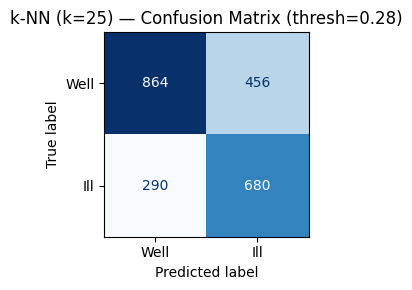

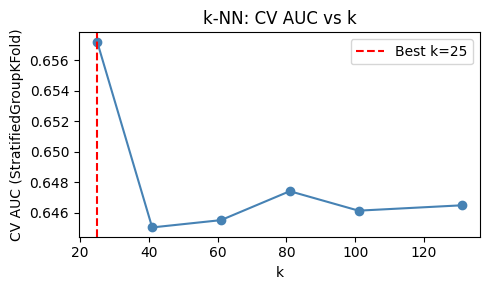

k-NN REG  MAE=3.8527  R2=0.0372


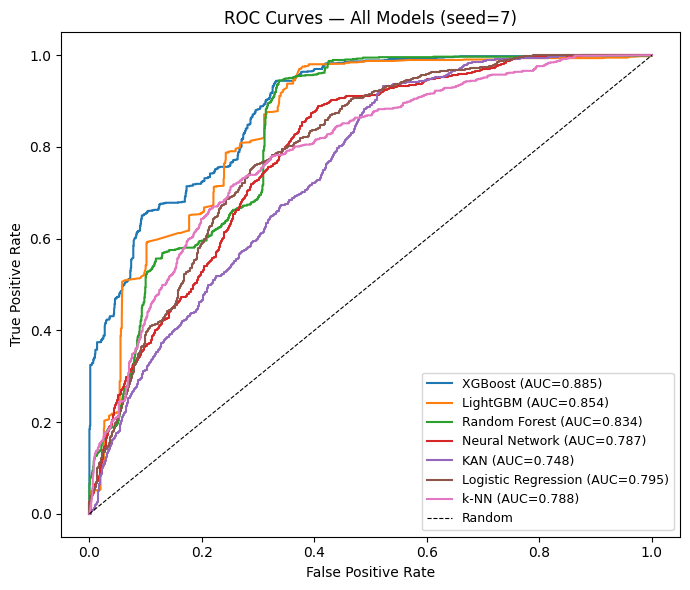

Saved: roc_all_models_seed7.png

=== Per-PDE-Type Performance — All Models ===

-- XGBoost --
  anisotropic                    N= 565  AUC=0.9958  Acc=0.8779  F1=0.8253
  convection_diffusion           N= 572  AUC=0.9761  Acc=0.8357  F1=0.8315
  mixed                          N= 606  AUC=0.9858  Acc=0.7607  F1=0.7709
  stokes_saddle                  N= 547  AUC=0.6795  Acc=0.6709  F1=0.4268

-- LightGBM --
  anisotropic                    N= 565  AUC=0.9980  Acc=0.9699  F1=0.9510
  convection_diffusion           N= 572  AUC=0.9649  Acc=0.7535  F1=0.7241
  mixed                          N= 606  AUC=0.9793  Acc=0.6815  F1=0.6690
  stokes_saddle                  N= 547  AUC=0.5904  Acc=0.6472  F1=0.2825

-- Random Forest --
  anisotropic                    N= 565  AUC=0.9994  Acc=0.9735  F1=0.9563
  convection_diffusion           N= 572  AUC=0.9878  Acc=0.7448  F1=0.7115
  mixed                          N= 606  AUC=0.9829  Acc=0.6716  F1=0.6551
  stokes_saddle                  N= 547  AUC

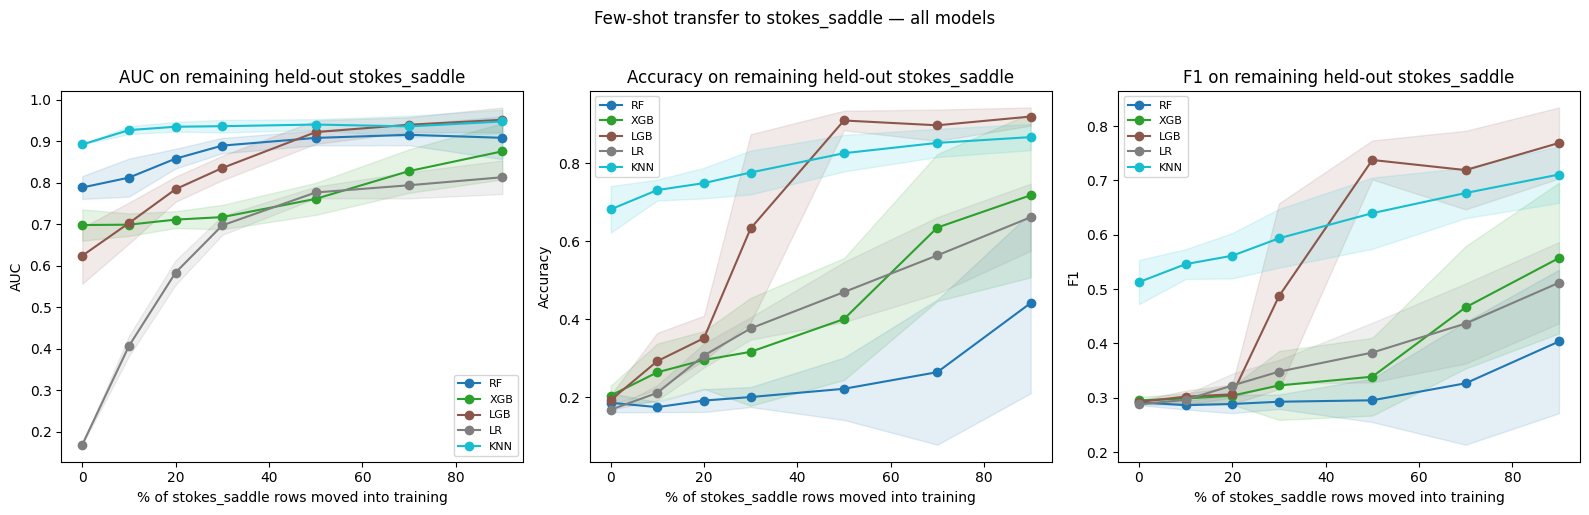

Saved: stokes_saddle_fraction_transfer_curve_all_models.png
Saved: stokes_saddle_fraction_transfer_curve_all_models.csv

SEED 7 — MODEL COMPARISON SUMMARY
              Model  Test AUC  Test Acc  Test Prec  Test Rec  Test F1  Reg MAE  Reg R2
            XGBoost    0.8850    0.7869     0.7591    0.7278   0.7432   3.5351  0.1796
           LightGBM    0.8541    0.7624     0.7878    0.6010   0.6819   2.8703  0.3038
      Random Forest    0.8338    0.7616     0.7944    0.5897   0.6769   3.4779  0.1641
Logistic Regression    0.7945    0.6677     0.5717    0.8588   0.6864   3.3056  0.2153
               k-NN    0.7883    0.6742     0.5986    0.7010   0.6458   3.8527  0.0372
     Neural Network    0.7874    0.7048     0.6329    0.7216   0.6744   3.9374 -0.0987
                KAN    0.7479    0.6838     0.6185    0.6619   0.6394   3.7381  0.0651

  SEED = 42
   Used StratifiedGroupKFold (n_splits=4) grouped by PDE TYPE
   Train size: 5709  (10 PDE types: ['advection_reaction', 'biharmonic', '

  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost CLF params (seed=42): {'n_estimators': 52, 'max_depth': 2, 'learning_rate': 0.05497803996302862, 'subsample': 0.5106008382007756, 'colsample_bytree': 0.3772903872291184, 'reg_alpha': 31.001923284172296, 'reg_lambda': 106.05546819113944, 'min_child_weight': 77, 'gamma': 4.006636633905275}
Best XGBoost CLF CV score (mean-0.5*std) (seed=42): -0.019456200792962175


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost REG params (seed=42): {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.0446270727710559, 'subsample': 0.49150743870410185, 'colsample_bytree': 0.38229251221682764, 'reg_alpha': 10.887393276373533, 'reg_lambda': 93.6789910715623, 'min_child_weight': 35, 'gamma': 1.0251796565662845}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM CLF params (seed=42): {'n_estimators': 104, 'max_depth': 2, 'learning_rate': 0.01166607530767398, 'subsample': 0.5693700517412545, 'colsample_bytree': 0.3040688663966823, 'min_child_samples': 233, 'reg_alpha': 6.868642960638701, 'reg_lambda': 29.867131559820802, 'num_leaves': 4}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM REG params (seed=42): {'n_estimators': 58, 'max_depth': 2, 'learning_rate': 0.030123000257699612, 'subsample': 0.4722350028369864, 'colsample_bytree': 0.4280081405615532, 'min_child_samples': 146, 'reg_alpha': 27.046429155333946, 'reg_lambda': 35.707603009123524, 'num_leaves': 9}

[Seed 42] MODEL 1 — RANDOM FOREST
  RF CV AUC=0.7946 | CV F1=0.7595 | Threshold=0.5033
Test -> AUC=0.9280 | Acc=0.7556 | Prec=0.6002 | Rec=0.8169 | F1=0.6920
              precision    recall  f1-score   support

   well-cond       0.89      0.72      0.80      1521
    ill-cond       0.60      0.82      0.69       770

    accuracy                           0.76      2291
   macro avg       0.74      0.77      0.74      2291
weighted avg       0.79      0.76      0.76      2291

-- RF REGRESSION  MAE=4.0489  R2=0.2639

[Seed 42] MODEL 2 — XGBOOST
  XGB CV AUC=0.8655 | Threshold=0.5900
  XGB final fit stopped at iteration 51 (of 52 requested)
Test -> AUC=0.9334 | Acc=0.8202 | Prec=0.7331 | Rec=0

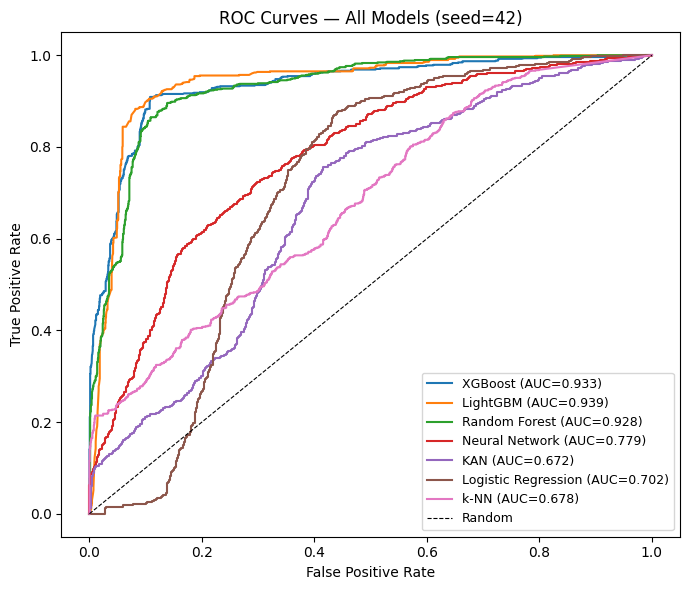

Saved: roc_all_models_seed42.png

SEED 42 — MODEL COMPARISON SUMMARY
              Model  Test AUC  Test Acc  Test Prec  Test Rec  Test F1  Reg MAE  Reg R2
           LightGBM    0.9389    0.7739     0.6364    0.7636   0.6942   3.6024  0.3432
            XGBoost    0.9334    0.8202     0.7331    0.7312   0.7321   3.5776  0.3964
      Random Forest    0.9280    0.7556     0.6002    0.8169   0.6920   4.0489  0.2639
     Neural Network    0.7789    0.6024     0.4402    0.6740   0.5326   3.7437  0.3005
Logistic Regression    0.7024    0.6211     0.4573    0.6818   0.5474   4.0842  0.2116
               k-NN    0.6782    0.5631     0.3993    0.5948   0.4778   4.6002 -0.0478
                KAN    0.6719    0.5613     0.4109    0.7039   0.5189   3.7141  0.3572

  SEED = 123
   Used StratifiedGroupKFold (n_splits=4) grouped by PDE TYPE
   Train size: 5695  (10 PDE types: ['advection_reaction', 'anisotropic', 'biharmonic', 'convection_diffusion', 'heterogeneous_diffusion', 'parabolic', 'poisso

  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost CLF params (seed=123): {'n_estimators': 51, 'max_depth': 2, 'learning_rate': 0.03593238976002253, 'subsample': 0.53426942523138, 'colsample_bytree': 0.29643654335941544, 'reg_alpha': 56.02964396827515, 'reg_lambda': 98.35595327273688, 'min_child_weight': 70, 'gamma': 3.640239394094868}
Best XGBoost CLF CV score (mean-0.5*std) (seed=123): 0.4710457729727209


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost REG params (seed=123): {'n_estimators': 86, 'max_depth': 2, 'learning_rate': 0.04180281545876511, 'subsample': 0.5779323377744142, 'colsample_bytree': 0.3809654255897041, 'reg_alpha': 10.05539006231817, 'reg_lambda': 25.992271900345667, 'min_child_weight': 53, 'gamma': 3.998348107257998}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM CLF params (seed=123): {'n_estimators': 128, 'max_depth': 2, 'learning_rate': 0.015502146721693803, 'subsample': 0.5027065268630563, 'colsample_bytree': 0.4202693550423933, 'min_child_samples': 216, 'reg_alpha': 7.575108757018713, 'reg_lambda': 38.754559789899595, 'num_leaves': 4}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM REG params (seed=123): {'n_estimators': 111, 'max_depth': 3, 'learning_rate': 0.03458891680635177, 'subsample': 0.4328122439843647, 'colsample_bytree': 0.3323009234123432, 'min_child_samples': 141, 'reg_alpha': 25.392641991948597, 'reg_lambda': 42.505067091099605, 'num_leaves': 8}

[Seed 123] MODEL 1 — RANDOM FOREST
  RF CV AUC=0.8010 | CV F1=0.7756 | Threshold=0.3622
Test -> AUC=0.8779 | Acc=0.6790 | Prec=0.5360 | Rec=0.7836 | F1=0.6365
              precision    recall  f1-score   support

   well-cond       0.84      0.62      0.71      1478
    ill-cond       0.54      0.78      0.64       827

    accuracy                           0.68      2305
   macro avg       0.69      0.70      0.67      2305
weighted avg       0.73      0.68      0.69      2305

-- RF REGRESSION  MAE=3.2116  R2=0.2949

[Seed 123] MODEL 2 — XGBOOST
  XGB CV AUC=0.8717 | Threshold=0.5149
  XGB final fit stopped at iteration 50 (of 51 requested)
Test -> AUC=0.8932 | Acc=0.7683 | Prec=0.6806 | Re

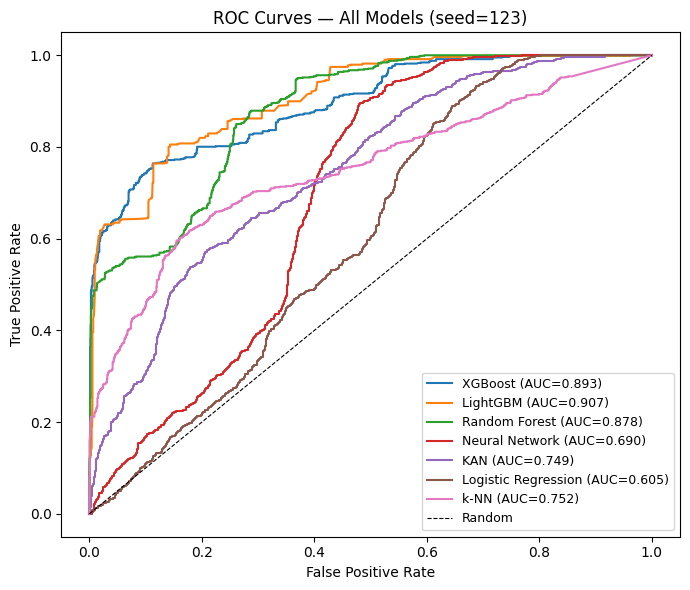

Saved: roc_all_models_seed123.png

SEED 123 — MODEL COMPARISON SUMMARY
              Model  Test AUC  Test Acc  Test Prec  Test Rec  Test F1  Reg MAE  Reg R2
           LightGBM    0.9066    0.7748     0.6410    0.8464   0.7295   2.3688  0.4707
            XGBoost    0.8932    0.7683     0.6806    0.6675   0.6740   2.6269  0.4681
      Random Forest    0.8779    0.6790     0.5360    0.7836   0.6365   3.2116  0.2949
               k-NN    0.7518    0.6312     0.4905    0.7183   0.5829   3.4039  0.2422
                KAN    0.7487    0.6729     0.5366    0.6469   0.5866   2.8787  0.3251
     Neural Network    0.6897    0.6416     0.5004    0.7050   0.5853   4.7611 -0.4017
Logistic Regression    0.6054    0.6030     0.4645    0.6953   0.5569   3.7421  0.0141

  SEED = 999
   Used StratifiedGroupKFold (n_splits=4) grouped by PDE TYPE
   Train size: 5739  (10 PDE types: ['advection_reaction', 'anisotropic', 'helmholtz', 'heterogeneous_diffusion', 'hyperbolic', 'mixed', 'parabolic', 'reacti

  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost CLF params (seed=999): {'n_estimators': 60, 'max_depth': 2, 'learning_rate': 0.026314772687440625, 'subsample': 0.5955989835885251, 'colsample_bytree': 0.44553086530166086, 'reg_alpha': 34.43026661994135, 'reg_lambda': 140.11755071852605, 'min_child_weight': 74, 'gamma': 4.950055679885608}
Best XGBoost CLF CV score (mean-0.5*std) (seed=999): 0.7733274609076012


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost REG params (seed=999): {'n_estimators': 52, 'max_depth': 3, 'learning_rate': 0.01759185293543683, 'subsample': 0.535249399116356, 'colsample_bytree': 0.44933401358072556, 'reg_alpha': 18.030356679572833, 'reg_lambda': 45.62280436167597, 'min_child_weight': 45, 'gamma': 2.9985716933400783}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM CLF params (seed=999): {'n_estimators': 116, 'max_depth': 2, 'learning_rate': 0.03658269011102295, 'subsample': 0.6234107801882001, 'colsample_bytree': 0.2875260526484235, 'min_child_samples': 236, 'reg_alpha': 6.895355957847716, 'reg_lambda': 39.482542977108665, 'num_leaves': 4}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM REG params (seed=999): {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.03858820235760118, 'subsample': 0.4453640731515093, 'colsample_bytree': 0.35871397496702145, 'min_child_samples': 155, 'reg_alpha': 13.19860686352347, 'reg_lambda': 23.909754589326873, 'num_leaves': 10}

[Seed 999] MODEL 1 — RANDOM FOREST
  RF CV AUC=0.9208 | CV F1=0.8062 | Threshold=0.4805
Test -> AUC=0.7434 | Acc=0.7532 | Prec=0.6832 | Rec=0.6970 | F1=0.6900
              precision    recall  f1-score   support

   well-cond       0.80      0.79      0.80      1370
    ill-cond       0.68      0.70      0.69       891

    accuracy                           0.75      2261
   macro avg       0.74      0.74      0.74      2261
weighted avg       0.75      0.75      0.75      2261

-- RF REGRESSION  MAE=3.4690  R2=-0.0347

[Seed 999] MODEL 2 — XGBOOST
  XGB CV AUC=0.9322 | Threshold=0.4263
  XGB final fit stopped at iteration 59 (of 60 requested)
Test -> AUC=0.7863 | Acc=0.7430 | Prec=0.6279 | R

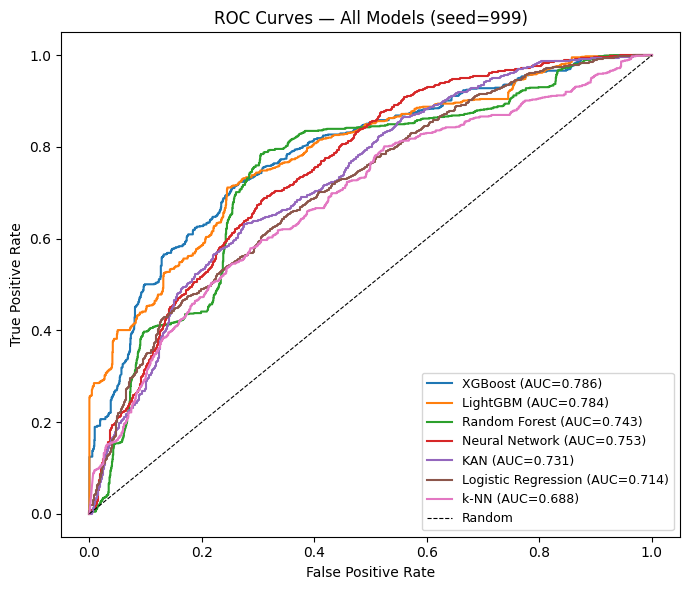

Saved: roc_all_models_seed999.png

SEED 999 — MODEL COMPARISON SUMMARY
              Model  Test AUC  Test Acc  Test Prec  Test Rec  Test F1  Reg MAE  Reg R2
            XGBoost    0.7863    0.7430     0.6279    0.8541   0.7237   3.3722  0.0664
           LightGBM    0.7841    0.7386     0.6250    0.8418   0.7174   3.0522 -0.0163
     Neural Network    0.7527    0.6457     0.5339    0.7957   0.6390   4.5207 -0.2944
      Random Forest    0.7434    0.7532     0.6832    0.6970   0.6900   3.4690 -0.0347
                KAN    0.7308    0.6630     0.5716    0.5780   0.5748   3.4039  0.1130
Logistic Regression    0.7142    0.5935     0.4898    0.7520   0.5932   4.4224 -0.1086
               k-NN    0.6880    0.5763     0.4715    0.6218   0.5363   4.5716 -0.3204

  SEED = 2024
   Used StratifiedGroupKFold (n_splits=4) grouped by PDE TYPE
   Train size: 5721  (10 PDE types: ['anisotropic', 'convection_diffusion', 'helmholtz', 'heterogeneous_diffusion', 'hyperbolic', 'mixed', 'parabolic', 'poi

  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost CLF params (seed=2024): {'n_estimators': 38, 'max_depth': 2, 'learning_rate': 0.07654226109802063, 'subsample': 0.603493077263205, 'colsample_bytree': 0.26020595531114243, 'reg_alpha': 64.38102979330729, 'reg_lambda': 111.91745079040328, 'min_child_weight': 133, 'gamma': 1.62062609795107}
Best XGBoost CLF CV score (mean-0.5*std) (seed=2024): 0.49698591020571437


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGBoost REG params (seed=2024): {'n_estimators': 68, 'max_depth': 2, 'learning_rate': 0.011746621976326048, 'subsample': 0.6332096984140326, 'colsample_bytree': 0.29631977295075784, 'reg_alpha': 12.108895626976787, 'reg_lambda': 51.54962180509289, 'min_child_weight': 80, 'gamma': 2.569169608738002}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM CLF params (seed=2024): {'n_estimators': 114, 'max_depth': 2, 'learning_rate': 0.02669748834611399, 'subsample': 0.5203838622755478, 'colsample_bytree': 0.31529352909725533, 'min_child_samples': 193, 'reg_alpha': 8.242656465125867, 'reg_lambda': 13.00772611147055, 'num_leaves': 6}


  0%|          | 0/30 [00:00<?, ?it/s]

Best LightGBM REG params (seed=2024): {'n_estimators': 40, 'max_depth': 2, 'learning_rate': 0.04644409452323026, 'subsample': 0.6453178870286798, 'colsample_bytree': 0.3405618356677378, 'min_child_samples': 190, 'reg_alpha': 33.68172614222647, 'reg_lambda': 43.432029310305744, 'num_leaves': 8}

[Seed 2024] MODEL 1 — RANDOM FOREST
  RF CV AUC=0.8078 | CV F1=0.7273 | Threshold=0.6552
Test -> AUC=0.9210 | Acc=0.7266 | Prec=0.5792 | Rec=0.6828 | F1=0.6267
              precision    recall  f1-score   support

   well-cond       0.82      0.75      0.78      1513
    ill-cond       0.58      0.68      0.63       766

    accuracy                           0.73      2279
   macro avg       0.70      0.72      0.71      2279
weighted avg       0.74      0.73      0.73      2279

-- RF REGRESSION  MAE=2.7799  R2=0.2998

[Seed 2024] MODEL 2 — XGBOOST
  XGB CV AUC=0.8413 | Threshold=0.5263
  XGB final fit stopped at iteration 36 (of 38 requested)
Test -> AUC=0.8438 | Acc=0.6472 | Prec=0.4809 | R

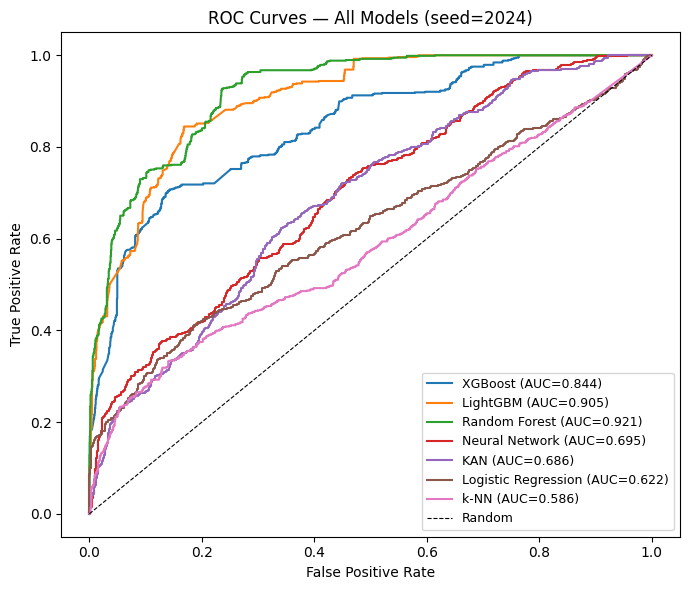

Saved: roc_all_models_seed2024.png

SEED 2024 — MODEL COMPARISON SUMMARY
              Model  Test AUC  Test Acc  Test Prec  Test Rec  Test F1  Reg MAE  Reg R2
      Random Forest    0.9210    0.7266     0.5792    0.6828   0.6267   2.7799  0.2998
           LightGBM    0.9045    0.6801     0.5152    0.8211   0.6331   2.5430  0.2655
            XGBoost    0.8438    0.6472     0.4809    0.6240   0.5432   3.0831  0.2537
     Neural Network    0.6947    0.5665     0.4216    0.7794   0.5472   3.0642  0.2426
                KAN    0.6860    0.6068     0.4477    0.7272   0.5542   3.1846  0.0094
Logistic Regression    0.6220    0.5213     0.3753    0.6384   0.4727   3.2028  0.1776
               k-NN    0.5862    0.5331     0.3769    0.5953   0.4615   3.8591 -0.3992


In [ ]:
# ================================================================
# MULTI-SEED LOOP
# ================================================================
for seed in SEEDS:
    print(f"\n{'='*70}\n  SEED = {seed}\n{'='*70}")
    torch.manual_seed(seed)
    np.random.seed(seed)

    # ============================================================
    # 5. GROUP-AWARE, STRATIFIED TRAIN / TEST SPLIT (grouped by PDE TYPE)
    # ============================================================
    X = df.drop(columns=[target_col, 'pde_type'], errors='ignore')
    y = df[target_col]
    groups_all = df['pde_type']

    train_idx, test_idx = pde_group_split(X, y, groups_all, N_SPLITS, seed)
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

    overlap = set(groups_all.iloc[train_idx]) & set(groups_all.iloc[test_idx])
    assert len(overlap) == 0, f"Group leakage detected! Overlapping PDE types: {overlap}"

    y_train_reg     = df_raw.loc[X_train.index, 'log10_cond'].values
    y_test_reg      = df_raw.loc[X_test.index,  'log10_cond'].values
    pde_test_labels = df.loc[X_test.index, 'pde_type'].values

    print(f"Final Split -> Train: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%) | "
          f"Test: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
    print(f"   Group overlap check passed (0 shared PDE types).")

    pde_train_labels = df.loc[X_train.index, 'pde_type'].values
    groups_train = pd.Series(pde_train_labels).reset_index(drop=True)
    X_train = X_train.drop(columns=['grid_size', 'mesh_size'], errors='ignore')
    X_test  = X_test.drop(columns=['grid_size', 'mesh_size'], errors='ignore')

    feature_clip_low  = X_train.quantile(0.01)
    feature_clip_high = X_train.quantile(0.99)

    # ============================================================
    # 6. SCALE (fit on train only)
    # ============================================================
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    feature_cols = X_train.columns.tolist()
    X_train_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
    X_test_df  = pd.DataFrame(X_test_scaled,  columns=feature_cols, index=X_test.index)

    y_train = y_train.reset_index(drop=True)
    y_test  = y_test.reset_index(drop=True)
    X_train_df = X_train_df.reset_index(drop=True)
    X_test_df  = X_test_df.reset_index(drop=True)

    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    gkf   = GroupKFold(n_splits=N_SPLITS)

    # ============================================================
    # 7. STRATIFIED GROUP K-FOLD DIAGNOSTIC (groups = PDE type)
    # ============================================================
    if seed == SEEDS[0]:
        print(f"\n=== StratifiedGroupKFold Diagnostic (n_splits={N_SPLITS}, groups=PDE type) ===")
        fold_stats = []
        for fold, (tr_idx, cv_idx) in enumerate(sgkf.split(X_train_df, y_train, groups=groups_train)):
            fold_y_tr = y_train.iloc[tr_idx]
            fold_y_cv = y_train.iloc[cv_idx]
            fold_pdes_cv = groups_train.iloc[cv_idx].unique()
            print(f"Fold {fold+1} | Train={len(tr_idx)} CV={len(cv_idx)} | "
                  f"CV PDE types={sorted(fold_pdes_cv)} | Ill rate train={fold_y_tr.mean():.3f} "
                  f"cv={fold_y_cv.mean():.3f}")
            fold_stats.append({'fold': fold+1, 'cv_size': len(cv_idx),
                                'pde_types_in_cv': len(fold_pdes_cv), 'ill_rate_cv': fold_y_cv.mean()})
        fold_df = pd.DataFrame(fold_stats)
        print(fold_df.to_string(index=False))

    # ============================================================
    # 8. BORUTA FEATURE SELECTION
    # ============================================================
    try:
        from boruta import BorutaPy
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'pip', 'install', 'Boruta'], check=True)
        from boruta import BorutaPy

    print(f"\n=== Boruta Feature Selection (seed={seed}, on this seed's train set) ===")
    rf_boruta = RandomForestClassifier(
        n_estimators=200, max_depth=7, class_weight='balanced',
        random_state=seed, n_jobs=-1
    )
    boruta_selector = BorutaPy(
        estimator=rf_boruta, n_estimators='auto', perc=100,
        max_iter=100, random_state=seed, verbose=0
    )
    boruta_selector.fit(X_train_df.values, y_train.values)
    selected = [f for f, s in zip(feature_cols, boruta_selector.support_) if s]
    final_features = [f for f in selected if f in X_train_df.columns]
    if len(final_features) == 0:
        print("⚠️  Boruta selected 0 features — falling back to all features.")
        final_features = feature_cols[:]
    final_features_by_seed[seed] = final_features
    print(f"Confirmed: {len(selected)} | Final: {len(final_features)}")

    X_train_final = X_train_df[final_features].reset_index(drop=True)
    X_test_final  = X_test_df[final_features].reset_index(drop=True)
    groups_train  = groups_train.reset_index(drop=True)

    assert len(X_train_final) == len(y_train) == len(y_train_reg) == len(groups_train)
    assert len(X_test_final)  == len(y_test)  == len(y_test_reg)
    print(f"[Seed {seed}] Shapes verified: Train={len(X_train_final)} Test={len(X_test_final)}")

    # ============================================================
    # 9. SHAP
    # ============================================================
    if seed == SEEDS[0]:
        print("\n=== SHAP (first seed only, on train set) ===")
        rf_shap = RandomForestClassifier(
            n_estimators=300, max_depth=7, class_weight='balanced',
            random_state=seed, n_jobs=-1
        )
        rf_shap.fit(X_train_final, y_train)
        explainer = shap.TreeExplainer(rf_shap)
        shap_values = explainer.shap_values(X_train_final)
        shap_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

        shap.summary_plot(shap_class1, X_train_final, feature_names=final_features, show=False)
        plt.title("SHAP Summary (Ill-conditioned class)")
        plt.tight_layout(); plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight'); plt.show()

        shap.summary_plot(shap_class1, X_train_final, feature_names=final_features,
                           plot_type='bar', show=False)
        plt.title("SHAP Feature Importance")
        plt.tight_layout(); plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight'); plt.show()
        print("Saved: shap_summary.png, shap_importance.png")

    # ============================================================
    # 10. POWER TRANSFORM (for LR / NN / KAN / Ridge)
    # ============================================================
    X_train_raw = X_train[final_features].reset_index(drop=True)
    X_test_raw  = X_test[final_features].reset_index(drop=True)
    pt = PowerTransformer(method='yeo-johnson', standardize=True)
    X_train_pt = safe_power_transform(pt, X_train_raw, fit=True)
    X_test_pt  = safe_power_transform(pt, X_test_raw,  fit=False)

    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

    # ============================================================
    # OPTUNA — CV-based objectives
    # ============================================================
    print("\n=== Optuna Hyperparameter Search (CV-based) ===")

    MAX_ACCEPTABLE_GAP = 0.03
    GAP_PENALTY_WEIGHT = 4.0

    def _group_cv_auc_with_gap_penalty(params, X, y, groups, cv, is_lgb=False, n_repeats=3):
        all_cv_aucs, all_max_gaps = [], []
        for rep in range(n_repeats):
            cv_rep = StratifiedGroupKFold(n_splits=cv.get_n_splits(), shuffle=True,
                                       random_state=rep * 1000 + 7)
            cv_aucs, train_aucs = [], []
            for tr_idx, va_idx in cv_rep.split(X, y, groups):
                X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
                y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
                if y_va.nunique() < 2:
                    continue
                sp = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
                if is_lgb:
                    model = lgb.LGBMClassifier(**params, class_weight='balanced',
                                        random_state=0, n_jobs=-1, verbose=-1)
                    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
                      eval_metric='auc', callbacks=[lgb.early_stopping(30, verbose=False)])
                else:
                    model = xgb.XGBClassifier(**params, scale_pos_weight=sp,
                                       eval_metric='auc', random_state=0,
                                       n_jobs=-1, verbosity=0, early_stopping_rounds=30)
                    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

                train_prob = model.predict_proba(X_tr)[:, 1]
                va_prob = model.predict_proba(X_va)[:, 1]
                train_aucs.append(roc_auc_score(y_tr, train_prob))
                cv_aucs.append(roc_auc_score(y_va, va_prob))

            cv_aucs = np.array(cv_aucs)
            train_aucs = np.array(train_aucs)
            all_cv_aucs.append(cv_aucs.mean())
            all_max_gaps.append((train_aucs - cv_aucs).max())

        mean_cv  = np.mean(all_cv_aucs)
        worst_cv = np.min(all_cv_aucs)
        max_gap  = np.max(all_max_gaps)

        score = 0.5 * mean_cv + 0.5 * worst_cv
        excess_gap = max(0.0, max_gap - MAX_ACCEPTABLE_GAP)
        score -= GAP_PENALTY_WEIGHT * excess_gap
        return score

    def xgb_clf_objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 25, 60),
            'max_depth':        trial.suggest_int('max_depth', 2, 2),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
            'subsample':        trial.suggest_float('subsample', 0.4, 0.65),
            'colsample_bytree': trial.suggest_float('colsample_bytree',0.25, 0.45),
            'reg_alpha':        trial.suggest_float('reg_alpha', 25.0, 80.0, log=True),
            'reg_lambda':       trial.suggest_float('reg_lambda',  60.0, 150.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight',  70, 150),
            'gamma':            trial.suggest_float('gamma', 1.0, 5.0),
        }
        return _group_cv_auc_with_gap_penalty(params, X_train_final, y_train, groups_train, sgkf, is_lgb=False)

    def lgb_clf_objective(trial):
        params = {
        'n_estimators':      trial.suggest_int('n_estimators',  60, 150),
        'max_depth':         trial.suggest_int('max_depth', 2, 2),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 0.65),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.25, 0.45),
        'min_child_samples': trial.suggest_int('min_child_samples', 150, 300),
        'reg_alpha':         trial.suggest_float('reg_alpha', 5.0, 30.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 10.0, 40.0, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 3,6),
        }
        return _group_cv_auc_with_gap_penalty(params, X_train_final, y_train, groups_train, sgkf, is_lgb=True)

    def _group_cv_mae_with_gap_penalty(params, X, y, groups, cv, is_lgb=False,n_repeats=3):
        all_cv_maes, all_max_gaps = [], []
        for rep in range(n_repeats):
            cv_rep = GroupKFold(n_splits=cv.get_n_splits())
            cv_maes, train_maes = [], []
            for tr_idx, va_idx in cv.split(X, y, groups):
                X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
                y_tr, y_va = y[tr_idx], y[va_idx]
                if is_lgb:
                    model = lgb.LGBMRegressor(**params, objective='regression_l1',
                                       random_state=0, n_jobs=-1, verbose=-1)
                    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
                      eval_metric='mae', callbacks=[lgb.early_stopping(30, verbose=False)])
                else:
                    model = xgb.XGBRegressor(**params, objective='reg:squarederror',
                                      random_state=0, n_jobs=-1, verbosity=0,
                                      early_stopping_rounds=30)
                    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

                train_maes.append(mean_absolute_error(y_tr, model.predict(X_tr)))
                cv_maes.append(mean_absolute_error(y_va, model.predict(X_va)))

            cv_maes = np.array(cv_maes)
            train_maes = np.array(train_maes)
            all_cv_maes.append(cv_maes.mean())
            all_max_gaps.append((cv_maes - train_maes).max())

        mean_mae = np.mean(all_cv_maes)
        worst_mae = np.max(all_cv_maes)
        max_gap  = np.max(all_max_gaps)
        score = 0.5 * mean_mae + 0.5 * worst_mae
        MAX_MAE_GAP = 0.6
        excess = max(0.0, max_gap - MAX_MAE_GAP)
        score += 4.0 * excess
        return score

    def xgb_reg_objective(trial):
        params = {
        'n_estimators':     trial.suggest_int('n_estimators', 40, 120),
        'max_depth':        trial.suggest_int('max_depth', 2, 3),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.06, log=True),
        'subsample':        trial.suggest_float('subsample', 0.4, 0.65),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.25, 0.45),
        'reg_alpha':        trial.suggest_float('reg_alpha',10.0, 50.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 25.0, 100.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 30, 80),
        'gamma':            trial.suggest_float('gamma', 1.0, 4.0),
        }
        return _group_cv_mae_with_gap_penalty(params, X_train_final, y_train_reg, groups_train, gkf, is_lgb=False)

    def lgb_reg_objective(trial):
        params = {
        'n_estimators':      trial.suggest_int('n_estimators', 40, 120),
        'max_depth':         trial.suggest_int('max_depth', 2, 3),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.06, log=True),
        'subsample':         trial.suggest_float('subsample', 0.4, 0.65),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.25, 0.45),
        'min_child_samples': trial.suggest_int('min_child_samples',120, 250),
        'reg_alpha':         trial.suggest_float('reg_alpha', 10.0, 40.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 15.0, 50.0, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 4, 10),
        }
        return _group_cv_mae_with_gap_penalty(params, X_train_final, y_train_reg, groups_train, gkf, is_lgb=True)

    study_xgb_clf = optuna.create_study(direction='maximize')
    study_xgb_clf.optimize(xgb_clf_objective, n_trials=30, show_progress_bar=True)
    best_xgb_clf_params = study_xgb_clf.best_params
    print(f"Best XGBoost CLF params (seed={seed}):", best_xgb_clf_params)
    print(f"Best XGBoost CLF CV score (mean-0.5*std) (seed={seed}):", study_xgb_clf.best_value)

    study_xgb_reg = optuna.create_study(direction='minimize')
    study_xgb_reg.optimize(xgb_reg_objective, n_trials=30, show_progress_bar=True)
    best_xgb_reg_params = study_xgb_reg.best_params
    print(f"Best XGBoost REG params (seed={seed}):", best_xgb_reg_params)

    study_lgb_clf = optuna.create_study(direction='maximize')
    study_lgb_clf.optimize(lgb_clf_objective, n_trials=30, show_progress_bar=True)
    best_lgb_clf_params = study_lgb_clf.best_params
    print(f"Best LightGBM CLF params (seed={seed}):", best_lgb_clf_params)

    study_lgb_reg = optuna.create_study(direction='minimize')
    study_lgb_reg.optimize(lgb_reg_objective, n_trials=30, show_progress_bar=True)
    best_lgb_reg_params = study_lgb_reg.best_params
    print(f"Best LightGBM REG params (seed={seed}):", best_lgb_reg_params)

    # ============================================================
    # MODEL 1 — RANDOM FOREST
    # ============================================================
    print(f"\n{'='*60}\n[Seed {seed}] MODEL 1 — RANDOM FOREST\n{'='*60}")
    rf_clf = RandomForestClassifier(
    n_estimators=150, max_depth=2,
    min_samples_leaf=150, min_samples_split=250,
    max_features=0.3, max_samples=0.35,
    class_weight='balanced', random_state=seed, n_jobs=-1
    )

    # ============================================================
    # MODEL 1 — RANDOM FOREST
    # ============================================================
    oof_prob_rf = cross_val_predict(rf_clf, X_train_final, y_train, groups=groups_train,
                                 cv=sgkf, method='predict_proba', n_jobs=-1)[:, 1]
    rf_thresh = best_threshold_youden(y_train, oof_prob_rf, blend=1.0)
    cv_auc_rf = roc_auc_score(y_train, oof_prob_rf)
    cv_pred_rf = (oof_prob_rf >= rf_thresh).astype(int)
    cv_f1_rf = f1_score(y_train, cv_pred_rf, zero_division=0)
    print(f"  RF CV AUC={cv_auc_rf:.4f} | CV F1={cv_f1_rf:.4f} | Threshold={rf_thresh:.4f}")
    rf_clf.fit(X_train_final, y_train)
    test_prob_rf_raw = rf_clf.predict_proba(X_test_final)[:, 1]
    test_prob_rf, test_pred_rf = recalibrate_predictions_per_pde(
    test_prob_rf_raw, oof_prob_rf, rf_thresh, pde_test_labels, model_key='rf')


    test_auc_rf  = roc_auc_score(y_test, test_prob_rf)
    rf_test_acc  = accuracy_score(y_test, test_pred_rf)
    rf_test_prec = precision_score(y_test, test_pred_rf, zero_division=0)
    rf_test_rec  = recall_score(y_test, test_pred_rf, zero_division=0)
    rf_test_f1   = f1_score(y_test, test_pred_rf, zero_division=0)
    print(f"Test -> AUC={test_auc_rf:.4f} | Acc={rf_test_acc:.4f} | Prec={rf_test_prec:.4f} "
          f"| Rec={rf_test_rec:.4f} | F1={rf_test_f1:.4f}")
    print(classification_report(y_test, test_pred_rf, target_names=["well-cond", "ill-cond"]))

    if seed == SEEDS[0]:
        cm = confusion_matrix(y_test, test_pred_rf)
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm, display_labels=["Well", "Ill"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"RF — Confusion Matrix (thresh={rf_thresh:.2f})")
        plt.tight_layout(); plt.savefig("cm_rf.png", dpi=150); plt.show()

    rf_reg = RandomForestRegressor(
    n_estimators=150, max_depth=2,
    min_samples_leaf=250, min_samples_split=400,
    max_features=0.25, max_samples=0.3,
    random_state=seed, n_jobs=-1
        )
    rf_reg.fit(X_train_final, y_train_reg)
    rf_train_pred_reg = rf_reg.predict(X_train_final)
    test_pred_reg_rf = rf_reg.predict(X_test_final)
    mae_rf = mean_absolute_error(y_test_reg, test_pred_reg_rf)
    r2_rf  = r2_score(y_test_reg, test_pred_reg_rf)

    print(f"-- RF REGRESSION  MAE={mae_rf:.4f}  R2={r2_rf:.4f}")

    # ============================================================
    # MODEL 2a — XGBOOST
    # ============================================================
    print(f"\n{'='*60}\n[Seed {seed}] MODEL 2 — XGBOOST\n{'='*60}")
    gss_final = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    fit_tr_idx, fit_val_idx = next(gss_final.split(X_train_final, y_train, groups_train))

    xgb_clf_for_oof = xgb.XGBClassifier(**best_xgb_clf_params, scale_pos_weight=scale_pos,
                                     eval_metric='logloss', random_state=seed, n_jobs=-1, verbosity=0)
    oof_prob_xgb = np.zeros(len(y_train))
    for tr_idx, va_idx in sgkf.split(X_train_final, y_train, groups_train):
        X_tr, X_va = X_train_final.iloc[tr_idx], X_train_final.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        if y_va.nunique() < 2:
            continue
        sp_fold = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
        m = xgb.XGBClassifier(**best_xgb_clf_params, scale_pos_weight=sp_fold,
                           eval_metric='logloss', random_state=seed, n_jobs=-1,
                           verbosity=0, early_stopping_rounds=30)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        oof_prob_xgb[va_idx] = m.predict_proba(X_va)[:, 1]
    xgb_thresh = best_threshold_youden(y_train, oof_prob_xgb,blend=1.0)
    cv_auc_xgb = roc_auc_score(y_train, oof_prob_xgb)
    print(f"  XGB CV AUC={cv_auc_xgb:.4f} | Threshold={xgb_thresh:.4f}")

    xgb_clf = xgb.XGBClassifier(**best_xgb_clf_params, scale_pos_weight=scale_pos,
                             eval_metric='logloss', random_state=seed, n_jobs=-1,
                             verbosity=0, early_stopping_rounds=30)
    xgb_clf.fit(X_train_final.iloc[fit_tr_idx], y_train.iloc[fit_tr_idx],
            eval_set=[(X_train_final.iloc[fit_val_idx], y_train.iloc[fit_val_idx])],
            verbose=False)
    print(f"  XGB final fit stopped at iteration {xgb_clf.best_iteration} "
      f"(of {best_xgb_clf_params['n_estimators']} requested)")

    xgb_test_prob_raw = xgb_clf.predict_proba(X_test_final)[:, 1]

    xgb_test_prob, xgb_test_pred = recalibrate_predictions_per_pde(
    xgb_test_prob_raw, oof_prob_xgb, xgb_thresh, pde_test_labels, model_key='xgb')

    xgb_test_auc  = roc_auc_score(y_test, xgb_test_prob)
    xgb_test_acc  = accuracy_score(y_test, xgb_test_pred)
    xgb_test_prec = precision_score(y_test, xgb_test_pred, zero_division=0)
    xgb_test_rec  = recall_score(y_test, xgb_test_pred, zero_division=0)
    xgb_test_f1   = f1_score(y_test, xgb_test_pred, zero_division=0)
    print(f"Test -> AUC={xgb_test_auc:.4f} | Acc={xgb_test_acc:.4f} | Prec={xgb_test_prec:.4f} "
          f"| Rec={xgb_test_rec:.4f} | F1={xgb_test_f1:.4f}")
    print(classification_report(y_test, xgb_test_pred, target_names=["well-cond", "ill-cond"]))

    if seed == SEEDS[0]:
        cm = confusion_matrix(y_test, xgb_test_pred)
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm, display_labels=["Well", "Ill"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"XGBoost — Confusion Matrix (thresh={xgb_thresh:.2f})")
        plt.tight_layout(); plt.savefig("cm_xgb.png", dpi=150); plt.show()

    xgb_reg = xgb.XGBRegressor(**best_xgb_reg_params, objective='reg:squarederror',
                            random_state=seed, n_jobs=-1, early_stopping_rounds=30)
    xgb_reg.fit(
    X_train_final.iloc[fit_tr_idx], y_train_reg[fit_tr_idx],
    eval_set=[(X_train_final.iloc[fit_val_idx], y_train_reg[fit_val_idx])],
    verbose=False,
    )
    xgb_train_pred_reg = xgb_reg.predict(X_train_final)
    xgb_test_pred_reg = xgb_reg.predict(X_test_final)
    xgb_mae = mean_absolute_error(y_test_reg, xgb_test_pred_reg)
    xgb_r2  = r2_score(y_test_reg, xgb_test_pred_reg)

    print(f"XGBoost REG  MAE={xgb_mae:.4f}  R2={xgb_r2:.4f}")

    # ============================================================
    # MODEL 2b — LIGHTGBM
    # ============================================================
    print(f"\n{'='*60}\n[Seed {seed}] MODEL 2b — LIGHTGBM\n{'='*60}")
    lgb_clf = lgb.LGBMClassifier(**best_lgb_clf_params, class_weight='balanced',
                              random_state=seed, n_jobs=-1, verbose=-1)

    oof_prob_lgb = np.zeros(len(y_train))
    for tr_idx, va_idx in sgkf.split(X_train_final, y_train, groups_train):
        X_tr, X_va = X_train_final.iloc[tr_idx], X_train_final.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        if y_va.nunique() < 2:
            continue
        m = lgb.LGBMClassifier(**best_lgb_clf_params, class_weight='balanced',
                            random_state=seed, n_jobs=-1, verbose=-1)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric='auc',
          callbacks=[lgb.early_stopping(30, verbose=False)])
        oof_prob_lgb[va_idx] = m.predict_proba(X_va)[:, 1]
    lgb_thresh = best_threshold_youden(y_train, oof_prob_lgb, blend=1.0)
    cv_auc_lgb = roc_auc_score(y_train, oof_prob_lgb)
    print(f"  LGBM CV AUC={cv_auc_lgb:.4f} | Threshold={lgb_thresh:.4f}")

    lgb_clf = lgb.LGBMClassifier(**best_lgb_clf_params, class_weight='balanced',
                              random_state=seed, n_jobs=-1, verbose=-1)
    lgb_clf.fit(X_train_final.iloc[fit_tr_idx], y_train.iloc[fit_tr_idx],
            eval_set=[(X_train_final.iloc[fit_val_idx], y_train.iloc[fit_val_idx])],
            eval_metric='auc', callbacks=[lgb.early_stopping(30, verbose=False)])
    print(f"  LGBM final fit stopped at iteration {lgb_clf.best_iteration_} "
      f"(of {best_lgb_clf_params['n_estimators']} requested)")
    lgb_test_prob_raw = lgb_clf.predict_proba(X_test_final)[:, 1]

    lgb_test_prob, lgb_test_pred = recalibrate_predictions_per_pde(
    lgb_test_prob_raw, oof_prob_lgb, lgb_thresh, pde_test_labels, model_key='lgb')

    lgb_test_auc  = roc_auc_score(y_test, lgb_test_prob)
    lgb_test_acc  = accuracy_score(y_test, lgb_test_pred)
    lgb_test_prec = precision_score(y_test, lgb_test_pred, zero_division=0)
    lgb_test_rec  = recall_score(y_test, lgb_test_pred, zero_division=0)
    lgb_test_f1   = f1_score(y_test, lgb_test_pred, zero_division=0)
    print(f"Test -> AUC={lgb_test_auc:.4f} | Acc={lgb_test_acc:.4f} | Prec={lgb_test_prec:.4f} "
          f"| Rec={lgb_test_rec:.4f} | F1={lgb_test_f1:.4f}")
    print(classification_report(y_test, lgb_test_pred, target_names=["well-cond", "ill-cond"]))

    if seed == SEEDS[0]:
        cm = confusion_matrix(y_test, lgb_test_pred)
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm, display_labels=["Well", "Ill"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"LightGBM — Confusion Matrix (thresh={lgb_thresh:.2f})")
        plt.tight_layout(); plt.savefig("cm_lgb.png", dpi=150); plt.show()

    lgb_reg = lgb.LGBMRegressor(**best_lgb_reg_params, objective='regression_l1',
                             random_state=seed, n_jobs=-1, verbose=-1)
    lgb_reg.fit(
    X_train_final.iloc[fit_tr_idx], y_train_reg[fit_tr_idx],
    eval_set=[(X_train_final.iloc[fit_val_idx], y_train_reg[fit_val_idx])],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(30, verbose=False)],
    )
    lgb_train_pred_reg = lgb_reg.predict(X_train_final)

    lgb_test_pred_reg = lgb_reg.predict(X_test_final)
    lgb_mae = mean_absolute_error(y_test_reg, lgb_test_pred_reg)
    lgb_r2  = r2_score(y_test_reg, lgb_test_pred_reg)
    print(f"LightGBM REG  MAE={lgb_mae:.4f}  R2={lgb_r2:.4f}")

    xgb_lgb_test_data[seed] = {
    'y_test':   y_test.values.copy(),
    'xgb_prob': xgb_test_prob.copy(),
    'lgb_prob': lgb_test_prob.copy(),
    'y_test_reg': y_test_reg.copy(),
}


    # ============================================================
    # MODEL 3 — NEURAL NETWORK — CLASSIFIER
    # ============================================================
    print(f"\n{'='*60}\n[Seed {seed}] MODEL 3 — NEURAL NETWORK\n{'='*60}")
    in_dim = X_train_pt.shape[1]
    oof_prob_nn = np.zeros(len(y_train))
    nn_fold_models = []

    for fold, (tr_idx, cv_idx) in enumerate(sgkf.split(X_train_pt, y_train, groups=groups_train)):
        torch.manual_seed(seed * 100 + fold)
        pt_fold = PowerTransformer(method='yeo-johnson', standardize=True)
        Xtr_f = to_tensor(pt_fold.fit_transform(X_train_raw.iloc[tr_idx].values))
        Xcv_f = to_tensor(pt_fold.transform(X_train_raw.iloc[cv_idx].values))
        ytr_f = torch.tensor(y_train.iloc[tr_idx].values, dtype=torch.float32).to(device)
        ycv_f = torch.tensor(y_train.iloc[cv_idx].values, dtype=torch.float32).to(device)

        fold_model = PDENet(in_dim, dropout=0.4).to(device)
        _, _, best_ep = train_nn(fold_model, Xtr_f, ytr_f, Xcv_f, ycv_f, task='clf',
                          epochs=600, lr=2e-3, batch=256, patience=100, verbose=False)
        nn_fold_models.append(fold_model)

        fold_model.eval()
        with torch.no_grad():
            oof_prob_nn[cv_idx] = torch.sigmoid(fold_model(Xcv_f)).cpu().numpy()
        print(f"  Fold {fold+1} best_epoch={best_ep+1}  "
          f"CV-fold AUC={roc_auc_score(y_train.iloc[cv_idx], oof_prob_nn[cv_idx]):.4f}")

    nn_thresh = best_threshold_youden(y_train.values, oof_prob_nn, blend=1.0)
    cv_auc_nn = roc_auc_score(y_train.values, oof_prob_nn)
    print(f"  NN overall CV AUC={cv_auc_nn:.4f} | Threshold={nn_thresh:.4f}")

    with torch.no_grad():
        test_probs_all  = [torch.sigmoid(m(to_tensor(X_test_pt))).cpu().numpy()  for m in nn_fold_models]
    test_prob_nn_raw = np.mean(test_probs_all, axis=0)

    test_prob_nn, test_pred_nn = recalibrate_predictions_per_pde(
    test_prob_nn_raw, oof_prob_nn, nn_thresh, pde_test_labels, model_key='nn')

    nn_test_auc  = roc_auc_score(y_test.values, test_prob_nn)
    nn_test_acc  = accuracy_score(y_test.values, test_pred_nn)
    nn_test_prec = precision_score(y_test.values, test_pred_nn, zero_division=0)
    nn_test_rec  = recall_score(y_test.values, test_pred_nn, zero_division=0)
    nn_test_f1   = f1_score(y_test.values, test_pred_nn, zero_division=0)
    print(f"Test -> AUC={nn_test_auc:.4f} | Acc={nn_test_acc:.4f} | Prec={nn_test_prec:.4f} "
      f"| Rec={nn_test_rec:.4f} | F1={nn_test_f1:.4f}")
    print(classification_report(y_test.values, test_pred_nn, target_names=["well-cond", "ill-cond"]))

    if seed == SEEDS[0]:
        cm = confusion_matrix(y_test.values, test_pred_nn)
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm, display_labels=["Well", "Ill"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"NN — Confusion Matrix (thresh={nn_thresh:.2f})")
        plt.tight_layout(); plt.savefig("cm_nn.png", dpi=150); plt.show()

    # ============================================================
    # MODEL 3 — NEURAL NETWORK — REGRESSOR
    # ============================================================
    reg_sc = StandardScaler()
    ytr_r_s = reg_sc.fit_transform(y_train_reg.reshape(-1, 1)).ravel()
    nn_reg_fold_models = []

    for fold, (tr_idx, cv_idx) in enumerate(sgkf.split(X_train_pt, y_train, groups=groups_train)):
        torch.manual_seed(seed * 100 + fold)
        pt_fold = PowerTransformer(method='yeo-johnson', standardize=True)
        Xtr_f = to_tensor(pt_fold.fit_transform(X_train_raw.iloc[tr_idx].values))
        Xcv_f = to_tensor(pt_fold.transform(X_train_raw.iloc[cv_idx].values))
        ytr_f = torch.tensor(ytr_r_s[tr_idx], dtype=torch.float32).to(device)
        ycv_f = torch.tensor(ytr_r_s[cv_idx], dtype=torch.float32).to(device)
        fold_reg = PDENet(in_dim, dropout=0.3).to(device)
        train_nn(fold_reg, Xtr_f, ytr_f, Xcv_f, ycv_f, task='reg',
             epochs=500, lr=5e-4, batch=128, patience=80, verbose=False)
        nn_reg_fold_models.append(fold_reg)

    with torch.no_grad():
        test_preds_s_all  = [m(to_tensor(X_test_pt)).cpu().numpy()  for m in nn_reg_fold_models]
        train_preds_s_all = [m(to_tensor(X_train_pt)).cpu().numpy() for m in nn_reg_fold_models]
    nn_pred_s       = np.mean(test_preds_s_all, axis=0)
    nn_train_pred_s = np.mean(train_preds_s_all, axis=0)

    test_pred_nn_reg  = reg_sc.inverse_transform(nn_pred_s.reshape(-1, 1)).ravel()
    train_pred_nn_reg = reg_sc.inverse_transform(nn_train_pred_s.reshape(-1, 1)).ravel()

    nn_mae = mean_absolute_error(y_test_reg, test_pred_nn_reg)
    nn_r2  = r2_score(y_test_reg, test_pred_nn_reg)
    print(f"  NN REG  MAE={nn_mae:.4f}  R2={nn_r2:.4f}")

    # ============================================================
    # MODEL 3b — KAN — CLASSIFIER
    # ============================================================
    print(f"\n{'='*60}\n[Seed {seed}] MODEL 3b — KAN\n{'='*60}")
    oof_prob_kan = np.zeros(len(y_train))
    kan_fold_models = []

    for fold, (tr_idx, cv_idx) in enumerate(sgkf.split(X_train_pt, y_train, groups=groups_train)):
        torch.manual_seed(seed * 100 + fold)
        pt_fold = PowerTransformer(method='yeo-johnson', standardize=True)
        Xtr_f = to_tensor(pt_fold.fit_transform(X_train_raw.iloc[tr_idx].values))
        Xcv_f = to_tensor(pt_fold.transform(X_train_raw.iloc[cv_idx].values))
        ytr_f = torch.tensor(y_train.iloc[tr_idx].values, dtype=torch.float32).to(device)
        ycv_f = torch.tensor(y_train.iloc[cv_idx].values, dtype=torch.float32).to(device)

        fold_kan = PDEKAN(in_dim, hidden=(64,32), dropout=0.25).to(device)
        _, _, best_ep = train_nn(fold_kan, Xtr_f, ytr_f, Xcv_f, ycv_f, task='clf',
                              epochs=600, lr=5e-4, batch=256, patience=100, verbose=False)
        kan_fold_models.append(fold_kan)

        fold_kan.eval()
        with torch.no_grad():
            oof_prob_kan[cv_idx] = torch.sigmoid(fold_kan(Xcv_f)).cpu().numpy()
        print(f"  Fold {fold+1} best_epoch={best_ep+1}  "
          f"CV-fold AUC={roc_auc_score(y_train.iloc[cv_idx], oof_prob_kan[cv_idx]):.4f}")

    kan_thresh = best_threshold_youden(y_train.values, oof_prob_kan, blend=1.0)
    cv_auc_kan = roc_auc_score(y_train.values, oof_prob_kan)
    print(f"  KAN overall CV AUC={cv_auc_kan:.4f} | Threshold={kan_thresh:.4f}")

    with torch.no_grad():
        test_probs_all_k  = [torch.sigmoid(m(to_tensor(X_test_pt))).cpu().numpy()  for m in kan_fold_models]
    test_prob_kan_raw = np.mean(test_probs_all_k, axis=0)

    test_prob_kan, test_pred_kan = recalibrate_predictions_per_pde(
    test_prob_kan_raw, oof_prob_kan, kan_thresh, pde_test_labels, model_key='kan')

    kan_test_auc  = roc_auc_score(y_test.values, test_prob_kan)
    kan_test_acc  = accuracy_score(y_test.values, test_pred_kan)
    kan_test_prec = precision_score(y_test.values, test_pred_kan, zero_division=0)
    kan_test_rec  = recall_score(y_test.values, test_pred_kan, zero_division=0)
    kan_test_f1   = f1_score(y_test.values, test_pred_kan, zero_division=0)
    print(f"Test -> AUC={kan_test_auc:.4f} | Acc={kan_test_acc:.4f} | Prec={kan_test_prec:.4f} "
      f"| Rec={kan_test_rec:.4f} | F1={kan_test_f1:.4f}")
    print(classification_report(y_test.values, test_pred_kan, target_names=["well-cond", "ill-cond"]))

    if seed == SEEDS[0]:
        cm = confusion_matrix(y_test.values, test_pred_kan)
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm, display_labels=["Well", "Ill"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"KAN — Confusion Matrix (thresh={kan_thresh:.2f})")
        plt.tight_layout(); plt.savefig("cm_kan.png", dpi=150); plt.show()

    # ============================================================
    # MODEL 3b — KAN — REGRESSOR
    # ============================================================
    kan_reg_fold_models = []
    for fold, (tr_idx, cv_idx) in enumerate(sgkf.split(X_train_pt, y_train, groups=groups_train)):
        torch.manual_seed(seed * 100 + fold)
        pt_fold = PowerTransformer(method='yeo-johnson', standardize=True)
        Xtr_f = to_tensor(pt_fold.fit_transform(X_train_raw.iloc[tr_idx].values))
        Xcv_f = to_tensor(pt_fold.transform(X_train_raw.iloc[cv_idx].values))
        ytr_f = torch.tensor(ytr_r_s[tr_idx], dtype=torch.float32).to(device)
        ycv_f = torch.tensor(ytr_r_s[cv_idx], dtype=torch.float32).to(device)
        fold_kan_reg = PDEKAN(in_dim, hidden=(64,32), dropout=0.2).to(device)
        train_nn(fold_kan_reg, Xtr_f, ytr_f, Xcv_f, ycv_f, task='reg',
             epochs=500, lr=3e-4, batch=128, patience=80, verbose=False)
        kan_reg_fold_models.append(fold_kan_reg)

    with torch.no_grad():
        test_preds_s_all_k  = [m(to_tensor(X_test_pt)).cpu().numpy()  for m in kan_reg_fold_models]
        train_preds_s_all_k = [m(to_tensor(X_train_pt)).cpu().numpy() for m in kan_reg_fold_models]
    kan_pred_s       = np.mean(test_preds_s_all_k, axis=0)
    kan_train_pred_s = np.mean(train_preds_s_all_k, axis=0)

    test_pred_kan_reg  = reg_sc.inverse_transform(kan_pred_s.reshape(-1, 1)).ravel()
    train_pred_kan_reg = reg_sc.inverse_transform(kan_train_pred_s.reshape(-1, 1)).ravel()

    kan_mae = mean_absolute_error(y_test_reg, test_pred_kan_reg)
    kan_r2  = r2_score(y_test_reg, test_pred_kan_reg)
    print(f"  KAN REG  MAE={kan_mae:.4f}  R2={kan_r2:.4f}")

    # ============================================================
    # MODEL 4 — LOGISTIC REGRESSION
    # ============================================================
    print(f"\n{'='*60}\n[Seed {seed}] MODEL 4 — LOGISTIC REGRESSION\n{'='*60}")
    lr_pipeline = Pipeline([
        ('pt', PowerTransformer(method='yeo-johnson', standardize=True)),
        ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
        ('select', SelectKBest(f_classif, k=150)),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=3000,
                                    random_state=seed, n_jobs=-1))
    ])
    param_grid = {
        'poly__degree': [1, 2],
        'select__k':    [80, 120, 160],
        'clf__C':       [0.1, 0.5, 1.0, 2.0],
        'clf__penalty': ['l2'],
        'clf__solver':  ['lbfgs']
    }
    gs_lr = GridSearchCV(lr_pipeline, param_grid, scoring='roc_auc',
                          cv=sgkf, n_jobs=-1, verbose=0)
    gs_lr.fit(X_train_raw, y_train, groups=groups_train)
    lr_clf = gs_lr.best_estimator_
    print(f"Best LR params : {gs_lr.best_params_}")
    print(f"Best CV AUC    : {gs_lr.best_score_:.4f}")

    oof_prob_lr = cross_val_predict(lr_clf, X_train_raw, y_train, groups=groups_train,
                                 cv=sgkf, method='predict_proba', n_jobs=-1)[:, 1]
    lr_thresh = best_threshold_youden(y_train, oof_prob_lr, blend=1.0)

    test_prob_lr_raw = lr_clf.predict_proba(X_test_raw)[:, 1]
    test_prob_lr, test_pred_lr = recalibrate_predictions_per_pde(
    test_prob_lr_raw, oof_prob_lr, lr_thresh, pde_test_labels, model_key='lr')

    lr_test_auc  = roc_auc_score(y_test, test_prob_lr)
    lr_test_acc  = accuracy_score(y_test, test_pred_lr)
    lr_test_prec = precision_score(y_test, test_pred_lr, zero_division=0)
    lr_test_rec  = recall_score(y_test, test_pred_lr, zero_division=0)
    lr_test_f1   = f1_score(y_test, test_pred_lr, zero_division=0)
    print(f"Test -> AUC={lr_test_auc:.4f} | Acc={lr_test_acc:.4f} | Prec={lr_test_prec:.4f} "
          f"| Rec={lr_test_rec:.4f} | F1={lr_test_f1:.4f}")
    print(classification_report(y_test, test_pred_lr, target_names=["well-cond", "ill-cond"]))

    if seed == SEEDS[0]:
        cm = confusion_matrix(y_test, test_pred_lr)
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm, display_labels=["Well", "Ill"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"LR — Confusion Matrix (thresh={lr_thresh:.2f})")
        plt.tight_layout(); plt.savefig("cm_lr.png", dpi=150); plt.show()

    # ============================================================
    # MODEL 4b — RIDGE REGRESSION
    # ============================================================
    print(f"\n{'='*60}\n[Seed {seed}] MODEL 4b — RIDGE REGRESSION\n{'='*60}")
    alphas = [500.0, 1000.0, 3000.0, 5000.0, 10000.0, 20000.0, 50000.0]
    gkf_ridge = GroupKFold(n_splits=N_SPLITS)
    cv_splits_ridge = list(gkf_ridge.split(X_train_pt, y_train_reg, groups=groups_train))
    ridge_reg = RidgeCV(alphas=alphas, cv=cv_splits_ridge, scoring='neg_mean_absolute_error')
    ridge_reg.fit(X_train_pt, y_train_reg)
    print(f"Best Ridge alpha: {ridge_reg.alpha_:.4f}")
    test_pred_ridge = ridge_reg.predict(X_test_pt)
    train_pred_ridge = ridge_reg.predict(X_train_pt)
    ridge_mae = mean_absolute_error(y_test_reg, test_pred_ridge)
    ridge_r2  = r2_score(y_test_reg, test_pred_ridge)
    print(f"Ridge REG  MAE={ridge_mae:.4f}  R2={ridge_r2:.4f}")

    # ============================================================
    # MODEL 5 — k-NEAREST NEIGHBOURS
    # ============================================================
    print(f"\n{'='*60}\n[Seed {seed}] MODEL 5 — k-NEAREST NEIGHBOURS\n{'='*60}")
    k_values = [25, 41, 61, 81, 101, 131]
    cv_aucs = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
        scores = cross_val_score(knn, X_train_final, y_train, groups=groups_train,
                                  cv=sgkf, scoring='roc_auc', n_jobs=-1)
        cv_aucs.append(scores.mean())
        print(f"  k={k:>2}  CV AUC={scores.mean():.4f}")
    best_k = k_values[int(np.argmax(cv_aucs))]
    print(f"  Best k={best_k} (CV AUC={max(cv_aucs):.4f})")

    knn_clf = KNeighborsClassifier(n_neighbors=best_k, weights='distance', metric='euclidean', n_jobs=-1)
    oof_prob_knn = cross_val_predict(knn_clf, X_train_final, y_train, groups=groups_train,
                                  cv=sgkf, method='predict_proba', n_jobs=-1)[:, 1]
    knn_thresh = best_threshold_youden(y_train, oof_prob_knn, blend=1.0)
    knn_clf.fit(X_train_final, y_train)

    test_prob_knn_raw = knn_clf.predict_proba(X_test_final)[:, 1]
    test_prob_knn, test_pred_knn = recalibrate_predictions_per_pde(
    test_prob_knn_raw, oof_prob_knn, knn_thresh, pde_test_labels, model_key='knn')

    knn_test_auc  = roc_auc_score(y_test, test_prob_knn)
    knn_test_acc  = accuracy_score(y_test, test_pred_knn)
    knn_test_prec = precision_score(y_test, test_pred_knn, zero_division=0)
    knn_test_rec  = recall_score(y_test, test_pred_knn, zero_division=0)
    knn_test_f1   = f1_score(y_test, test_pred_knn, zero_division=0)
    print(f"Test -> AUC={knn_test_auc:.4f} | Acc={knn_test_acc:.4f} | Prec={knn_test_prec:.4f} "
          f"| Rec={knn_test_rec:.4f} | F1={knn_test_f1:.4f}")
    print(classification_report(y_test, test_pred_knn, target_names=["well-cond", "ill-cond"]))

    if seed == SEEDS[0]:
        cm = confusion_matrix(y_test, test_pred_knn)
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm, display_labels=["Well", "Ill"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"k-NN (k={best_k}) — Confusion Matrix (thresh={knn_thresh:.2f})")
        plt.tight_layout(); plt.savefig("cm_knn.png", dpi=150); plt.show()

        fig, ax = plt.subplots(figsize=(5, 3))
        ax.plot(k_values, cv_aucs, marker='o', color='steelblue')
        ax.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
        ax.set_xlabel("k"); ax.set_ylabel("CV AUC (StratifiedGroupKFold)")
        ax.set_title("k-NN: CV AUC vs k"); ax.legend()
        plt.tight_layout(); plt.savefig("knn_k_tuning.png", dpi=150); plt.show()

    k_maes = []
    for k in k_values:
        knn_r = KNeighborsRegressor(n_neighbors=k, weights='distance', metric='euclidean', n_jobs=-1)
        scores = cross_val_score(knn_r, X_train_final, y_train_reg, groups=groups_train,
                                  cv=gkf, scoring='neg_mean_absolute_error', n_jobs=-1)
        k_maes.append(-scores.mean())
    best_k_reg = k_values[int(np.argmin(k_maes))]
    knn_reg = KNeighborsRegressor(n_neighbors=best_k_reg, weights='distance', metric='euclidean', n_jobs=-1)
    knn_reg.fit(X_train_final, y_train_reg)
    test_pred_knn_reg = knn_reg.predict(X_test_final)
    train_pred_knn_reg = knn_reg.predict(X_train_final)
    knn_mae = mean_absolute_error(y_test_reg, test_pred_knn_reg)
    knn_r2  = r2_score(y_test_reg, test_pred_knn_reg)
    print(f"k-NN REG  MAE={knn_mae:.4f}  R2={knn_r2:.4f}")

    trained_models_by_seed[seed] = {
    'xgb_clf': xgb_clf, 'xgb_thresh': xgb_thresh, 'xgb_oof_prob': oof_prob_xgb,
    'lgb_clf': lgb_clf, 'lgb_thresh': lgb_thresh, 'lgb_oof_prob': oof_prob_lgb,
    'rf_clf':  rf_clf,  'rf_thresh':  rf_thresh,  'rf_oof_prob':  oof_prob_rf,

    'nn_fold_models':  nn_fold_models,  'nn_thresh':  nn_thresh,  'nn_oof_prob':  oof_prob_nn,
    'kan_fold_models': kan_fold_models, 'kan_thresh': kan_thresh, 'kan_oof_prob': oof_prob_kan,
    'lr_clf':  lr_clf,  'lr_thresh':  lr_thresh,  'lr_oof_prob':  oof_prob_lr,
    'knn_clf': knn_clf, 'knn_thresh': knn_thresh, 'knn_oof_prob': oof_prob_knn,

    'pt':      pt,
    'scaler':  scaler,
    'feature_cols':   feature_cols,
    'final_features': final_features,
    'in_dim':  in_dim,

    'y_train': y_train.values.copy(),'clip_low':  feature_clip_low,
    'clip_high': feature_clip_high,
    }

    # ============================================================
    # ROC CURVES
    # ============================================================
    fig, ax = plt.subplots(figsize=(7, 6))
    for name, prob in [
        ("XGBoost", xgb_test_prob), ("LightGBM", lgb_test_prob),
        ("Random Forest", test_prob_rf), ("Neural Network", test_prob_nn),
        ("KAN", test_prob_kan),
        ("Logistic Regression", test_prob_lr), ("k-NN", test_prob_knn),
    ]:
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc_val = roc_auc_score(y_test, prob)
        ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
        roc_curves_all_seeds[name].append((fpr, tpr, auc_val))
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random')
    ax.set_title(f"ROC Curves — All Models (seed={seed})")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout(); plt.savefig(f"roc_all_models_seed{seed}.png", dpi=150); plt.show()
    print(f"Saved: roc_all_models_seed{seed}.png")

    # ============================================================
    # PER-PDE BREAKDOWN
    # ============================================================
    if seed == SEEDS[0]:
        print("\n=== Per-PDE-Type Performance — All Models ===")

        all_models_pde = {
            'XGBoost':             (xgb_test_prob,  xgb_test_pred),
            'LightGBM':            (lgb_test_prob,  lgb_test_pred),
            'Random Forest':       (test_prob_rf,   test_pred_rf),
            'Neural Network':      (test_prob_nn,   test_pred_nn),
            'KAN':                 (test_prob_kan,  test_pred_kan),
            'Logistic Regression': (test_prob_lr,   test_pred_lr),
            'k-NN':                (test_prob_knn,  test_pred_knn),
        }

        pde_test        = pde_test_labels
        all_pde_results = {}

        for model_name, (prob, pred) in all_models_pde.items():
            print(f"\n-- {model_name} --")
            results = []
            for pde in sorted(set(pde_test)):
                mask  = pde_test == pde
                n     = mask.sum()
                if n < 10:
                    continue
                n_ill = int(y_test.values[mask].sum())
                if n_ill == 0 or n_ill == n:
                    print(f"  {pde:<30} N={n:>4}  (All one class — skipped)")
                    continue
                auc  = roc_auc_score(y_test.values[mask], prob[mask])
                acc  = accuracy_score(y_test.values[mask], pred[mask])
                f1   = f1_score(y_test.values[mask],       pred[mask], zero_division=0)
                rec  = recall_score(y_test.values[mask],   pred[mask], zero_division=0)
                prec = precision_score(y_test.values[mask],pred[mask], zero_division=0)
                results.append({'PDE': pde, 'N': n,
                                 'AUC': auc, 'Acc': acc,
                                 'F1': f1, 'Prec': prec, 'Rec': rec})
                print(f"  {pde:<30} N={n:>4}  AUC={auc:.4f}  Acc={acc:.4f}  F1={f1:.4f}")
            all_pde_results[model_name] = pd.DataFrame(results).sort_values('AUC', ascending=True)


        for model_name, pde_df in all_pde_results.items():
            safe_name = model_name.lower().replace(' ', '_')
            pde_df.to_csv(f"per_pde_{safe_name}.csv", index=False)
            print(f"Saved: per_pde_{safe_name}.csv")

        X_full_final = pd.concat(
            [X_train_final, X_test_final], ignore_index=True
        )
        y_full = pd.concat(
            [y_train.reset_index(drop=True), y_test.reset_index(drop=True)],
            ignore_index=True
        )
        groups_full = pd.Series(
            np.concatenate([groups_train.values, pde_test_labels])
        ).reset_index(drop=True)

        GC_MODEL_TYPES = ['rf', 'xgb', 'lgb', 'lr', 'knn']
        FRACTIONS = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]

        for target_pde in ['stokes_saddle']:
            if target_pde in set(groups_full):
                n_target_rows = int((groups_full == target_pde).sum())
                print(f"[{target_pde}] {n_target_rows} rows total — fractions: {FRACTIONS}")

                results_by_model = {}
                for model_type in GC_MODEL_TYPES:
                    gc_results = pde_fraction_transfer_curve(
                        X_full_final, y_full, groups_full, target_pde=target_pde,
                        fractions=FRACTIONS, n_repeats=10,
                        model_type=model_type
                    )
                    results_by_model[model_type] = gc_results
                plot_fraction_transfer_curve_multi(results_by_model, target_pde)

                rows = []
                for model_type, results in results_by_model.items():
                    if not results:
                        continue
                    for r in results:
                        rows.append({'model': model_type, **r})
                pd.DataFrame(rows).to_csv(f"{target_pde}_fraction_transfer_curve_all_models.csv", index=False)
                print(f"Saved: {target_pde}_fraction_transfer_curve_all_models.csv")
            else:
                print(f"[{target_pde}] Not present anywhere in this seed's "
                      f"train+test data — skipping fraction-transfer curve.")

    # ============================================================
    # FINAL SUMMARY — per seed
    # ============================================================
    seed_summary = pd.DataFrame({
        'Model':     ['XGBoost', 'LightGBM', 'Random Forest', 'Neural Network', 'KAN',
                      'Logistic Regression', 'k-NN'],
        'Test AUC':  [xgb_test_auc, lgb_test_auc, test_auc_rf, nn_test_auc, kan_test_auc,
                      lr_test_auc, knn_test_auc],
        'Test Acc':  [xgb_test_acc, lgb_test_acc, rf_test_acc, nn_test_acc, kan_test_acc,
                      lr_test_acc, knn_test_acc],
        'Test Prec': [xgb_test_prec, lgb_test_prec, rf_test_prec, nn_test_prec, kan_test_prec,
                      lr_test_prec, knn_test_prec],
        'Test Rec':  [xgb_test_rec, lgb_test_rec, rf_test_rec, nn_test_rec, kan_test_rec,
                      lr_test_rec, knn_test_rec],
        'Test F1':   [xgb_test_f1, lgb_test_f1, rf_test_f1, nn_test_f1, kan_test_f1,
                      lr_test_f1, knn_test_f1],
        'Reg MAE':   [xgb_mae, lgb_mae, mae_rf, nn_mae, kan_mae, ridge_mae, knn_mae],
        'Reg R2':    [xgb_r2, lgb_r2, r2_rf, nn_r2, kan_r2, ridge_r2, knn_r2],
    }).sort_values('Test AUC', ascending=False).reset_index(drop=True)

    print(f"\n{'='*95}\nSEED {seed} — MODEL COMPARISON SUMMARY\n{'='*95}")
    print(seed_summary.to_string(index=False, float_format='{:.4f}'.format))
    seed_summary.to_csv(f"model_summary_seed{seed}.csv", index=False)

    per_seed_results[seed] = {
        'XGBoost':             {'AUC': xgb_test_auc, 'Acc': xgb_test_acc, 'F1': xgb_test_f1, 'MAE': xgb_mae, 'R2': xgb_r2},
        'LightGBM':            {'AUC': lgb_test_auc, 'Acc': lgb_test_acc, 'F1': lgb_test_f1, 'MAE': lgb_mae, 'R2': lgb_r2},
        'Random Forest':       {'AUC': test_auc_rf,  'Acc': rf_test_acc,  'F1': rf_test_f1,  'MAE': mae_rf,  'R2': r2_rf},
        'Neural Network':      {'AUC': nn_test_auc,  'Acc': nn_test_acc,  'F1': nn_test_f1,  'MAE': nn_mae,  'R2': nn_r2},
        'KAN':                 {'AUC': kan_test_auc, 'Acc': kan_test_acc, 'F1': kan_test_f1, 'MAE': kan_mae, 'R2': kan_r2},
        'Logistic Regression': {'AUC': lr_test_auc,  'Acc': lr_test_acc,  'F1': lr_test_f1,  'MAE': ridge_mae, 'R2': ridge_r2},
        'k-NN':                {'AUC': knn_test_auc, 'Acc': knn_test_acc, 'F1': knn_test_f1, 'MAE': knn_mae, 'R2': knn_r2},
    }
    for m in model_names_list:
        auc_scores[m].append(per_seed_results[seed][m]['AUC'])
        acc_scores[m].append(per_seed_results[seed][m]['Acc'])
        f1_scores_all[m].append(per_seed_results[seed][m]['F1'])

In [ ]:
# ================================================================
# MULTI-SEED SUMMARY TABLE (mean +/- std)
# ================================================================
summary_rows = []
for m in model_names_list:
    aucs = np.array(auc_scores[m]); accs = np.array(acc_scores[m]); f1s = np.array(f1_scores_all[m])
    maes = np.array([per_seed_results[s][m]['MAE'] for s in SEEDS])
    r2s  = np.array([per_seed_results[s][m]['R2']  for s in SEEDS])
    summary_rows.append({
        'Model': m,
        'Test AUC':       f"{aucs.mean():.4f} ± {aucs.std():.4f}",
        'Test Accuracy':  f"{accs.mean():.4f} ± {accs.std():.4f}",
        'Test F1':        f"{f1s.mean():.4f} ± {f1s.std():.4f}",
        'Regression MAE': f"{maes.mean():.4f} ± {maes.std():.4f}",
        'Regression R²':  f"{r2s.mean():.4f} ± {r2s.std():.4f}",
    })
multiseed_summary_df = pd.DataFrame(summary_rows).sort_values(
    by='Test AUC', key=lambda x: x.str.split(' ± ').str[0].astype(float), ascending=False)
print(multiseed_summary_df.to_string(index=False))
multiseed_summary_df.to_csv("multiseed_summary.csv", index=False)

per_seed_auc_df = pd.DataFrame(
    {m: [f"{v:.4f}" for v in auc_scores[m]] for m in model_names_list},
    index=[f"Seed {s}" for s in SEEDS])
print(per_seed_auc_df.to_string())
per_seed_auc_df.to_csv("per_seed_auc.csv")

              Model        Test AUC   Test Accuracy         Test F1  Regression MAE    Regression R²
           LightGBM 0.8776 ± 0.0540 0.7460 ± 0.0354 0.6912 ± 0.0335 2.8873 ± 0.4304  0.2734 ± 0.1604
            XGBoost 0.8683 ± 0.0499 0.7531 ± 0.0586 0.6832 ± 0.0739 3.2390 ± 0.3519  0.2728 ± 0.1450
      Random Forest 0.8608 ± 0.0677 0.7352 ± 0.0306 0.6644 ± 0.0275 3.3975 ± 0.4128  0.1976 ± 0.1260
     Neural Network 0.7407 ± 0.0412 0.6322 ± 0.0464 0.5957 ± 0.0539 4.0054 ± 0.5992 -0.0503 ± 0.2808
                KAN 0.7170 ± 0.0321 0.6376 ± 0.0465 0.5748 ± 0.0397 3.3839 ± 0.3255  0.1740 ± 0.1408
               k-NN 0.6985 ± 0.0693 0.5956 ± 0.0506 0.5409 ± 0.0679 4.0575 ± 0.4620 -0.0976 ± 0.2352
Logistic Regression 0.6877 ± 0.0684 0.6013 ± 0.0475 0.5713 ± 0.0696 3.7514 ± 0.4606  0.1020 ± 0.1286
          XGBoost LightGBM Random Forest Neural Network     KAN Logistic Regression    k-NN
Seed 7     0.8850   0.8541        0.8338         0.7874  0.7479              0.7945  0.7883
Seed 42 

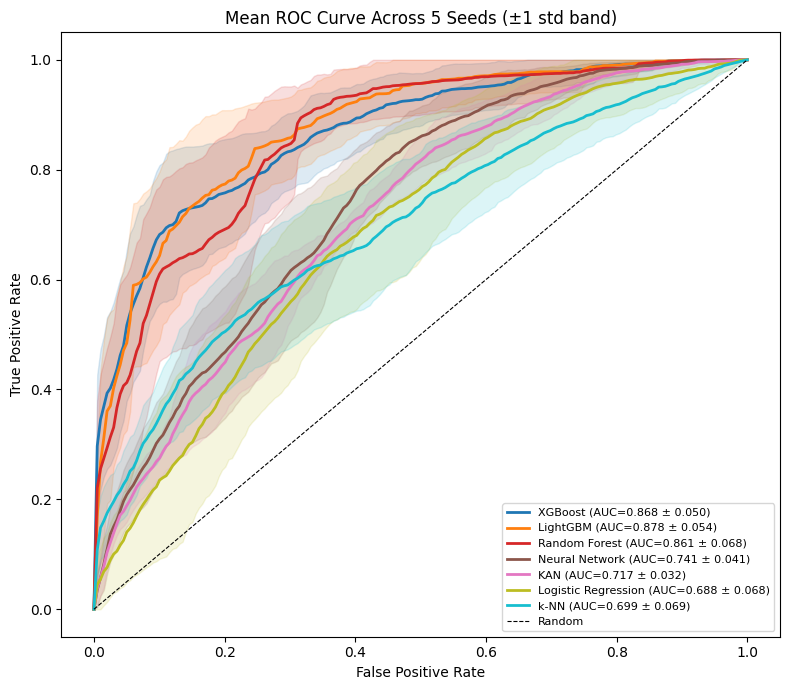

Saved: roc_multiseed_mean.png


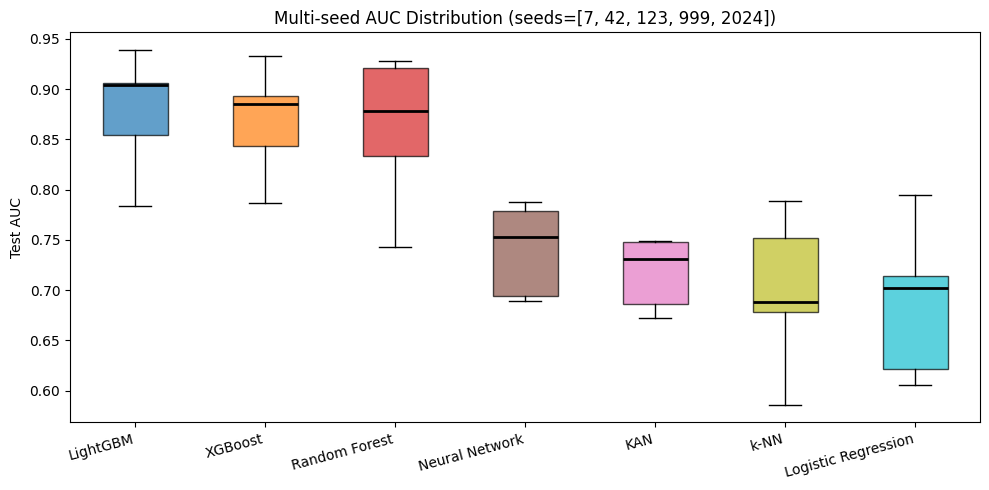

Saved: multiseed_auc_boxplot.png


In [ ]:

# ================================================================
# MULTI-SEED ROC/AUC CURVE
# ================================================================
mean_fpr = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(8, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(model_names_list)))

for m, color in zip(model_names_list, colors):
    tprs, aucs = [], []
    for fpr, tpr, auc_val in roc_curves_all_seeds[m]:
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(auc_val)
    tprs = np.array(tprs)
    mean_tpr = tprs.mean(axis=0); mean_tpr[-1] = 1.0
    std_tpr  = tprs.std(axis=0)
    mean_auc, std_auc = np.mean(aucs), np.std(aucs)

    ax.plot(mean_fpr, mean_tpr, color=color, lw=2,
            label=f"{m} (AUC={mean_auc:.3f} ± {std_auc:.3f})")
    ax.fill_between(mean_fpr, np.clip(mean_tpr - std_tpr, 0, 1),
                     np.clip(mean_tpr + std_tpr, 0, 1), color=color, alpha=0.15)

ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random')
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title(f"Mean ROC Curve Across {len(SEEDS)} Seeds (±1 std band)")
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.savefig("roc_multiseed_mean.png", dpi=150); plt.show()
print("Saved: roc_multiseed_mean.png")

ranked_models = multiseed_summary_df['Model'].tolist()
fig, ax = plt.subplots(figsize=(10, 5))
auc_data = [auc_scores[m] for m in ranked_models]
bp = ax.boxplot(auc_data, patch_artist=True, notch=False, medianprops=dict(color='black', lw=2))
bp_colors = plt.cm.tab10(np.linspace(0, 1, len(ranked_models)))
for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticks(range(1, len(ranked_models) + 1))
ax.set_xticklabels(ranked_models, rotation=15, ha='right')
ax.set_ylabel("Test AUC")
ax.set_title(f"Multi-seed AUC Distribution (seeds={SEEDS})")
plt.tight_layout(); plt.savefig("multiseed_auc_boxplot.png", dpi=150); plt.show()
print("Saved: multiseed_auc_boxplot.png")

In [ ]:
# ================================================================
# WILCOXON SIGN TEST — SEED LEVEL: XGBoost vs LightGBM, by OOF AUC
# ================================================================
from scipy.stats import binomtest

print(f"\n{'='*80}")
print("XGBoost vs LightGBM — Sign Test on OOF AUC (seed level)")
print(f"{'='*80}")

seed_auc_win_counts = {'XGBoost': 0, 'LightGBM': 0, 'Tie': 0}
seed_auc_rows = []

for seed in SEEDS:
    bundle = trained_models_by_seed[seed]
    y_tr        = bundle['y_train']
    oof_xgb     = bundle['xgb_oof_prob']
    oof_lgb     = bundle['lgb_oof_prob']

    auc_xgb = roc_auc_score(y_tr, oof_xgb) if len(np.unique(y_tr)) >= 2 else np.nan
    auc_lgb = roc_auc_score(y_tr, oof_lgb) if len(np.unique(y_tr)) >= 2 else np.nan

    if np.isfinite(auc_xgb) and np.isfinite(auc_lgb):
        if auc_xgb > auc_lgb:
            winner = 'XGBoost'
        elif auc_lgb > auc_xgb:
            winner = 'LightGBM'
        else:
            winner = 'Tie'
        seed_auc_win_counts[winner] += 1
    else:
        winner = 'N/A (one class only)'

    print(f"  Seed {seed}: XGB OOF AUC={auc_xgb:.4f}  LGB OOF AUC={auc_lgb:.4f}  "
          f"-> winner={winner}")

    seed_auc_rows.append({
        'Seed': seed, 'XGB OOF AUC': auc_xgb, 'LGB OOF AUC': auc_lgb, 'Winner': winner
    })

decisive_seeds = seed_auc_win_counts['XGBoost'] + seed_auc_win_counts['LightGBM']
print(f"\nSeed win counts (by OOF AUC): XGBoost={seed_auc_win_counts['XGBoost']}  "
      f"LightGBM={seed_auc_win_counts['LightGBM']}  Tie={seed_auc_win_counts['Tie']}  "
      f"(out of {len(SEEDS)} seeds)")

if decisive_seeds > 0:
    sign_result_seed = binomtest(
        max(seed_auc_win_counts['XGBoost'], seed_auc_win_counts['LightGBM']),
        n=decisive_seeds, p=0.5, alternative='two-sided'
    )
    leader_seed = 'XGBoost' if seed_auc_win_counts['XGBoost'] >= seed_auc_win_counts['LightGBM'] else 'LightGBM'
    print(f"  {leader_seed} won {max(seed_auc_win_counts['XGBoost'], seed_auc_win_counts['LightGBM'])}/"
          f"{decisive_seeds} decisive seeds -> p={sign_result_seed.pvalue:.4g}  "
          f"{'sig (p<0.05)' if sign_result_seed.pvalue < 0.05 else 'not sig'}")
else:
    sign_result_seed = None
    print("  Sign test skipped — no decisive (non-tied) seeds.")

seed_auc_df = pd.DataFrame(seed_auc_rows)
seed_auc_df.to_csv("sign_test_xgb_vs_lgb_seed_level.csv", index=False)
print("\nSaved: sign_test_xgb_vs_lgb_seed_level.csv")


XGBoost vs LightGBM — Sign Test on OOF AUC (seed level)
  Seed 7: XGB OOF AUC=0.9017  LGB OOF AUC=0.8742  -> winner=XGBoost
  Seed 42: XGB OOF AUC=0.8655  LGB OOF AUC=0.8492  -> winner=XGBoost
  Seed 123: XGB OOF AUC=0.8717  LGB OOF AUC=0.8675  -> winner=XGBoost
  Seed 999: XGB OOF AUC=0.9322  LGB OOF AUC=0.9410  -> winner=LightGBM
  Seed 2024: XGB OOF AUC=0.8413  LGB OOF AUC=0.8343  -> winner=XGBoost

Seed win counts (by OOF AUC): XGBoost=4  LightGBM=1  Tie=0  (out of 5 seeds)
  XGBoost won 4/5 decisive seeds -> p=0.375  not sig

Saved: sign_test_xgb_vs_lgb_seed_level.csv


In [ ]:
# ================================================================
# ABLATION STUDY SETUP
# ================================================================

ablation_seed = SEEDS[-1]

X_train_fa    = X_train_final
y_train_a     = y_train
X_test_fa     = X_test_final
y_test_a      = y_test

X_train_df_a  = X_train_df
X_test_df_a   = X_test_df

scale_pos_a   = scale_pos
groups_train_a = groups_train

sgkf_abl = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=ablation_seed)

grid_train_a = df.loc[X_train.index, 'grid_size'].reset_index(drop=True)
pde_train_a  = df.loc[X_train.index, 'pde_type'].reset_index(drop=True)

print(f"Ablation study will run using seed={ablation_seed} "
      f"(last seed in {SEEDS}), Boruta features={len(final_features)}")

Ablation study will run using seed=2024 (last seed in [7, 42, 123, 999, 2024]), Boruta features=36



ABLATION STUDY (XGBoost + LightGBM)

Feature groups identified:
  Diagonal       :   8 features — ['diag_min', 'diag_max', 'diag_mean', 'diag_std']...
  Norm           :   3 features — ['matrix_1norm', 'matrix_infnorm', 'norm_ratio_1_inf']
  Symmetry       :   1 features — ['symmetry_measure']
  Sparsity       :   4 features — ['avg_nnz_row', 'max_row_nnz', 'nnz_std', 'sparsity_entropy']
  Bandwidth      :   2 features — ['bandwidth', 'bandwidth_ratio']
  Spectral       :   3 features — ['gersh_radius_max', 'gersh_radius_mean', 'gersh_radius_std']
  Other          :  15 features — ['gersh_origin_overlap_pct', 'gersh_min_gap', 'row_sum_min', 'row_sum_max']...

Baseline AUC (XGBoost, 36 features): 0.8917

Baseline AUC (LightGBM, 36 features): 0.9459

────────────────────────────────────────────────────────────
ABLATION 1 — Feature Group Removal (XGBoost + LightGBM)
────────────────────────────────────────────────────────────
  [XGBoost] Remove Diagonal        ( 8 feats removed) -> AUC=0

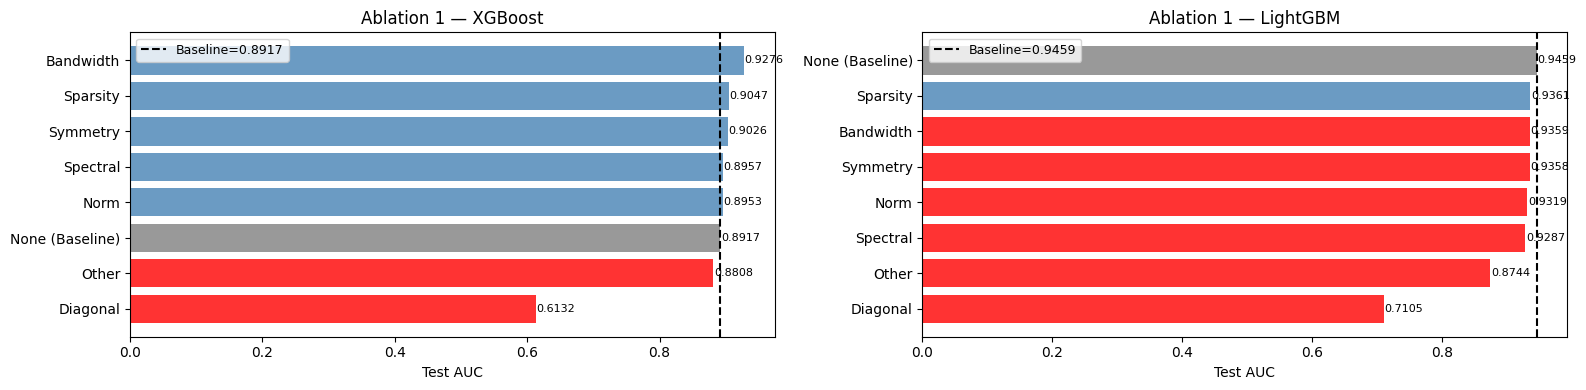

Saved: ablation_feature_groups.png

────────────────────────────────────────────────────────────
ABLATION 2 — Leave-One-Feature-Out (XGBoost + LightGBM)
────────────────────────────────────────────────────────────

[XGBoost] Top 15 most important features (by AUC drop when removed):
  Model            Feature  Test AUC  AUC Drop
XGBoost avg_diag_dominance    0.8860    0.0057
XGBoost        row_sum_max    0.8877    0.0040
XGBoost           diag_min    0.8879    0.0039
XGBoost         diag_ratio    0.8918   -0.0000
XGBoost        max_row_nnz    0.8949   -0.0032
XGBoost            nnz_std    0.8949   -0.0032
XGBoost          bandwidth    0.8949   -0.0032
XGBoost    bandwidth_ratio    0.8949   -0.0032
XGBoost   sparsity_entropy    0.8949   -0.0032
XGBoost        avg_nnz_row    0.8957   -0.0040
XGBoost     off_diag_decay    0.8998   -0.0081
XGBoost   gersh_radius_max    0.9014   -0.0097
XGBoost  gersh_radius_mean    0.9020   -0.0103
XGBoost   norm_ratio_1_inf    0.9026   -0.0108
XGBoost   s

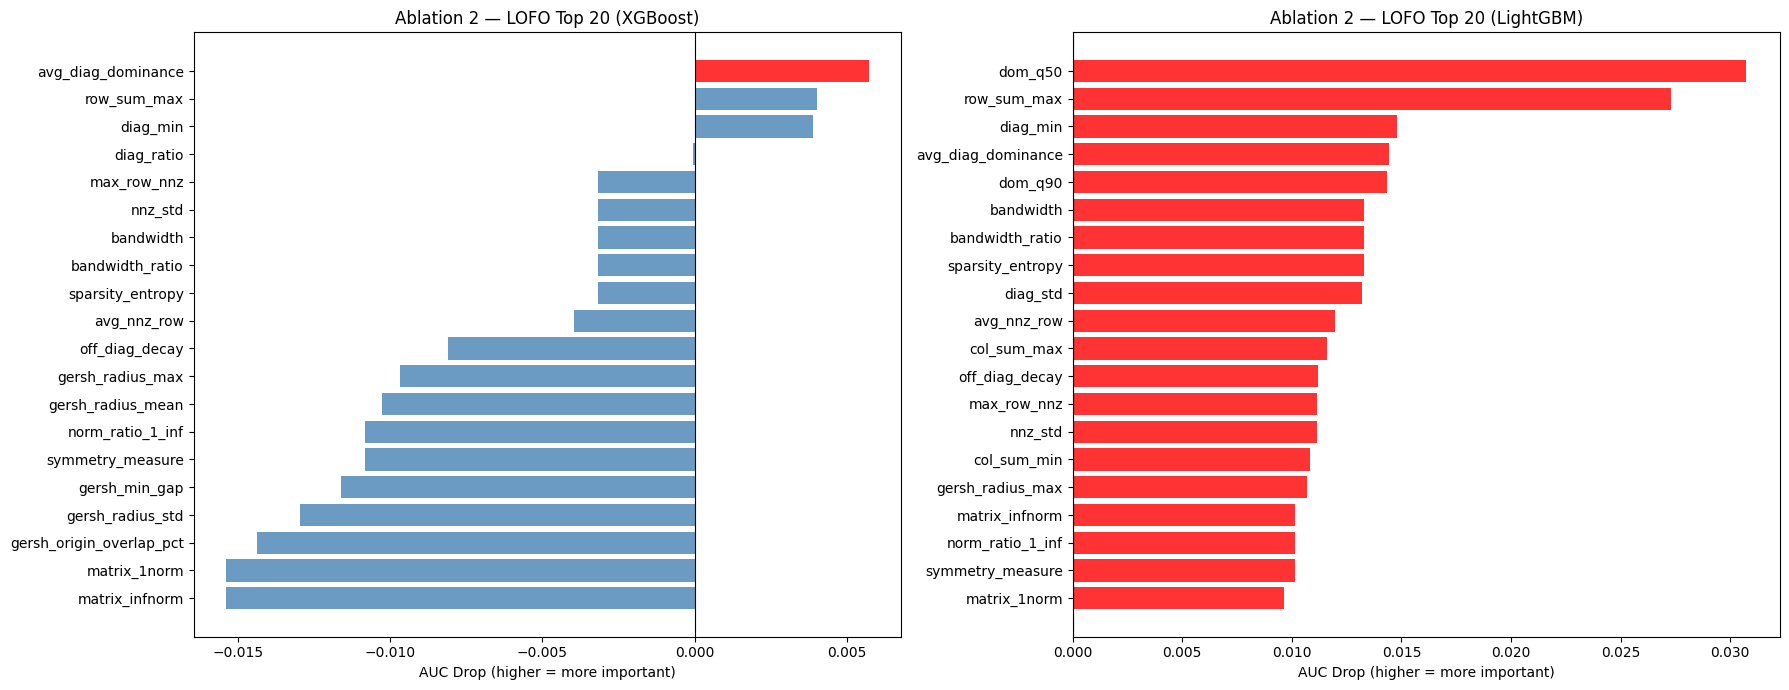

Saved: ablation_lofo.png

────────────────────────────────────────────────────────────
ABLATION 3 — Model Component Ablation (XGBoost + LightGBM)
────────────────────────────────────────────────────────────

  [XGBoost] Full pipeline            AUC=0.8917
  [XGBoost] Without Boruta           AUC=0.8917  Drop=+0.0000  (used 36 features vs 36)
  [XGBoost] Without class balancing  AUC=0.8807  Drop=+0.0111
  [XGBoost] Threshold=0.5 vs Robust  F1=0.6890 vs F1=0.6925  (AUC unchanged=0.8917, robust thresh=0.4485)
  [XGBoost] Without Optuna tuning    AUC=0.8905  Drop=+0.0012

  [LightGBM] Full pipeline            AUC=0.9459
  [LightGBM] Without Boruta           AUC=0.9459  Drop=+0.0000  (used 36 features vs 36)
  [LightGBM] Without class balancing  AUC=0.9417  Drop=+0.0043
  [LightGBM] Threshold=0.5 vs Robust  F1=0.7745 vs F1=0.6729  (AUC unchanged=0.9459, robust thresh=0.6545)
  [LightGBM] Without Optuna tuning    AUC=0.9206  Drop=+0.0253

Ablation 3 Summary:
   Model                         

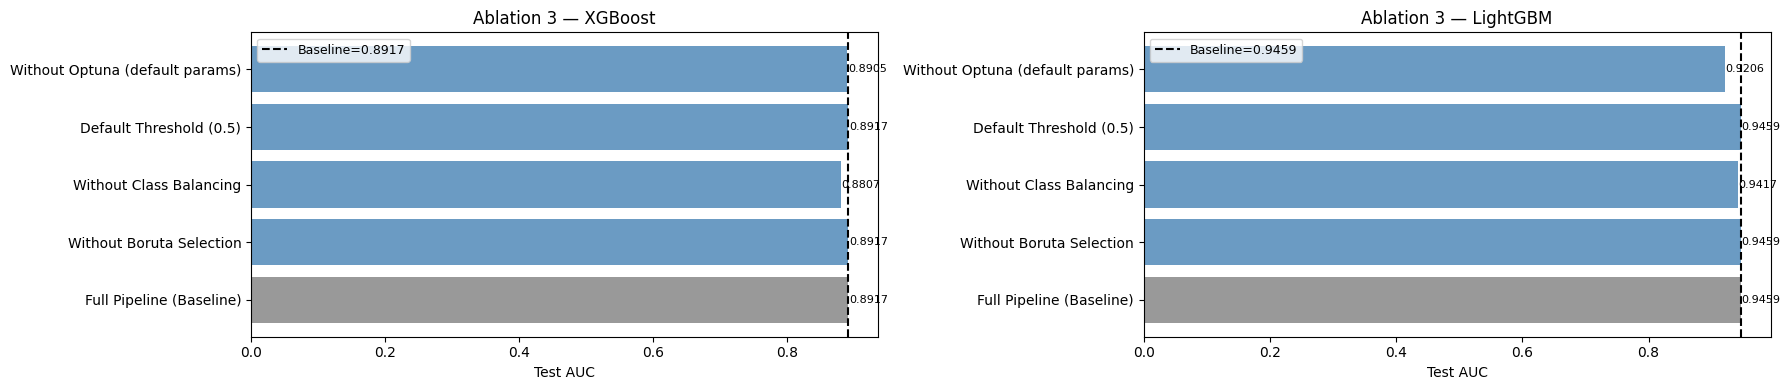

Saved: ablation_components.png

────────────────────────────────────────────────────────────
ABLATION 4 — Training Size Ablation (XGBoost + LightGBM)
────────────────────────────────────────────────────────────
  Ablation training set spans 8 distinct groups (5721 rows total)
  [XGBoost] Fraction=0.10  Groups used=1/8  N=  669  AUC=0.5000
  [XGBoost] Fraction=0.20  Groups used=2/8  N= 1453  AUC=0.5000
  [XGBoost] Fraction=0.30  Groups used=2/8  N= 1438  AUC=0.5000
  [XGBoost] Fraction=0.50  Groups used=4/8  N= 2893  AUC=0.8220
  [XGBoost] Fraction=0.70  Groups used=6/8  N= 4355  AUC=0.8555
  [XGBoost] Fraction=0.85  Groups used=7/8  N= 5034  AUC=0.8648
  [XGBoost] Fraction=1.00  Groups used=8/8  N= 5721  AUC=0.8917
  [LightGBM] Fraction=0.10  Groups used=1/8  N=  687  AUC=0.8292
  [LightGBM] Fraction=0.20  Groups used=2/8  N= 1366  AUC=0.9092
  [LightGBM] Fraction=0.30  Groups used=2/8  N= 1372  AUC=0.9172
  [LightGBM] Fraction=0.50  Groups used=4/8  N= 2830  AUC=0.9288
  [LightGBM] Fr

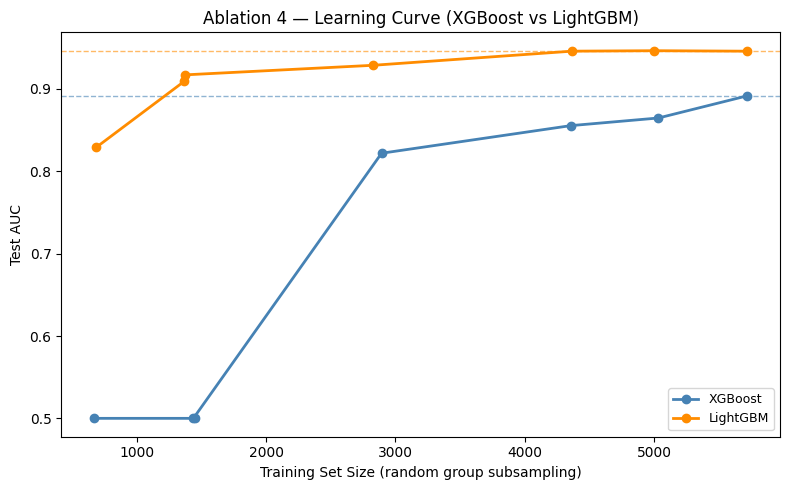

Saved: ablation_train_size.png

ABLATION STUDY COMPLETE (XGBoost + LightGBM)
Files saved:
  ablation_feature_groups.csv / .png
  ablation_lofo.csv / .png
  ablation_components.csv / .png
  ablation_train_size.csv / .png


In [ ]:
# ================================================================
# ABLATION STUDY — XGBoost AND LightGBM
# ================================================================
print(f"\n{'='*70}")
print("ABLATION STUDY (XGBoost + LightGBM)")
print(f"{'='*70}")

def run_model_auc(model_type, X_tr, y_tr, X_te, y_te, sp, seed_local):
    if model_type == 'xgb':
        m = xgb.XGBClassifier(
            **best_xgb_clf_params, scale_pos_weight=sp,
            eval_metric='logloss', random_state=seed_local, n_jobs=-1, verbosity=0
        )
    elif model_type == 'lgb':
        m = lgb.LGBMClassifier(
            **best_lgb_clf_params, class_weight='balanced',
            random_state=seed_local, n_jobs=-1, verbose=-1
        )
    else:
        raise ValueError(f"Unknown model_type: {model_type}")
    m.fit(X_tr, y_tr)
    prob = m.predict_proba(X_te)[:, 1]
    return roc_auc_score(y_te, prob)

ABLATION_MODELS = ['xgb', 'lgb']
ABLATION_MODEL_NAMES = {'xgb': 'XGBoost', 'lgb': 'LightGBM'}

feature_groups = {}
for f in final_features:
    f_lower = f.lower()
    if any(k in f_lower for k in ['spectral', 'eigen', 'radius']):
        feature_groups.setdefault('Spectral', []).append(f)
    elif any(k in f_lower for k in ['diag', 'diagonal', 'pivot']):
        feature_groups.setdefault('Diagonal', []).append(f)
    elif any(k in f_lower for k in ['norm', 'fro']):
        feature_groups.setdefault('Norm', []).append(f)
    elif any(k in f_lower for k in ['spars', 'nnz', 'density']):
        feature_groups.setdefault('Sparsity', []).append(f)
    elif any(k in f_lower for k in ['band', 'width']):
        feature_groups.setdefault('Bandwidth', []).append(f)
    elif any(k in f_lower for k in ['symm', 'skew']):
        feature_groups.setdefault('Symmetry', []).append(f)
    else:
        feature_groups.setdefault('Other', []).append(f)

print("\nFeature groups identified:")
for grp, feats in feature_groups.items():
    print(f"  {grp:<15}: {len(feats):>3} features — {feats[:4]}{'...' if len(feats)>4 else ''}")

baseline_auc = {}
for model_type in ABLATION_MODELS:
    baseline_auc[model_type] = run_model_auc(
        model_type, X_train_fa, y_train_a, X_test_fa, y_test_a, scale_pos_a, ablation_seed
    )
    print(f"\nBaseline AUC ({ABLATION_MODEL_NAMES[model_type]}, "
          f"{len(final_features)} features): {baseline_auc[model_type]:.4f}")

# ================================================================
# ABLATION 1 — FEATURE GROUP REMOVAL (both models)
# ================================================================
print(f"\n{'─'*60}")
print("ABLATION 1 — Feature Group Removal (XGBoost + LightGBM)")
print(f"{'─'*60}")

ablation1_rows = []
for model_type in ABLATION_MODELS:
    mname = ABLATION_MODEL_NAMES[model_type]
    ablation1_rows.append({
        'Model': mname, 'Removed Group': 'None (Baseline)',
        'Features Removed': 0, 'Features Remaining': len(final_features),
        'Test AUC': baseline_auc[model_type], 'AUC Drop': 0.0
    })
    for grp, grp_feats in feature_groups.items():
        remaining = [f for f in final_features if f not in grp_feats]
        if len(remaining) == 0:
            print(f"  [{mname}] Skipping {grp} — would remove all features")
            continue
        auc = run_model_auc(
            model_type, X_train_fa[remaining], y_train_a,
            X_test_fa[remaining], y_test_a, scale_pos_a, ablation_seed
        )
        drop = baseline_auc[model_type] - auc
        print(f"  [{mname}] Remove {grp:<15} ({len(grp_feats):>2} feats removed) -> "
              f"AUC={auc:.4f}  Drop={drop:+.4f}")
        ablation1_rows.append({
            'Model': mname, 'Removed Group': grp,
            'Features Removed': len(grp_feats), 'Features Remaining': len(remaining),
            'Test AUC': auc, 'AUC Drop': drop
        })

ablation1_df = pd.DataFrame(ablation1_rows).sort_values(['Model', 'AUC Drop'], ascending=[True, False])
ablation1_df.to_csv("ablation_feature_groups.csv", index=False)
print("\nAblation 1 Summary:")
print(ablation1_df.to_string(index=False, float_format='{:.4f}'.format))
print("Saved: ablation_feature_groups.csv")

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=False)
for ax, model_type in zip(axes, ABLATION_MODELS):
    mname = ABLATION_MODEL_NAMES[model_type]
    sub = ablation1_df[ablation1_df['Model'] == mname]
    colors_abl = ['grey' if r == 'None (Baseline)' else
                  ('red' if d > 0.01 else 'steelblue')
                  for r, d in zip(sub['Removed Group'], sub['AUC Drop'])]
    bars = ax.barh(sub['Removed Group'], sub['Test AUC'], color=colors_abl, alpha=0.8)
    ax.axvline(baseline_auc[model_type], color='black', linestyle='--', lw=1.5,
               label=f'Baseline={baseline_auc[model_type]:.4f}')
    ax.set_xlabel("Test AUC")
    ax.set_title(f"Ablation 1 — {mname}")
    ax.legend(fontsize=9)
    for bar, val in zip(bars, sub['Test AUC']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("ablation_feature_groups.png", dpi=150)
plt.show()
print("Saved: ablation_feature_groups.png")

# ================================================================
# ABLATION 2 — LEAVE-ONE-FEATURE-OUT (both models)
# ================================================================
print(f"\n{'─'*60}")
print("ABLATION 2 — Leave-One-Feature-Out (XGBoost + LightGBM)")
print(f"{'─'*60}")

lofo_rows = []
for model_type in ABLATION_MODELS:
    mname = ABLATION_MODEL_NAMES[model_type]
    for feat in final_features:
        remaining = [f for f in final_features if f != feat]
        auc = run_model_auc(
            model_type, X_train_fa[remaining], y_train_a,
            X_test_fa[remaining], y_test_a, scale_pos_a, ablation_seed
        )
        drop = baseline_auc[model_type] - auc
        lofo_rows.append({'Model': mname, 'Feature': feat, 'Test AUC': auc, 'AUC Drop': drop})

lofo_df = pd.DataFrame(lofo_rows).sort_values(['Model', 'AUC Drop'], ascending=[True, False]).reset_index(drop=True)
lofo_df.to_csv("ablation_lofo.csv", index=False)

for model_type in ABLATION_MODELS:
    mname = ABLATION_MODEL_NAMES[model_type]
    sub = lofo_df[lofo_df['Model'] == mname]
    print(f"\n[{mname}] Top 15 most important features (by AUC drop when removed):")
    print(sub.head(15).to_string(index=False, float_format='{:.4f}'.format))
print("Saved: ablation_lofo.csv")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, model_type in zip(axes, ABLATION_MODELS):
    mname = ABLATION_MODEL_NAMES[model_type]
    top20 = lofo_df[lofo_df['Model'] == mname].head(20)
    colors_lofo = ['red' if d > 0.005 else 'steelblue' for d in top20['AUC Drop']]
    ax.barh(top20['Feature'][::-1], top20['AUC Drop'][::-1], color=colors_lofo[::-1], alpha=0.8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel("AUC Drop (higher = more important)")
    ax.set_title(f"Ablation 2 — LOFO Top 20 ({mname})")
plt.tight_layout()
plt.savefig("ablation_lofo.png", dpi=150)
plt.show()
print("Saved: ablation_lofo.png")

# ================================================================
# ABLATION 3 — MODEL COMPONENT ABLATION (both models)
# ================================================================
print(f"\n{'─'*60}")
print("ABLATION 3 — Model Component Ablation (XGBoost + LightGBM)")
print(f"{'─'*60}")

all_features = X_train_df_a.columns.tolist()
ablation3_rows = []

for model_type in ABLATION_MODELS:
    mname = ABLATION_MODEL_NAMES[model_type]
    auc_full = baseline_auc[model_type]
    ablation3_rows.append({'Model': mname, 'Config': 'Full Pipeline (Baseline)',
                            'Test AUC': auc_full, 'Note': ''})
    print(f"\n  [{mname}] Full pipeline            AUC={auc_full:.4f}")

    # Without Boruta selection
    if model_type == 'xgb':
        m_no_boruta = xgb.XGBClassifier(
            **best_xgb_clf_params, scale_pos_weight=scale_pos_a,
            eval_metric='logloss', random_state=ablation_seed, n_jobs=-1, verbosity=0
        )
    else:
        m_no_boruta = lgb.LGBMClassifier(
            **best_lgb_clf_params, class_weight='balanced',
            random_state=ablation_seed, n_jobs=-1, verbose=-1
        )
    m_no_boruta.fit(X_train_df_a[all_features], y_train_a)
    prob_nb = m_no_boruta.predict_proba(X_test_df_a[all_features])[:, 1]
    auc_nb = roc_auc_score(y_test_a, prob_nb)
    drop_nb = auc_full - auc_nb
    ablation3_rows.append({'Model': mname, 'Config': 'Without Boruta Selection',
                            'Test AUC': auc_nb, 'Note': f'All {len(all_features)} features'})
    print(f"  [{mname}] Without Boruta           AUC={auc_nb:.4f}  Drop={drop_nb:+.4f}  "
          f"(used {len(all_features)} features vs {len(final_features)})")

    # Without class balancing
    if model_type == 'xgb':
        m_no_bal = xgb.XGBClassifier(
            **best_xgb_clf_params, scale_pos_weight=1.0,
            eval_metric='logloss', random_state=ablation_seed, n_jobs=-1, verbosity=0
        )
    else:
        m_no_bal = lgb.LGBMClassifier(
            **best_lgb_clf_params, class_weight=None,
            random_state=ablation_seed, n_jobs=-1, verbose=-1
        )
    m_no_bal.fit(X_train_fa, y_train_a)
    prob_nbal = m_no_bal.predict_proba(X_test_fa)[:, 1]
    auc_nbal = roc_auc_score(y_test_a, prob_nbal)
    drop_nbal = auc_full - auc_nbal
    ablation3_rows.append({'Model': mname, 'Config': 'Without Class Balancing',
                            'Test AUC': auc_nbal,
                            'Note': 'scale_pos_weight=1' if model_type == 'xgb' else 'class_weight=None'})
    print(f"  [{mname}] Without class balancing  AUC={auc_nbal:.4f}  Drop={drop_nbal:+.4f}")

    # Threshold sensitivity (0.5 vs robust threshold)
    if model_type == 'xgb':
        m_baseline = xgb.XGBClassifier(
            **best_xgb_clf_params, scale_pos_weight=scale_pos_a,
            eval_metric='logloss', random_state=ablation_seed, n_jobs=-1, verbosity=0
        )
    else:
        m_baseline = lgb.LGBMClassifier(
            **best_lgb_clf_params, class_weight='balanced',
            random_state=ablation_seed, n_jobs=-1, verbose=-1
        )
    oof_prob_abl = cross_val_predict(m_baseline, X_train_fa, y_train_a, groups=groups_train_a,
                                      cv=sgkf_abl, method='predict_proba', n_jobs=-1)[:, 1]
    youden_thresh_abl = best_threshold_youden(y_train_a, oof_prob_abl)
    m_baseline.fit(X_train_fa, y_train_a)
    prob_full = m_baseline.predict_proba(X_test_fa)[:, 1]
    pred_05 = (prob_full >= 0.5).astype(int)
    pred_youden = (prob_full >= youden_thresh_abl).astype(int)
    f1_05 = f1_score(y_test_a, pred_05, zero_division=0)
    f1_youden = f1_score(y_test_a, pred_youden, zero_division=0)
    auc_same = roc_auc_score(y_test_a, prob_full)
    print(f"  [{mname}] Threshold=0.5 vs Robust  F1={f1_05:.4f} vs F1={f1_youden:.4f}  "
          f"(AUC unchanged={auc_same:.4f}, robust thresh={youden_thresh_abl:.4f})")
    ablation3_rows.append({'Model': mname, 'Config': 'Default Threshold (0.5)',
                            'Test AUC': auc_same,
                            'Note': f'F1={f1_05:.4f} vs Robust-threshold F1={f1_youden:.4f}'})

    # Without Optuna tuning (default hyperparameters)
    if model_type == 'xgb':
        m_default = xgb.XGBClassifier(
            n_estimators=100, scale_pos_weight=scale_pos_a,
            eval_metric='logloss', random_state=ablation_seed, n_jobs=-1, verbosity=0
        )
    else:
        m_default = lgb.LGBMClassifier(
            n_estimators=100, class_weight='balanced',
            random_state=ablation_seed, n_jobs=-1, verbose=-1
        )
    m_default.fit(X_train_fa, y_train_a)
    prob_def = m_default.predict_proba(X_test_fa)[:, 1]
    auc_def = roc_auc_score(y_test_a, prob_def)
    drop_def = auc_full - auc_def
    ablation3_rows.append({'Model': mname, 'Config': 'Without Optuna (default params)',
                            'Test AUC': auc_def, 'Note': 'n_estimators=100, all defaults'})
    print(f"  [{mname}] Without Optuna tuning    AUC={auc_def:.4f}  Drop={drop_def:+.4f}")

ablation3_df = pd.DataFrame(ablation3_rows)
ablation3_df.to_csv("ablation_components.csv", index=False)
print("\nAblation 3 Summary:")
print(ablation3_df.to_string(index=False, float_format='{:.4f}'.format))
print("Saved: ablation_components.csv")

fig, axes = plt.subplots(1, 2, figsize=(18, 4))
for ax, model_type in zip(axes, ABLATION_MODELS):
    mname = ABLATION_MODEL_NAMES[model_type]
    sub = ablation3_df[ablation3_df['Model'] == mname]
    bar_colors = ['grey' if 'Baseline' in c else 'steelblue' for c in sub['Config']]
    bars = ax.barh(sub['Config'], sub['Test AUC'], color=bar_colors, alpha=0.8)
    ax.axvline(baseline_auc[model_type], color='black', linestyle='--', lw=1.5,
               label=f'Baseline={baseline_auc[model_type]:.4f}')
    ax.set_xlabel("Test AUC")
    ax.set_title(f"Ablation 3 — {mname}")
    ax.legend(fontsize=9)
    for bar, val in zip(bars, sub['Test AUC']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("ablation_components.png", dpi=150)
plt.show()
print("Saved: ablation_components.png")

# ================================================================
# ABLATION 4 — TRAINING SIZE ABLATION (both models)
# ================================================================
print(f"\n{'─'*60}")
print("ABLATION 4 — Training Size Ablation (XGBoost + LightGBM)")
print(f"{'─'*60}")

group_series = grid_train_a

unique_groups_a = group_series.unique()
n_total_groups = len(unique_groups_a)
print(f"  Ablation training set spans {n_total_groups} distinct groups "
      f"({len(X_train_fa)} rows total)")

fractions = [0.1, 0.2, 0.3, 0.5, 0.7, 0.85, 1.0]
size_rows = []
rng_size = np.random.RandomState(ablation_seed)

for model_type in ABLATION_MODELS:
    mname = ABLATION_MODEL_NAMES[model_type]
    for frac in fractions:
        if frac >= 1.0:
            chosen_groups = unique_groups_a
            sub_idx = np.arange(len(X_train_fa))
        else:
            n_groups_wanted = max(1, int(round(frac * n_total_groups)))
            chosen_groups = rng_size.choice(unique_groups_a, size=n_groups_wanted, replace=False)
            sub_mask = group_series.isin(chosen_groups).values
            sub_idx = np.where(sub_mask)[0]

        X_tr_sub = X_train_fa.iloc[sub_idx]
        y_tr_sub = y_train_a.iloc[sub_idx]

        if y_tr_sub.nunique() < 2:
            print(f"  [{mname}] Fraction={frac:.2f}  skipped (only one class present)")
            continue

        sp_sub = (y_tr_sub == 0).sum() / max((y_tr_sub == 1).sum(), 1)
        auc_sub = run_model_auc(model_type, X_tr_sub, y_tr_sub, X_test_fa, y_test_a, sp_sub, ablation_seed)
        n_used = len(X_tr_sub)
        print(f"  [{mname}] Fraction={frac:.2f}  Groups used={len(chosen_groups)}/{n_total_groups}  "
              f"N={n_used:>5}  AUC={auc_sub:.4f}")
        size_rows.append({'Model': mname, 'Train Fraction': frac,
                           'Groups Used': len(chosen_groups), 'Total Groups': n_total_groups,
                           'Train Size': n_used, 'Test AUC': auc_sub})

size_df = pd.DataFrame(size_rows)
size_df.to_csv("ablation_train_size.csv", index=False)
print("Saved: ablation_train_size.csv")

fig, ax = plt.subplots(figsize=(8, 5))
for model_type, color in zip(ABLATION_MODELS, ['steelblue', 'darkorange']):
    mname = ABLATION_MODEL_NAMES[model_type]
    sub = size_df[size_df['Model'] == mname]
    ax.plot(sub['Train Size'], sub['Test AUC'], marker='o', color=color, lw=2, label=mname)
    ax.axhline(baseline_auc[model_type], color=color, linestyle='--', lw=1, alpha=0.6)
ax.set_xlabel("Training Set Size (random group subsampling)")
ax.set_ylabel("Test AUC")
ax.set_title("Ablation 4 — Learning Curve (XGBoost vs LightGBM)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("ablation_train_size.png", dpi=150)
plt.show()
print("Saved: ablation_train_size.png")

print(f"\n{'='*70}")
print("ABLATION STUDY COMPLETE (XGBoost + LightGBM)")
print("Files saved:")
print("  ablation_feature_groups.csv / .png")
print("  ablation_lofo.csv / .png")
print("  ablation_components.csv / .png")
print("  ablation_train_size.csv / .png")
print(f"{'='*70}")

In [ ]:
# ================================================================
# EXTERNAL VALIDATION
# ================================================================
import shutil
shutil.rmtree("./suitesparse_cache_pde", ignore_errors=True)
from scipy.sparse.linalg import splu, gmres
from scipy.sparse import eye

COND_THRESHOLD_LOG10 = 7.0
COND_MARGIN_LOG10    = 0.75

SUITESPARSE_MATRICES = []

for i in range(1, 39):
    SUITESPARSE_MATRICES.append(("HB", f"bcsstk{i:02d}"))

for i in range(1, 28):
    SUITESPARSE_MATRICES.append(("HB", f"bcsstm{i:02d}"))

for i in range(1, 41):
    SUITESPARSE_MATRICES.append(("FIDAP", f"ex{i}"))

SUITESPARSE_MATRICES += [
    ("Nasa", "nasa1824"), ("Nasa", "nasa2146"), ("Nasa", "nasa2910"), ("Nasa", "nasa4704"),
]

SUITESPARSE_MATRICES += [
    ("Boeing", "msc00726"), ("Boeing", "msc01050"), ("Boeing", "msc04515"),
    ("Boeing", "msc10848"), ("Boeing", "msc23052"),
    ("Boeing", "crystm01"), ("Boeing", "crystm02"), ("Boeing", "crystm03"),
]

SUITESPARSE_MATRICES += [
    ("Botonakis", "thermal1"), ("Botonakis", "thermal2"),
]

SUITESPARSE_MATRICES += [
    ("Bai", "dw2048"), ("Bai", "dw4096"), ("Bai", "dw8192"),
    ("Bai", "olm500"), ("Bai", "olm1000"), ("Bai", "olm2000"), ("Bai", "olm5000"),
    ("Bai", "rdb200"), ("Bai", "rdb200l"), ("Bai", "rdb450"), ("Bai", "rdb450l"),
    ("Bai", "rdb968"), ("Bai", "rdb2048"), ("Bai", "rdb2048l"),
    ("Bai", "rdb3200l"), ("Bai", "rdb5000"),
]

SUITESPARSE_MATRICES += [
    ("Pothen", "barth"), ("Pothen", "barth4"), ("Pothen", "barth5"),
    ("Pothen", "bodyy4"), ("Pothen", "bodyy5"), ("Pothen", "bodyy6"),
    ("Pothen", "commanche_dual"),
    ("Pothen", "mesh1e1"), ("Pothen", "mesh1em1"), ("Pothen", "mesh1em6"),
    ("Pothen", "mesh2e1"), ("Pothen", "mesh2em5"),
    ("Pothen", "mesh3e1"), ("Pothen", "mesh3em5"),
    ("Pothen", "onera_dual"), ("Pothen", "shuttle_eddy"),
    ("Pothen", "tandem_dual"), ("Pothen", "tandem_vtx"),
]

SUITESPARSE_MATRICES += [
    ("Simon", "raefsky1"), ("Simon", "raefsky2"), ("Simon", "raefsky3"), ("Simon", "raefsky4"),
    ("Simon", "olafu"),
    ("Simon", "venkat01"), ("Simon", "venkat25"), ("Simon", "venkat50"),
]

SUITESPARSE_MATRICES += [
    ("Grund", "poli"), ("Grund", "poli3"), ("Grund", "poli4"),
    ("Grund", "bayer01"), ("Grund", "bayer02"), ("Grund", "bayer03"), ("Grund", "bayer04"),
    ("Grund", "bayer05"), ("Grund", "bayer06"), ("Grund", "bayer07"), ("Grund", "bayer08"),
    ("Grund", "bayer09"), ("Grund", "bayer10"),
]

SUITESPARSE_MATRICES += [
    ("HB", "1138_bus"), ("HB", "494_bus"), ("HB", "662_bus"), ("HB", "685_bus"),
    ("HB", "bcspwr01"), ("HB", "bcspwr02"), ("HB", "bcspwr03"), ("HB", "bcspwr04"),
    ("HB", "bcspwr05"), ("HB", "bcspwr06"), ("HB", "bcspwr07"), ("HB", "bcspwr08"),
    ("HB", "bcspwr09"), ("HB", "bcspwr10"),
    ("HB", "can_24"), ("HB", "can_61"), ("HB", "can_144"), ("HB", "can_161"),
    ("HB", "can_187"), ("HB", "can_229"), ("HB", "can_256"), ("HB", "can_268"),
    ("HB", "can_292"), ("HB", "can_445"), ("HB", "can_634"), ("HB", "can_715"),
    ("HB", "can_838"), ("HB", "can_1054"), ("HB", "can_1072"),
    ("HB", "arc130"),
    ("HB", "ash85"), ("HB", "ash219"), ("HB", "ash331"), ("HB", "ash608"), ("HB", "ash958"),
    ("HB", "steam1"), ("HB", "steam2"), ("HB", "steam3"),
    ("HB", "saylr1"), ("HB", "saylr3"), ("HB", "saylr4"),
    ("HB", "sherman1"), ("HB", "sherman2"), ("HB", "sherman3"),
    ("HB", "sherman4"), ("HB", "sherman5"),
    ("HB", "west0132"), ("HB", "west0156"), ("HB", "west0167"), ("HB", "west0381"),
    ("HB", "west0479"), ("HB", "west0655"), ("HB", "west0989"), ("HB", "west1505"),
    ("HB", "west2021"),
    ("HB", "gr_30_30"), ("HB", "gre_115"), ("HB", "gre_185"),
    ("HB", "gre_216a"), ("HB", "gre_216b"), ("HB", "gre_343"),
    ("HB", "gre_512"), ("HB", "gre_1107"),
]

print(f"Total SuiteSparse matrices queued for external validation: {len(SUITESPARSE_MATRICES)}")


def download_suitesparse_matrix(group, name, out_dir="./suitesparse_cache_pde"):
    import os
    matrix_dir = os.path.join(out_dir, f"{group}_{name}")
    os.makedirs(matrix_dir, exist_ok=True)
    try:
        results = ssgetpy.search(name=name, group=group)
        if len(results) == 0:
            print(f"  ⚠️  {group}/{name}: not found in SuiteSparse index — skipping")
            return None
        mat = results[0]
        mat.download(destpath=matrix_dir, extract=True)

        candidates = []
        for root, _, files in os.walk(matrix_dir):
            for f in files:
                if f.lower().endswith(".mtx"):
                    candidates.append(os.path.join(root, f))

        if not candidates:
            print(f"  ⚠️  {group}/{name}: no .mtx file found after extraction — skipping")
            return None
        candidates.sort(key=lambda p: (
            0 if os.path.basename(p).lower().startswith(name.lower()) else 1,
            -os.path.getsize(p)
        ))

        A = None
        for path in candidates:
            try:
                cand = mmread(path)
                cand = csr_matrix(cand, dtype=np.float64)
                if cand.shape[0] == cand.shape[1] and cand.shape[0] > 1:
                    A = cand
                    break
                else:
                    print(f"  ℹ️  {group}/{name}: skipped non-square candidate "
                          f"{os.path.basename(path)} shape={cand.shape}")
            except Exception:
                continue

        if A is None:
            print(f"  ⚠️  {group}/{name}: no square matrix found among "
                  f"{len(candidates)} .mtx candidate(s) — skipping")
            return None
        return A
    except Exception as e:
        print(f"  ⚠️  {group}/{name}: download/parse failed ({e}) — skipping")
        return None


def bandwidth_estimate(A):
    rows, cols = A.nonzero()
    return float(np.max(np.abs(rows - cols))) if len(rows) > 0 else 0.0

def sparsity_entropy(A):
    nnz_per_row = A.getnnz(axis=1)
    p = nnz_per_row.astype(float) / (nnz_per_row.sum() + 1e-12)
    p = p[p > 0]
    return -np.sum(p * np.log2(p + 1e-12)) if len(p) > 0 else 0.0

def off_diag_decay(A, rng, n_samples=100):
    N = A.shape[0]
    indptr, indices, data = A.indptr, A.indices, A.data
    rates = []
    n_draw = min(n_samples, N)
    idxs = rng.integers(0, N, size=n_draw)
    for i in idxs:
        start, end = indptr[i], indptr[i + 1]
        nnz = end - start
        if nnz > 3:
            row_idx = indices[start:end]
            row_val = data[start:end]
            dists = np.abs(row_idx - i)
            vals = np.abs(row_val)
            sorted_idx = dists.argsort()
            rates.append(np.mean(vals[sorted_idx][1:5]) /
                         (vals[sorted_idx[0]] + 1e-12))
    raw = np.mean(rates) if rates else 1.0
    return float(np.log1p(raw))

def gershgorin_features(diag, row_abs_sums):
    radii = row_abs_sums - np.abs(diag)
    return {
        "gersh_radius_max": float(radii.max()),
        "gersh_radius_mean": float(radii.mean()),
        "gersh_radius_std": float(radii.std()),
        "gersh_origin_overlap_pct": float(np.mean(radii >= np.abs(diag))),
        "gersh_min_gap": float(np.min(np.abs(diag) - radii)),
    }

def spectral_features(A, rng, diag, row_abs_sums, k=3):
    N = A.shape[0]
    result = {}
    try:
        Q = rng.standard_normal((N, k + 1))
        Q, _ = np.linalg.qr(Q)
        M_small = Q.T @ (A.T @ (A @ Q))
        eigs = np.sort(np.abs(np.linalg.eigvalsh(M_small)))[::-1]
        for i, e in enumerate(eigs[:k]):
            result[f"rayleigh_eig{i}"] = float(e)
    except Exception:
        for i in range(k):
            result[f"rayleigh_eig{i}"] = 0.0
    try:
        diag_abs = np.abs(diag)
        row_offdiag = row_abs_sums - diag_abs
        dominance = diag_abs - row_offdiag
        result["dom_q10"] = float(np.percentile(dominance, 10))
        result["dom_q50"] = float(np.percentile(dominance, 50))
        result["dom_q90"] = float(np.percentile(dominance, 90))
    except Exception:
        result["dom_q10"] = result["dom_q50"] = result["dom_q90"] = 0.0
    return result

def row_col_statistics(A, diag, row_abs_sums):
    row_sums = np.array(A.sum(axis=1)).flatten()
    col_sums = np.array(A.sum(axis=0)).flatten()
    off_diag_max = row_abs_sums - np.abs(diag)
    return {
        "row_sum_min": float(row_sums.min()),
        "row_sum_max": float(row_sums.max()),
        "row_sum_std": float(row_sums.std()),
        "col_sum_min": float(col_sums.min()),
        "col_sum_max": float(col_sums.max()),
        "col_sum_std": float(col_sums.std()),
        "avg_diag_dominance": float(np.mean(np.abs(diag) - off_diag_max)),
        "diag_dominant_ratio": float(np.mean(np.abs(diag) > off_diag_max)),
    }

def robust_smax(A, rng, n_iter=25):
    try:
        N = A.shape[0]
        x = rng.standard_normal(N)
        x /= np.linalg.norm(x) + 1e-12
        for _ in range(n_iter):
            x = A.T @ (A @ x)
            nrm = np.linalg.norm(x)
            if nrm < 1e-12:
                break
            x /= nrm
        smax = np.sqrt(max(np.dot(x, A.T @ (A @ x)), 0.0))
        return max(smax, 1e-6)
    except Exception:
        return np.sqrt(np.sum(A.data ** 2) + 1e-12)

def robust_smin(A, reg_shift=0.0, n_iter=15):
    try:
        N = A.shape[0]
        if not np.isfinite(A.data).all():
            return None
        fro = np.sqrt(np.sum(A.data ** 2))
        if fro > 1e30 or fro < 1e-30:
            scale = fro
            A_scaled = A * (1.0 / scale)
            smin_scaled = robust_smin(A_scaled, reg_shift / scale, n_iter)
            return smin_scaled * scale if smin_scaled is not None else None
        if reg_shift > 0:
            M = A.T @ A + (reg_shift ** 2) * eye(N, format="csr")
        else:
            M = A.T @ A
        lu = splu(M.tocsc(), permc_spec='COLAMD')
        x = np.ones(N, dtype=np.float64) / np.sqrt(N)
        for _ in range(n_iter):
            x = lu.solve(x)
            nrm = np.linalg.norm(x)
            if nrm < 1e-12:
                return None
            x /= nrm
        rq = np.dot(x, M @ x)
        shift_sq = reg_shift ** 2 if reg_shift > 0 else 0.0
        eigenval = max(rq - shift_sq, 1e-30)
        smin = np.sqrt(eigenval)
        return max(smin, 1e-15)
    except Exception:
        return None

def cond_estimate_lu(A, already_normalized=False, rng=None):
    try:
        N = A.shape[0]
        if not np.isfinite(A.data).all():
            return None
        if not already_normalized:
            fro = np.sqrt(np.sum(A.data ** 2))
            if fro < 1e-30 or fro > 1e30:
                return None
            A_scaled = A * (1.0 / fro)
        else:
            A_scaled = A
        norm_A = float(np.max(np.abs(A_scaled).sum(axis=0)))
        lu = splu(A_scaled.tocsc(), permc_spec='COLAMD')
        rng_p = rng if rng is not None else np.random.default_rng()
        est = 0.0
        for _ in range(6):
            e = rng_p.choice([-1.0, 1.0], size=N)
            x = lu.solve(e)
            est = max(est, np.linalg.norm(x, 1) / (np.linalg.norm(e, 1) + 1e-12))
        cond = norm_A * est
        return float(np.log10(max(cond, 1.0) + 1e-12))
    except Exception:
        return None

def gmres_decay_feature(A, N):
    b = np.ones(N, dtype=np.float64)
    residuals = []
    try:
        def cb(r):
            residuals.append(float(np.linalg.norm(r)) if hasattr(r, '__len__') else float(r))
        gmres(A, b, maxiter=8, callback=cb, callback_type='pr_norm', atol=1e-8)
    except Exception:
        pass
    if len(residuals) > 1:
        return float(np.clip(residuals[-1] / (residuals[0] + 1e-12), 0.0, 10.0))
    return 1.0


def compute_matrix_features(A_raw, seed):
    rng = np.random.default_rng(seed)
    A_raw = csr_matrix(A_raw, dtype=np.float64)
    N = A_raw.shape[0]

    fro = np.sqrt(np.sum(A_raw.data ** 2))
    if fro < 1e-30 or not np.isfinite(fro):
        return None, None
    A_norm = A_raw * (1.0 / fro)
    log10c = cond_estimate_lu(A_norm, already_normalized=True, rng=rng)
    if log10c is None:
        try:
            smax = robust_smax(A_norm, rng)
            smin = robust_smin(A_norm, 0.0)
            if smin is not None and smin > 1e-14:
                log10c = float(np.log10(smax / smin + 1e-12))
            else:
                return None, None
        except Exception:
            return None, None

    diag = A_norm.diagonal()
    fro_norm = np.sqrt(np.sum(A_norm.data ** 2) + 1e-12)

    abs_A_norm = A_norm.copy()
    abs_A_norm.data = np.abs(abs_A_norm.data)
    row_abs_sums = np.array(abs_A_norm.sum(axis=1)).flatten()
    col_abs_sums = np.array(abs_A_norm.sum(axis=0)).flatten()
    matrix_1norm = float(col_abs_sums.max())
    matrix_infnorm = float(row_abs_sums.max())
    diff = A_norm - A_norm.T
    symmetry_measure = float(np.sqrt(diff.multiply(diff).sum()) / fro_norm)

    features = {
        "diag_min": float(diag.min()),
        "diag_max": float(diag.max()),
        "diag_mean": float(diag.mean()),
        "diag_std": float(diag.std()),
        "diag_ratio": float(np.min(np.abs(diag)) / (np.max(np.abs(diag)) + 1e-12)),
        "matrix_1norm": matrix_1norm,
        "matrix_infnorm": matrix_infnorm,
        "norm_ratio_1_inf": matrix_1norm / (matrix_infnorm + 1e-12),
        "symmetry_measure": symmetry_measure,
        "avg_nnz_row": A_norm.nnz / N,
        "max_row_nnz": int(A_norm.getnnz(axis=1).max()),
        "nnz_std": float(np.std(A_norm.getnnz(axis=1))),
        "bandwidth": bandwidth_estimate(A_norm),
        "bandwidth_ratio": bandwidth_estimate(A_norm) / np.sqrt(N),
        "sparsity_entropy": sparsity_entropy(A_norm),
        "off_diag_decay": off_diag_decay(A_norm, rng),
        **gershgorin_features(diag, row_abs_sums),
        **row_col_statistics(A_norm, diag, row_abs_sums),
        **spectral_features(A_norm, rng, diag, row_abs_sums),
        "gmres_decay": gmres_decay_feature(A_norm, N),
    }
    return features, log10c


print(f"\n{'='*80}")
print(f"EXTERNAL VALIDATION — {len(SUITESPARSE_MATRICES)} real SuiteSparse matrices")
print(f"{'='*80}")

suitesparse_rows = []
for i, (group, name) in enumerate(SUITESPARSE_MATRICES):
    print(f"\nFetching {group}/{name} ...")
    A = download_suitesparse_matrix(group, name)
    if A is None:
        continue
    try:
        feats, true_log10_cond = compute_matrix_features(A, seed=1000 + i)
    except Exception as e:
        print(f"  ⚠️  {group}/{name}: feature computation failed ({e}) — skipping")
        continue
    if feats is None or true_log10_cond is None or not np.isfinite(true_log10_cond):
        print(f"  ⚠️  {group}/{name}: could not estimate condition number — skipping")
        continue
    true_label = int(true_log10_cond >= COND_THRESHOLD_LOG10)
    row = {'group': group, 'name': name, 'true_log10_cond': true_log10_cond,
           'true_label': true_label}
    row.update(feats)
    suitesparse_rows.append(row)
    print(f"  n={A.shape[0]}  nnz={A.nnz}  "
          f"true_log10_cond≈{true_log10_cond:.2f}  true_label={true_label}")


suitesparse_df = pd.DataFrame(suitesparse_rows)
suitesparse_df.to_csv("suitesparse_validation_raw.csv", index=False)
print(f"\nFetched/featurized {len(suitesparse_df)}/{len(SUITESPARSE_MATRICES)} matrices successfully.")

if len(suitesparse_df) >= 2 and suitesparse_df['true_label'].nunique() >= 1:
    print(f"\n--- Scoring trained models on the full SuiteSparse validation set "
          f"({len(suitesparse_df)} matrices), with winsorization + rank ensembling ---")

    y_true = suitesparse_df['true_label'].values
    log10c_true = suitesparse_df['true_log10_cond'].values

    near_boundary_ext = np.abs(log10c_true - COND_THRESHOLD_LOG10) < COND_MARGIN_LOG10
    print(f"  {near_boundary_ext.sum()}/{len(y_true)} matrices have an estimated "
          f"log10_cond within ±{COND_MARGIN_LOG10} of the {COND_THRESHOLD_LOG10} "
          f"cutoff (ambiguous ground truth).")

    ext_group_labels = np.array(['external'] * len(suitesparse_df))
    EXTERNAL_MAX_BLEND = {'rf': 0.8, 'xgb': 0.85, 'lgb': 0.8,
                           'nn': 0.85, 'kan': 0.75, 'lr': 0.7, 'knn': 0.4}

    val_results = []
    all_ranked_probs = []
    all_weights = []
    all_preds = []
    ensemble_probs_recal = {
        'XGBoost': [], 'LightGBM': [], 'Random Forest': [],
        'Neural Network': [], 'KAN': [], 'Logistic Regression': [], 'k-NN': [],
    }

    for seed in SEEDS:
        bundle = trained_models_by_seed[seed]
        full_cols   = bundle['feature_cols']
        final_feats = bundle['final_features']
        clip_low    = bundle['clip_low']
        clip_high   = bundle['clip_high']
        missing_full = [c for c in full_cols if c not in suitesparse_df.columns]

        median_fill = pd.Series(bundle['scaler'].center_, index=full_cols)
        X_val_full = suitesparse_df.reindex(columns=full_cols)
        X_val_full = X_val_full.fillna(median_fill)
        if missing_full:
            print(f"  ⚠️  Seed {seed}: {len(missing_full)} feature(s) missing, "
                  f"filled with training median: {missing_full}")

        n_clipped = 0
        for col in full_cols:
            lo, hi = clip_low[col], clip_high[col]
            before = X_val_full[col].copy()
            X_val_full[col] = X_val_full[col].clip(lower=lo, upper=hi)
            n_clipped += int((before != X_val_full[col]).sum())
        if n_clipped > 0:
            print(f"  Seed {seed}: winsorized {n_clipped} out-of-range feature values "
                  f"to the training [1st,99th] percentile range.")

        X_val_scaled = pd.DataFrame(
            bundle['scaler'].transform(X_val_full), columns=full_cols
        )
        X_val_final = X_val_scaled[final_feats]
        X_val_raw = X_val_full[final_feats]
        pt_fitted = bundle['pt']
        X_val_pt = pt_fitted.transform(X_val_raw.values)
        X_val_pt = np.nan_to_num(X_val_pt, nan=0.0, posinf=10.0, neginf=-10.0)
        X_val_pt = np.clip(X_val_pt, -10.0, 10.0)

        for model_key, oof_key, short_key, label in [
            ('xgb_clf', 'xgb_oof_prob', 'xgb', 'XGBoost'),
            ('lgb_clf', 'lgb_oof_prob', 'lgb', 'LightGBM'),
            ('rf_clf',  'rf_oof_prob',  'rf',  'Random Forest'),
        ]:
            model    = bundle[model_key]
            oof_prob = bundle[oof_key]
            y_tr     = bundle['y_train']

            fpr, tpr, thr = roc_curve(y_tr, oof_prob)
            youden_thresh = thr[np.argmax(tpr - fpr)]
            oof_auc = roc_auc_score(y_tr, oof_prob)

            prob_raw = model.predict_proba(X_val_final)[:, 1]
            recal_prob, pred = recalibrate_predictions_per_pde(
                prob_raw, oof_prob, youden_thresh, ext_group_labels,
                model_key=short_key, min_group_size=1,
                max_blend=EXTERNAL_MAX_BLEND.get(short_key, 0.6)
            )

            ensemble_probs_recal[label].append(recal_prob)
            all_preds.append(pred)

            ranks = np.argsort(np.argsort(recal_prob)) / max(len(recal_prob) - 1, 1)
            all_ranked_probs.append(ranks)
            all_weights.append(oof_auc)

            acc_full = accuracy_score(y_true, pred)
            auc_full = (roc_auc_score(y_true, recal_prob)
                        if len(np.unique(y_true)) >= 2 else np.nan)

            val_results.append({'Seed': seed, 'Model': label, 'N': len(y_true),
                                 'OOF AUC (weight)': oof_auc,
                                 'Accuracy (all)': acc_full, 'AUC (all)': auc_full})
            print(f"  Seed {seed:>4} | {label:<20} | OOF_AUC={oof_auc:.4f} | "
                  f"Acc={acc_full:.4f} | AUC={auc_full}")

        # ============= k-NN =============
        knn_oof   = bundle['knn_oof_prob']
        y_tr_knn  = bundle['y_train']
        fpr, tpr, thr = roc_curve(y_tr_knn, knn_oof)
        knn_youden = thr[np.argmax(tpr - fpr)]
        knn_oof_auc = roc_auc_score(y_tr_knn, knn_oof)

        knn_prob_raw = bundle['knn_clf'].predict_proba(X_val_final)[:, 1]
        knn_recal, knn_pred = recalibrate_predictions_per_pde(
            knn_prob_raw, knn_oof, knn_youden, ext_group_labels,
            model_key='knn', min_group_size=1, max_blend=EXTERNAL_MAX_BLEND['knn']
        )
        ensemble_probs_recal['k-NN'].append(knn_recal)
        all_preds.append(knn_pred)
        ranks = np.argsort(np.argsort(knn_recal)) / max(len(knn_recal) - 1, 1)
        all_ranked_probs.append(ranks)
        all_weights.append(knn_oof_auc)
        acc = accuracy_score(y_true, knn_pred)
        auc = roc_auc_score(y_true, knn_recal) if len(np.unique(y_true)) >= 2 else np.nan
        val_results.append({'Seed': seed, 'Model': 'k-NN', 'N': len(y_true),
                             'OOF AUC (weight)': knn_oof_auc,
                             'Accuracy (all)': acc, 'AUC (all)': auc})
        print(f"  Seed {seed:>4} | {'k-NN':<20} | OOF_AUC={knn_oof_auc:.4f} | Acc={acc:.4f} | AUC={auc}")

        # ============= Logistic Regression =============
        lr_oof   = bundle['lr_oof_prob']
        y_tr_lr  = bundle['y_train']
        fpr, tpr, thr = roc_curve(y_tr_lr, lr_oof)
        lr_youden = thr[np.argmax(tpr - fpr)]
        lr_oof_auc = roc_auc_score(y_tr_lr, lr_oof)

        lr_prob_raw = bundle['lr_clf'].predict_proba(X_val_raw)[:, 1]
        lr_recal, lr_pred = recalibrate_predictions_per_pde(
            lr_prob_raw, lr_oof, lr_youden, ext_group_labels,
            model_key='lr', min_group_size=1, max_blend=EXTERNAL_MAX_BLEND['lr']
        )
        ensemble_probs_recal['Logistic Regression'].append(lr_recal)
        all_preds.append(lr_pred)
        ranks = np.argsort(np.argsort(lr_recal)) / max(len(lr_recal) - 1, 1)
        all_ranked_probs.append(ranks)
        all_weights.append(lr_oof_auc)
        acc = accuracy_score(y_true, lr_pred)
        auc = roc_auc_score(y_true, lr_recal) if len(np.unique(y_true)) >= 2 else np.nan
        val_results.append({'Seed': seed, 'Model': 'Logistic Regression', 'N': len(y_true),
                             'OOF AUC (weight)': lr_oof_auc,
                             'Accuracy (all)': acc, 'AUC (all)': auc})
        print(f"  Seed {seed:>4} | {'Logistic Regression':<20} | OOF_AUC={lr_oof_auc:.4f} | Acc={acc:.4f} | AUC={auc}")

        # ============= Neural Network =============
        nn_oof   = bundle['nn_oof_prob']
        y_tr_nn  = bundle['y_train']
        fpr, tpr, thr = roc_curve(y_tr_nn, nn_oof)
        nn_youden = thr[np.argmax(tpr - fpr)]
        nn_oof_auc = roc_auc_score(y_tr_nn, nn_oof)

        with torch.no_grad():
            nn_probs_all = [torch.sigmoid(m(to_tensor(X_val_pt))).cpu().numpy()
                             for m in bundle['nn_fold_models']]
        nn_prob_raw = np.mean(nn_probs_all, axis=0)
        nn_recal, nn_pred = recalibrate_predictions_per_pde(
            nn_prob_raw, nn_oof, nn_youden, ext_group_labels,
            model_key='nn', min_group_size=1, max_blend=EXTERNAL_MAX_BLEND['nn']
        )
        ensemble_probs_recal['Neural Network'].append(nn_recal)
        all_preds.append(nn_pred)
        ranks = np.argsort(np.argsort(nn_recal)) / max(len(nn_recal) - 1, 1)
        all_ranked_probs.append(ranks)
        all_weights.append(nn_oof_auc)
        acc = accuracy_score(y_true, nn_pred)
        auc = roc_auc_score(y_true, nn_recal) if len(np.unique(y_true)) >= 2 else np.nan
        val_results.append({'Seed': seed, 'Model': 'Neural Network', 'N': len(y_true),
                             'OOF AUC (weight)': nn_oof_auc,
                             'Accuracy (all)': acc, 'AUC (all)': auc})
        print(f"  Seed {seed:>4} | {'Neural Network':<20} | OOF_AUC={nn_oof_auc:.4f} | Acc={acc:.4f} | AUC={auc}")

        # ============= KAN =============
        kan_oof  = bundle['kan_oof_prob']
        y_tr_kan = bundle['y_train']
        fpr, tpr, thr = roc_curve(y_tr_kan, kan_oof)
        kan_youden = thr[np.argmax(tpr - fpr)]
        kan_oof_auc = roc_auc_score(y_tr_kan, kan_oof)

        with torch.no_grad():
            kan_probs_all = [torch.sigmoid(m(to_tensor(X_val_pt))).cpu().numpy()
                              for m in bundle['kan_fold_models']]
        kan_prob_raw = np.mean(kan_probs_all, axis=0)
        kan_recal, kan_pred = recalibrate_predictions_per_pde(
            kan_prob_raw, kan_oof, kan_youden, ext_group_labels,
            model_key='kan', min_group_size=1, max_blend=EXTERNAL_MAX_BLEND['kan']
        )
        ensemble_probs_recal['KAN'].append(kan_recal)
        all_preds.append(kan_pred)
        ranks = np.argsort(np.argsort(kan_recal)) / max(len(kan_recal) - 1, 1)
        all_ranked_probs.append(ranks)
        all_weights.append(kan_oof_auc)
        acc = accuracy_score(y_true, kan_pred)
        auc = roc_auc_score(y_true, kan_recal) if len(np.unique(y_true)) >= 2 else np.nan
        val_results.append({'Seed': seed, 'Model': 'KAN', 'N': len(y_true),
                             'OOF AUC (weight)': kan_oof_auc,
                             'Accuracy (all)': acc, 'AUC (all)': auc})
        print(f"  Seed {seed:>4} | {'KAN':<20} | OOF_AUC={kan_oof_auc:.4f} | Acc={acc:.4f} | AUC={auc}")

    val_df = pd.DataFrame(val_results)
    val_df.to_csv("suitesparse_validation_scores.csv", index=False)
    print("\nPer-seed SuiteSparse generalization summary (mean over seeds, all 7 models):")
    print(val_df.groupby('Model')[['Accuracy (all)', 'AUC (all)']].mean().to_string())

    print(f"\n{'='*70}")
    print("WEIGHTED MAJORITY-VOTE ENSEMBLE (all 7 models × all seeds) — SuiteSparse External Validation")
    print(f"{'='*70}")

    weights = np.array(all_weights)
    weights = weights / weights.sum()

    stacked_ranks = np.stack(all_ranked_probs, axis=0)
    combined_score = np.average(stacked_ranks, axis=0, weights=weights)

    pred_matrix = np.stack(all_preds, axis=0)
    vote_frac = np.average(pred_matrix, axis=0, weights=weights)
    pred_rank_ens = (vote_frac >= 0.5).astype(int)

    acc_rank = accuracy_score(y_true, pred_rank_ens)
    auc_rank = (roc_auc_score(y_true, combined_score)
                if len(np.unique(y_true)) >= 2 else np.nan)

    y_true_ex = y_true[~near_boundary_ext]
    pred_ex   = pred_rank_ens[~near_boundary_ext]
    score_ex  = combined_score[~near_boundary_ext]
    if len(np.unique(y_true_ex)) >= 2:
        acc_rank_ex = accuracy_score(y_true_ex, pred_ex)
        auc_rank_ex = roc_auc_score(y_true_ex, score_ex)
    else:
        acc_rank_ex, auc_rank_ex = np.nan, np.nan

    print(f"  Weighted-vote threshold: 0.5 of weighted predictor agreement "
          f"(no external-prevalence assumption)")
    print(f"  Weighted Vote Ensemble (7 models) | Acc(all N={len(y_true)})={acc_rank:.4f} "
          f"AUC={auc_rank:.4f}  |  Acc(excl. boundary, N={len(y_true_ex)})={acc_rank_ex:.4f} "
          f"AUC={auc_rank_ex:.4f}")

    print(f"\n{'='*70}")
    print("ENSEMBLE (mean of 5 seeds, recalibrated) — per model, all 7")
    print(f"{'='*70}")
    oof_pos_rate = np.mean([
        (trained_models_by_seed[s]['y_train'] == 1).mean() for s in SEEDS
    ])
    print(f"  Mean training positive rate across seeds: {oof_pos_rate:.4f}")
    ensemble_rows = [{
        'Model': 'Weighted Rank Ensemble (all 7 models+seeds)',
        'N_all': len(y_true), 'Accuracy_all': acc_rank, 'AUC_all': auc_rank,
        'N_excl_boundary': len(y_true_ex),
        'Accuracy_excl_boundary': acc_rank_ex, 'AUC_excl_boundary': auc_rank_ex,
    }]
    for label in ['XGBoost', 'LightGBM', 'Random Forest',
                  'Neural Network', 'KAN', 'Logistic Regression', 'k-NN']:
        mean_prob = np.mean(ensemble_probs_recal[label], axis=0)
        pred_ens = (mean_prob >= np.quantile(mean_prob, 1.0 - oof_pos_rate)).astype(int)

        acc_all = accuracy_score(y_true, pred_ens)
        auc_all = (roc_auc_score(y_true, mean_prob)
                   if len(np.unique(y_true)) >= 2 else np.nan)

        pred_ens_ex = pred_ens[~near_boundary_ext]
        prob_ens_ex = mean_prob[~near_boundary_ext]
        if len(np.unique(y_true_ex)) >= 2:
            acc_ex = accuracy_score(y_true_ex, pred_ens_ex)
            auc_ex = roc_auc_score(y_true_ex, prob_ens_ex)
        else:
            acc_ex, auc_ex = np.nan, np.nan

        print(f"  {label:<20} | Acc(all N={len(y_true)})={acc_all:.4f} AUC={auc_all:.4f}  "
              f"|  Acc(excl. boundary, N={len(y_true_ex)})={acc_ex:.4f} AUC={auc_ex:.4f}")

        ensemble_rows.append({
            'Model': label,
            'N_all': len(y_true), 'Accuracy_all': acc_all, 'AUC_all': auc_all,
            'N_excl_boundary': len(y_true_ex),
            'Accuracy_excl_boundary': acc_ex, 'AUC_excl_boundary': auc_ex,
        })

    ensemble_df = pd.DataFrame(ensemble_rows)
    ensemble_df.to_csv("suitesparse_validation_ensemble.csv", index=False)
    print("Saved: suitesparse_validation_ensemble.csv")
    print("Saved: suitesparse_validation_scores.csv")
else:
    print("Not enough successfully-featurized SuiteSparse matrices to score models.")

Total SuiteSparse matrices queued for external validation: 237

EXTERNAL VALIDATION — 237 real SuiteSparse matrices

Fetching HB/bcsstk01 ...


bcsstk01:   0%|          | 0/1812 [00:00<?, ?B/s]

  n=48  nnz=400  true_log10_cond≈4.96  true_label=0

Fetching HB/bcsstk02 ...


bcsstk02:   0%|          | 0/13836 [00:00<?, ?B/s]

  n=66  nnz=4356  true_log10_cond≈3.21  true_label=0

Fetching HB/bcsstk03 ...


...

  n=343  nnz=1435  true_log10_cond≈0.94  true_label=0

Fetching HB/gre_512 ...


gre_512:   0%|          | 0/7010 [00:00<?, ?B/s]

  n=512  nnz=2192  true_log10_cond≈0.85  true_label=0

Fetching HB/gre_1107 ...


gre_1107:   0%|          | 0/22716 [00:00<?, ?B/s]

  n=1107  nnz=5664  true_log10_cond≈5.29  true_label=0

Fetched/featurized 188/237 matrices successfully.

--- Scoring trained models on the full SuiteSparse validation set (188 matrices), with winsorization + rank ensembling ---
  10/188 matrices have an estimated log10_cond within ±0.75 of the 7.0 cutoff (ambiguous ground truth).
  Seed 7: winsorized 1327 out-of-range feature values to the training [1st,99th] percentile range.
  Seed    7 | XGBoost              | OOF_AUC=0.9017 | Acc=0.8085 | AUC=0.8455882352941176
  Seed    7 | LightGBM             | OOF_AUC=0.8742 | Acc=0.8138 | AUC=0.8901348039215686
  Seed    7 | Random Forest        | OOF_AUC=0.9123 | Acc=0.8138 | AUC=0.859313725490196
  Seed    7 | k-NN                 | OOF_AUC=0.6963 | Acc=0.6436 | AUC=0.7116421568627451
  Seed    7 | Logistic Regression  | OOF_AUC=0.7050 | Acc=0.6064 | AUC=0.7066176470588236
  Seed    7 | Neural Network       | OOF_AUC=0.7291 | Acc=0.7074 | AUC=0.7823529411764707
  Seed    7 | KAN           